In [3]:
# Cell 1: Load and explore the dataset
import pandas as pd
import numpy as np

# Load the dataset - adjust path as needed
df = pd.read_csv('/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/green/FINAL_UNIFIED_BENCHMARK.csv')  # <-- aggiusta il path

# Basic info
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)

DATASET OVERVIEW
Shape: 125 rows, 98 columns

Column names:
['instance_id', 'repo', 'base_duration_seconds_mean', 'base_total_energy_joules_mean', 'base_cpu_energy_joules_mean', 'base_gpu_energy_joules_mean', 'base_carbon_grams_mean', 'base_power_watts_mean', 'human_head_duration_seconds_mean', 'human_head_total_energy_joules_mean', 'human_head_cpu_energy_joules_mean', 'human_head_gpu_energy_joules_mean', 'human_head_carbon_grams_mean', 'human_head_power_watts_mean', 'qwen_zs_oracle_duration_seconds_mean', 'qwen_zs_oracle_total_energy_joules_mean', 'qwen_zs_oracle_cpu_energy_joules_mean', 'qwen_zs_oracle_gpu_energy_joules_mean', 'qwen_zs_oracle_carbon_grams_mean', 'qwen_zs_oracle_power_watts_mean', 'qwen_zs_realistic_duration_seconds_mean', 'qwen_zs_realistic_total_energy_joules_mean', 'qwen_zs_realistic_cpu_energy_joules_mean', 'qwen_zs_realistic_gpu_energy_joules_mean', 'qwen_zs_realistic_carbon_grams_mean', 'qwen_zs_realistic_power_watts_mean', 'qwen_cot_oracle_duration_seconds_mean

,instance_id,repo,base_duration_seconds_mean,base_total_energy_joules_mean,base_cpu_energy_joules_mean,base_gpu_energy_joules_mean,base_carbon_grams_mean,base_power_watts_mean,human_head_duration_seconds_mean,human_head_total_energy_joules_mean,...,deepseek_ldb_realistic_cpu_energy_joules_mean,deepseek_ldb_realistic_gpu_energy_joules_mean,deepseek_ldb_realistic_carbon_grams_mean,deepseek_ldb_realistic_power_watts_mean,deepseek_sc_oracle_duration_seconds_mean,deepseek_sc_oracle_total_energy_joules_mean,deepseek_sc_oracle_cpu_energy_joules_mean,deepseek_sc_oracle_gpu_energy_joules_mean,deepseek_sc_oracle_carbon_grams_mean,deepseek_sc_oracle_power_watts_mean
0,astropy__astropy-12842,astropy/astropy,1.606320,71.536884,53.080607,18.456277,0.004968,44.400858,1.596935,70.490519,...,76.424586,23.869509,0.006965,62.478869,NaN,NaN,NaN,NaN,NaN,NaN
1,astropy__astropy-13496,astropy/astropy,1.485171,62.981681,45.984528,16.997153,0.004374,42.732339,1.606588,62.385595,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,astropy__astropy-13734,astropy/astropy,1.482431,64.943162,47.903575,17.039587,0.004510,43.969162,1.485999,65.819344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Cell 2: Analyze data coverage and missing values

print("=" * 60)
print("DATA COVERAGE ANALYSIS")
print("=" * 60)

# Define all expected configurations
configs = {
    'qwen': ['zs_oracle', 'zs_realistic', 'cot_oracle', 'cot_realistic', 
             'ldb_oracle', 'ldb_realistic', 'sc_oracle', 'sc_realistic'],
    'deepseek': ['zs_oracle', 'zs_realistic', 'cot_oracle', 'cot_realistic',
                 'ldb_oracle', 'ldb_realistic', 'sc_oracle', 'sc_realistic']
}

# Check which configurations exist and their coverage
print("\n📊 Configuration Coverage (non-null instances):")
print("-" * 60)

coverage_data = []
for model in ['qwen', 'deepseek']:
    for config in configs[model]:
        col = f"{model}_{config}_total_energy_joules_mean"
        if col in df.columns:
            non_null = df[col].notna().sum()
            coverage_data.append({
                'model': model,
                'config': config,
                'strategy': config.split('_')[0].upper(),
                'context': config.split('_')[1].capitalize(),
                'count': non_null,
                'pct': non_null / len(df) * 100
            })
            print(f"{model:10} | {config:15} | {non_null:3} instances ({non_null/len(df)*100:.1f}%)")
        else:
            print(f"{model:10} | {config:15} | ❌ NOT FOUND")
            coverage_data.append({
                'model': model,
                'config': config,
                'strategy': config.split('_')[0].upper(),
                'context': config.split('_')[1].capitalize(),
                'count': 0,
                'pct': 0
            })

coverage_df = pd.DataFrame(coverage_data)

# Baseline coverage
print("\n📊 Baseline Coverage:")
print("-" * 60)
print(f"Base (unoptimized):  {df['base_total_energy_joules_mean'].notna().sum()} instances")
print(f"Human optimization:  {df['human_head_total_energy_joules_mean'].notna().sum()} instances")

# Repository distribution
print("\n📊 Repository Distribution:")
print("-" * 60)
print(df['repo'].value_counts())

DATA COVERAGE ANALYSIS

📊 Configuration Coverage (non-null instances):
------------------------------------------------------------
qwen       | zs_oracle       |  74 instances (59.2%)
qwen       | zs_realistic    |  77 instances (61.6%)
qwen       | cot_oracle      |  50 instances (40.0%)
qwen       | cot_realistic   |  60 instances (48.0%)
qwen       | ldb_oracle      |  82 instances (65.6%)
qwen       | ldb_realistic   |  65 instances (52.0%)
qwen       | sc_oracle       |  58 instances (46.4%)
qwen       | sc_realistic    |  74 instances (59.2%)
deepseek   | zs_oracle       |  19 instances (15.2%)
deepseek   | zs_realistic    |   6 instances (4.8%)
deepseek   | cot_oracle      |   9 instances (7.2%)
deepseek   | cot_realistic   | ❌ NOT FOUND
deepseek   | ldb_oracle      |  28 instances (22.4%)
deepseek   | ldb_realistic   |   8 instances (6.4%)
deepseek   | sc_oracle       |   8 instances (6.4%)
deepseek   | sc_realistic    | ❌ NOT FOUND

📊 Baseline Coverage:
----------------------

In [5]:
# Cell 3: Calculate Success Metrics and reshape data

print("=" * 60)
print("SUCCESS METRICS")
print("=" * 60)

# Calculate success rates based on non-null energy measurements
# (if energy was measured, the patch passed)

success_metrics = []

for model in ['qwen', 'deepseek']:
    for strategy in ['zs', 'cot', 'ldb', 'sc']:
        for context in ['oracle', 'realistic']:
            config = f"{model}_{strategy}_{context}"
            col = f"{config}_total_energy_joules_mean"
            
            if col in df.columns:
                passed = df[col].notna().sum()
                total = len(df)
                pass_rate = passed / total * 100
                
                success_metrics.append({
                    'Model': 'Qwen2.5-Coder-7B' if model == 'qwen' else 'DeepSeek-R1-Distill-7B',
                    'Strategy': strategy.upper(),
                    'Context': context.capitalize(),
                    'Config': f"{strategy.upper()}-{context.capitalize()}",
                    'Passed': passed,
                    'Total': total,
                    'Pass Rate (%)': pass_rate
                })

success_df = pd.DataFrame(success_metrics)

# Display by model
print("\n📊 QWEN Pass Rates:")
print("-" * 60)
qwen_success = success_df[success_df['Model'] == 'Qwen2.5-Coder-7B'].copy()
print(qwen_success[['Strategy', 'Context', 'Passed', 'Pass Rate (%)']].to_string(index=False))
print(f"\nQwen Average Pass Rate: {qwen_success['Pass Rate (%)'].mean():.1f}%")

print("\n📊 DEEPSEEK Pass Rates:")
print("-" * 60)
ds_success = success_df[success_df['Model'] == 'DeepSeek-R1-Distill-7B'].copy()
print(ds_success[['Strategy', 'Context', 'Passed', 'Pass Rate (%)']].to_string(index=False))
print(f"\nDeepSeek Average Pass Rate: {ds_success['Pass Rate (%)'].mean():.1f}%")

# Summary table for paper (pivot format)
print("\n" + "=" * 60)
print("TABLE FOR PAPER: Pass Rates by Configuration")
print("=" * 60)

pivot_success = success_df.pivot_table(
    index=['Model', 'Strategy'], 
    columns='Context', 
    values='Pass Rate (%)',
    aggfunc='first'
).round(1)
print(pivot_success)

# Store for later use
success_df.to_csv('success_metrics.csv', index=False)
print("\n✅ Success metrics saved to 'success_metrics.csv'")

SUCCESS METRICS

📊 QWEN Pass Rates:
------------------------------------------------------------
Strategy   Context  Passed  Pass Rate (%)
      ZS    Oracle      74           59.2
      ZS Realistic      77           61.6
     COT    Oracle      50           40.0
     COT Realistic      60           48.0
     LDB    Oracle      82           65.6
     LDB Realistic      65           52.0
      SC    Oracle      58           46.4
      SC Realistic      74           59.2

Qwen Average Pass Rate: 54.0%

📊 DEEPSEEK Pass Rates:
------------------------------------------------------------
Strategy   Context  Passed  Pass Rate (%)
      ZS    Oracle      19           15.2
      ZS Realistic       6            4.8
     COT    Oracle       9            7.2
     LDB    Oracle      28           22.4
     LDB Realistic       8            6.4
      SC    Oracle       8            6.4

DeepSeek Average Pass Rate: 10.4%

TABLE FOR PAPER: Pass Rates by Configuration
Context                          O

In [6]:
# Cell 4: Calculate Energy Comparison Metrics

print("=" * 60)
print("ENERGY COMPARISON METRICS")
print("=" * 60)

# We'll compute for each configuration:
# 1. Energy Reduction vs Base (%)
# 2. Relative Energy vs Human (%)
# 3. Speedup vs Base
# 4. EDP Improvement vs Base (%)

results = []

for model in ['qwen', 'deepseek']:
    for strategy in ['zs', 'cot', 'ldb', 'sc']:
        for context in ['oracle', 'realistic']:
            config = f"{model}_{strategy}_{context}"
            energy_col = f"{config}_total_energy_joules_mean"
            duration_col = f"{config}_duration_seconds_mean"
            
            if energy_col not in df.columns:
                continue
            
            # Get valid instances (where LLM has measurements)
            mask = df[energy_col].notna()
            valid_df = df[mask].copy()
            
            if len(valid_df) == 0:
                continue
            
            # Extract values
            e_base = valid_df['base_total_energy_joules_mean']
            e_human = valid_df['human_head_total_energy_joules_mean']
            e_llm = valid_df[energy_col]
            
            t_base = valid_df['base_duration_seconds_mean']
            t_human = valid_df['human_head_duration_seconds_mean']
            t_llm = valid_df[duration_col]
            
            # Calculate metrics for each instance
            energy_reduction = ((e_base - e_llm) / e_base * 100)
            relative_energy = (e_llm / e_human * 100)
            speedup = t_base / t_llm
            
            # EDP = Energy * Time
            edp_base = e_base * t_base
            edp_llm = e_llm * t_llm
            edp_human = e_human * t_human
            edp_improvement = ((edp_base - edp_llm) / edp_base * 100)
            
            # Human baseline metrics (for reference)
            human_energy_reduction = ((e_base - e_human) / e_base * 100)
            human_speedup = t_base / t_human
            
            results.append({
                'Model': 'Qwen2.5-Coder-7B' if model == 'qwen' else 'DeepSeek-R1-Distill-7B',
                'Strategy': strategy.upper(),
                'Context': context.capitalize(),
                'N': len(valid_df),
                # Energy metrics
                'Energy Reduction (%)': energy_reduction.mean(),
                'Energy Reduction Std': energy_reduction.std(),
                'Relative Energy (%)': relative_energy.mean(),
                'Relative Energy Std': relative_energy.std(),
                # Performance metrics
                'Speedup': speedup.mean(),
                'Speedup Std': speedup.std(),
                # Efficiency metrics  
                'EDP Improvement (%)': edp_improvement.mean(),
                'EDP Improvement Std': edp_improvement.std(),
                # Human baselines (for comparison)
                'Human Energy Red. (%)': human_energy_reduction.mean(),
                'Human Speedup': human_speedup.mean(),
            })

results_df = pd.DataFrame(results)

# Display key metrics
print("\n📊 ENERGY METRICS BY CONFIGURATION:")
print("-" * 80)
display_cols = ['Model', 'Strategy', 'Context', 'N', 
                'Energy Reduction (%)', 'Relative Energy (%)', 'Speedup']
print(results_df[display_cols].round(1).to_string(index=False))

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY BY MODEL")
print("=" * 60)

for model in results_df['Model'].unique():
    model_df = results_df[results_df['Model'] == model]
    print(f"\n{model}:")
    print(f"  Avg Energy Reduction: {model_df['Energy Reduction (%)'].mean():.1f}%")
    print(f"  Avg Relative Energy (vs Human): {model_df['Relative Energy (%)'].mean():.1f}%")
    print(f"  Avg Speedup: {model_df['Speedup'].mean():.2f}x")
    print(f"  Avg EDP Improvement: {model_df['EDP Improvement (%)'].mean():.1f}%")

# Human baseline for reference
print("\n" + "=" * 60)
print("HUMAN BASELINE (reference)")
print("=" * 60)
print(f"  Avg Energy Reduction vs Base: {results_df['Human Energy Red. (%)'].mean():.1f}%")
print(f"  Avg Speedup vs Base: {results_df['Human Speedup'].mean():.2f}x")

results_df.to_csv('energy_metrics.csv', index=False)
print("\n✅ Energy metrics saved to 'energy_metrics.csv'")

ENERGY COMPARISON METRICS

📊 ENERGY METRICS BY CONFIGURATION:
--------------------------------------------------------------------------------
                 Model Strategy   Context  N  Energy Reduction (%)  Relative Energy (%)  Speedup
      Qwen2.5-Coder-7B       ZS    Oracle 74                -502.3                612.7      1.2
      Qwen2.5-Coder-7B       ZS Realistic 77                -492.4                604.8      1.1
      Qwen2.5-Coder-7B      COT    Oracle 50                -574.2                692.9      1.1
      Qwen2.5-Coder-7B      COT Realistic 60                -628.2                732.8      1.1
      Qwen2.5-Coder-7B      LDB    Oracle 82                -578.8                693.8      1.1
      Qwen2.5-Coder-7B      LDB Realistic 65                -592.5                709.7      1.1
      Qwen2.5-Coder-7B       SC    Oracle 58                -609.3                732.7      1.1
      Qwen2.5-Coder-7B       SC Realistic 74                -586.3               

In [7]:
# Cell 5: Investigate distributions and outliers

import matplotlib.pyplot as plt

print("=" * 60)
print("DISTRIBUTION ANALYSIS - Checking for Outliers")
print("=" * 60)

# Focus on Qwen (more data) - ZS Oracle as example
config = 'qwen_zs_oracle'
mask = df[f'{config}_total_energy_joules_mean'].notna()
valid_df = df[mask].copy()

# Calculate metrics
valid_df['energy_reduction'] = ((valid_df['base_total_energy_joules_mean'] - 
                                  valid_df[f'{config}_total_energy_joules_mean']) / 
                                 valid_df['base_total_energy_joules_mean'] * 100)

valid_df['relative_energy'] = (valid_df[f'{config}_total_energy_joules_mean'] / 
                                valid_df['human_head_total_energy_joules_mean'] * 100)

print("\n📊 Energy Reduction Distribution (Qwen ZS-Oracle):")
print("-" * 60)
print(valid_df['energy_reduction'].describe(percentiles=[.1, .25, .5, .75, .9]))

print("\n📊 Relative Energy Distribution (Qwen ZS-Oracle):")
print("-" * 60)
print(valid_df['relative_energy'].describe(percentiles=[.1, .25, .5, .75, .9]))

# Identify extreme outliers
print("\n🔍 OUTLIER ANALYSIS:")
print("-" * 60)

# Instances where LLM uses >5x more energy than base
extreme_mask = valid_df['energy_reduction'] < -400
print(f"Extreme cases (Energy Reduction < -400%): {extreme_mask.sum()} instances")

if extreme_mask.sum() > 0:
    print("\nTop 5 worst cases:")
    worst = valid_df[extreme_mask].nsmallest(5, 'energy_reduction')[
        ['instance_id', 'repo', 'base_total_energy_joules_mean', 
         f'{config}_total_energy_joules_mean', 'energy_reduction']
    ]
    worst.columns = ['Instance', 'Repo', 'Base Energy (J)', 'LLM Energy (J)', 'Reduction (%)']
    print(worst.to_string(index=False))

# Check: How many instances have POSITIVE energy reduction (actual improvement)?
positive_mask = valid_df['energy_reduction'] > 0
print(f"\n✅ Instances with actual energy improvement: {positive_mask.sum()}/{len(valid_df)} ({positive_mask.sum()/len(valid_df)*100:.1f}%)")

# Median vs Mean comparison
print("\n📊 MEDIAN vs MEAN (more robust to outliers):")
print("-" * 60)
print(f"Energy Reduction - Mean: {valid_df['energy_reduction'].mean():.1f}%, Median: {valid_df['energy_reduction'].median():.1f}%")
print(f"Relative Energy  - Mean: {valid_df['relative_energy'].mean():.1f}%, Median: {valid_df['relative_energy'].median():.1f}%")

DISTRIBUTION ANALYSIS - Checking for Outliers

📊 Energy Reduction Distribution (Qwen ZS-Oracle):
------------------------------------------------------------
count     74.000000
mean    -502.292631
std      201.463007
min     -732.059662
10%     -680.027625
25%     -637.765634
50%     -561.473590
75%     -466.393810
90%     -114.381693
max      -11.658979
Name: energy_reduction, dtype: float64

📊 Relative Energy Distribution (Qwen ZS-Oracle):
------------------------------------------------------------
count     74.000000
mean     612.662778
std      201.279935
min      117.658863
10%      258.214866
25%      598.300863
50%      687.042133
75%      752.041717
90%      788.600082
max      835.779099
Name: relative_energy, dtype: float64

🔍 OUTLIER ANALYSIS:
------------------------------------------------------------
Extreme cases (Energy Reduction < -400%): 60 instances

Top 5 worst cases:
                        Instance                      Repo  Base Energy (J)  LLM Energy (J)  Redu

In [8]:
# Cell 6: Deep dive - Compare absolute values and check Human baseline

print("=" * 60)
print("SANITY CHECK: Absolute Energy Values")
print("=" * 60)

# Check all configurations for a few instances
sample_instances = df[df['qwen_zs_oracle_total_energy_joules_mean'].notna()].head(10)

print("\n📊 Sample Instances - Energy Comparison (Joules):")
print("-" * 80)

comparison_data = []
for _, row in sample_instances.iterrows():
    comparison_data.append({
        'Instance': row['instance_id'][:40],
        'Base': row['base_total_energy_joules_mean'],
        'Human': row['human_head_total_energy_joules_mean'],
        'Qwen_ZS': row['qwen_zs_oracle_total_energy_joules_mean'],
        'Human vs Base': (row['human_head_total_energy_joules_mean'] / row['base_total_energy_joules_mean'] - 1) * 100,
        'Qwen vs Base': (row['qwen_zs_oracle_total_energy_joules_mean'] / row['base_total_energy_joules_mean'] - 1) * 100,
    })

comp_df = pd.DataFrame(comparison_data)
print(comp_df.round(1).to_string(index=False))

# Check Human optimization effectiveness
print("\n" + "=" * 60)
print("HUMAN OPTIMIZATION EFFECTIVENESS")
print("=" * 60)

mask = df['human_head_total_energy_joules_mean'].notna()
valid_df = df[mask].copy()

valid_df['human_energy_reduction'] = ((valid_df['base_total_energy_joules_mean'] - 
                                        valid_df['human_head_total_energy_joules_mean']) / 
                                       valid_df['base_total_energy_joules_mean'] * 100)

valid_df['human_speedup'] = (valid_df['base_duration_seconds_mean'] / 
                              valid_df['human_head_duration_seconds_mean'])

print(f"\nHuman Energy Reduction Distribution:")
print(valid_df['human_energy_reduction'].describe(percentiles=[.1, .25, .5, .75, .9]))

print(f"\nHuman Speedup Distribution:")
print(valid_df['human_speedup'].describe(percentiles=[.1, .25, .5, .75, .9]))

# How many human optimizations actually reduce energy?
human_positive = (valid_df['human_energy_reduction'] > 0).sum()
print(f"\n✅ Human optimizations that reduce energy: {human_positive}/{len(valid_df)} ({human_positive/len(valid_df)*100:.1f}%)")

# How many human optimizations improve speed?
human_faster = (valid_df['human_speedup'] > 1).sum()
print(f"✅ Human optimizations that improve speed: {human_faster}/{len(valid_df)} ({human_faster/len(valid_df)*100:.1f}%)")

# Key insight: Are human optimizations primarily about speed, not energy?
print("\n" + "=" * 60)
print("KEY INSIGHT: Speed vs Energy Trade-off")
print("=" * 60)

# Correlation between speedup and energy reduction
corr = valid_df['human_speedup'].corr(valid_df['human_energy_reduction'])
print(f"Correlation (Human Speedup vs Energy Reduction): {corr:.3f}")

SANITY CHECK: Absolute Energy Values

📊 Sample Instances - Energy Comparison (Joules):
--------------------------------------------------------------------------------
                    Instance  Base  Human  Qwen_ZS  Human vs Base  Qwen vs Base
      astropy__astropy-12842  71.5   70.5    452.8           -1.5         533.0
      astropy__astropy-13745  63.0   63.9    509.7            1.4         708.8
      astropy__astropy-15228  61.4   62.1    443.2            1.0         621.4
      astropy__astropy-15948  68.7   66.6    433.1           -3.0         530.3
      astropy__astropy-16065  58.5   58.2     70.9           -0.6          21.0
matplotlib__matplotlib-28104  93.6   93.3    545.0           -0.3         482.0
       mwaskom__seaborn-2313 102.6  103.2    542.8            0.5         428.8
       mwaskom__seaborn-2389  95.8   98.3    124.6            2.6          30.0
       mwaskom__seaborn-2449  99.7   86.7    519.1          -13.1         420.5
       mwaskom__seaborn-2458  92

In [9]:
# Cell 7: Investigate WHY LLM patches consume more energy

print("=" * 60)
print("ROOT CAUSE ANALYSIS: Why do LLM patches consume more energy?")
print("=" * 60)

# Focus on Qwen ZS Oracle
config = 'qwen_zs_oracle'
mask = df[f'{config}_total_energy_joules_mean'].notna()
analysis_df = df[mask].copy()

# Calculate all comparisons
analysis_df['base_energy'] = analysis_df['base_total_energy_joules_mean']
analysis_df['llm_energy'] = analysis_df[f'{config}_total_energy_joules_mean']
analysis_df['human_energy'] = analysis_df['human_head_total_energy_joules_mean']

analysis_df['base_duration'] = analysis_df['base_duration_seconds_mean']
analysis_df['llm_duration'] = analysis_df[f'{config}_duration_seconds_mean']
analysis_df['human_duration'] = analysis_df['human_head_duration_seconds_mean']

analysis_df['base_power'] = analysis_df['base_power_watts_mean']
analysis_df['llm_power'] = analysis_df[f'{config}_power_watts_mean']
analysis_df['human_power'] = analysis_df['human_head_power_watts_mean']

# Energy = Power × Time, so let's decompose
print("\n📊 Decomposition: Energy = Power × Time")
print("-" * 60)
print(f"{'Metric':<20} {'Base':<12} {'Human':<12} {'LLM (Qwen)':<12}")
print("-" * 60)
print(f"{'Avg Energy (J)':<20} {analysis_df['base_energy'].mean():<12.1f} {analysis_df['human_energy'].mean():<12.1f} {analysis_df['llm_energy'].mean():<12.1f}")
print(f"{'Avg Duration (s)':<20} {analysis_df['base_duration'].mean():<12.1f} {analysis_df['human_duration'].mean():<12.1f} {analysis_df['llm_duration'].mean():<12.1f}")
print(f"{'Avg Power (W)':<20} {analysis_df['base_power'].mean():<12.1f} {analysis_df['human_power'].mean():<12.1f} {analysis_df['llm_power'].mean():<12.1f}")

# Ratios
print("\n📊 LLM vs Base Ratios:")
print("-" * 60)
energy_ratio = analysis_df['llm_energy'].mean() / analysis_df['base_energy'].mean()
duration_ratio = analysis_df['llm_duration'].mean() / analysis_df['base_duration'].mean()
power_ratio = analysis_df['llm_power'].mean() / analysis_df['base_power'].mean()
print(f"Energy Ratio (LLM/Base):   {energy_ratio:.2f}x")
print(f"Duration Ratio (LLM/Base): {duration_ratio:.2f}x")
print(f"Power Ratio (LLM/Base):    {power_ratio:.2f}x")

# Insight: if duration is similar but energy is much higher, it's power-intensive code
print("\n🔍 INSIGHT:")
if duration_ratio < 1.5 and energy_ratio > 3:
    print("   LLM code runs in similar time but consumes MUCH more power!")
    print("   → LLM optimizations may use more CPU/GPU intensive operations")
elif duration_ratio > 2:
    print("   LLM code takes significantly longer to run")
    print("   → LLM 'optimizations' may actually be slower")

# Check CPU vs GPU energy breakdown
print("\n📊 Energy Breakdown (CPU vs GPU):")
print("-" * 60)

for prefix, label in [('base', 'Base'), ('human_head', 'Human'), (config, 'LLM')]:
    cpu_col = f'{prefix}_cpu_energy_joules_mean'
    gpu_col = f'{prefix}_gpu_energy_joules_mean'
    total_col = f'{prefix}_total_energy_joules_mean'
    
    if cpu_col in analysis_df.columns and gpu_col in analysis_df.columns:
        cpu_avg = analysis_df[cpu_col].mean()
        gpu_avg = analysis_df[gpu_col].mean()
        total_avg = analysis_df[total_col].mean()
        print(f"{label:<8}: CPU={cpu_avg:>8.1f}J ({cpu_avg/total_avg*100:>5.1f}%), GPU={gpu_avg:>8.1f}J ({gpu_avg/total_avg*100:>5.1f}%), Total={total_avg:>8.1f}J")

ROOT CAUSE ANALYSIS: Why do LLM patches consume more energy?

📊 Decomposition: Energy = Power × Time
------------------------------------------------------------
Metric               Base         Human        LLM (Qwen)  
------------------------------------------------------------
Avg Energy (J)       67.5         66.0         390.8       
Avg Duration (s)     1.7          1.6          1.4         
Avg Power (W)        41.8         41.7         277.5       

📊 LLM vs Base Ratios:
------------------------------------------------------------
Energy Ratio (LLM/Base):   5.79x
Duration Ratio (LLM/Base): 0.85x
Power Ratio (LLM/Base):    6.64x

🔍 INSIGHT:
   LLM code runs in similar time but consumes MUCH more power!
   → LLM optimizations may use more CPU/GPU intensive operations

📊 Energy Breakdown (CPU vs GPU):
------------------------------------------------------------
Base    : CPU=    41.3J ( 61.2%), GPU=    26.2J ( 38.8%), Total=    67.5J
Human   : CPU=    40.6J ( 61.5%), GPU=    25.

In [10]:
# Cell 8: Complete analysis for all configurations - Table for Paper

print("=" * 60)
print("COMPLETE ANALYSIS: All Configurations")
print("=" * 60)

full_results = []

for model in ['qwen', 'deepseek']:
    for strategy in ['zs', 'cot', 'ldb', 'sc']:
        for context in ['oracle', 'realistic']:
            config = f"{model}_{strategy}_{context}"
            energy_col = f"{config}_total_energy_joules_mean"
            
            if energy_col not in df.columns:
                continue
                
            mask = df[energy_col].notna()
            if mask.sum() == 0:
                continue
                
            analysis_df = df[mask].copy()
            
            # Basic values
            base_energy = analysis_df['base_total_energy_joules_mean']
            human_energy = analysis_df['human_head_total_energy_joules_mean']
            llm_energy = analysis_df[energy_col]
            
            base_duration = analysis_df['base_duration_seconds_mean']
            human_duration = analysis_df['human_head_duration_seconds_mean']
            llm_duration = analysis_df[f'{config}_duration_seconds_mean']
            
            base_power = analysis_df['base_power_watts_mean']
            llm_power = analysis_df[f'{config}_power_watts_mean']
            
            # CPU/GPU breakdown
            llm_cpu = analysis_df[f'{config}_cpu_energy_joules_mean']
            llm_gpu = analysis_df[f'{config}_gpu_energy_joules_mean']
            base_cpu = analysis_df['base_cpu_energy_joules_mean']
            base_gpu = analysis_df['base_gpu_energy_joules_mean']
            
            full_results.append({
                'Model': 'Qwen' if model == 'qwen' else 'DeepSeek',
                'Strategy': strategy.upper(),
                'Context': context.capitalize(),
                'N': mask.sum(),
                # Duration
                'Duration Ratio': (llm_duration / base_duration).mean(),
                'Speedup': (base_duration / llm_duration).mean(),
                # Power
                'Power Ratio': (llm_power / base_power).mean(),
                'Avg Power (W)': llm_power.mean(),
                # Energy
                'Energy Ratio': (llm_energy / base_energy).mean(),
                'Energy Reduction (%)': ((base_energy - llm_energy) / base_energy * 100).mean(),
                'Relative Energy vs Human (%)': (llm_energy / human_energy * 100).mean(),
                # GPU shift
                'Base GPU Share (%)': (base_gpu / base_energy * 100).mean(),
                'LLM GPU Share (%)': (llm_gpu / llm_energy * 100).mean(),
                'GPU Share Increase (pp)': ((llm_gpu / llm_energy) - (base_gpu / base_energy)).mean() * 100,
            })

full_df = pd.DataFrame(full_results)

# Table for paper - Key metrics
print("\n📊 TABLE FOR PAPER: Energy-Performance Trade-off")
print("=" * 80)
paper_cols = ['Model', 'Strategy', 'Context', 'N', 'Speedup', 'Energy Ratio', 'Power Ratio', 'LLM GPU Share (%)']
print(full_df[paper_cols].round(2).to_string(index=False))

# Summary by Model
print("\n" + "=" * 60)
print("SUMMARY BY MODEL (means across all configs)")
print("=" * 60)
summary = full_df.groupby('Model').agg({
    'N': 'sum',
    'Speedup': 'mean',
    'Energy Ratio': 'mean', 
    'Power Ratio': 'mean',
    'LLM GPU Share (%)': 'mean',
    'GPU Share Increase (pp)': 'mean'
}).round(2)
print(summary)

# Summary by Strategy (Qwen only - more data)
print("\n" + "=" * 60)
print("SUMMARY BY STRATEGY (Qwen only)")
print("=" * 60)
qwen_summary = full_df[full_df['Model'] == 'Qwen'].groupby('Strategy').agg({
    'N': 'sum',
    'Speedup': 'mean',
    'Energy Ratio': 'mean',
    'Power Ratio': 'mean',
    'LLM GPU Share (%)': 'mean'
}).round(2)
print(qwen_summary)

# Summary by Context (Qwen only)
print("\n" + "=" * 60)
print("SUMMARY BY CONTEXT (Qwen only)")
print("=" * 60)
context_summary = full_df[full_df['Model'] == 'Qwen'].groupby('Context').agg({
    'N': 'sum',
    'Speedup': 'mean',
    'Energy Ratio': 'mean',
    'Power Ratio': 'mean',
    'LLM GPU Share (%)': 'mean'
}).round(2)
print(context_summary)

full_df.to_csv('full_analysis.csv', index=False)
print("\n✅ Full analysis saved to 'full_analysis.csv'")

COMPLETE ANALYSIS: All Configurations

📊 TABLE FOR PAPER: Energy-Performance Trade-off
   Model Strategy   Context  N  Speedup  Energy Ratio  Power Ratio  LLM GPU Share (%)
    Qwen       ZS    Oracle 74     1.17          6.02         6.95              80.23
    Qwen       ZS Realistic 77     1.12          5.92         6.52              80.51
    Qwen      COT    Oracle 50     1.12          6.74         7.46              82.78
    Qwen      COT Realistic 60     1.12          7.28         8.01              84.37
    Qwen      LDB    Oracle 82     1.09          6.79         7.35              81.27
    Qwen      LDB Realistic 65     1.14          6.92         7.75              82.28
    Qwen       SC    Oracle 58     1.11          7.09         7.78              83.29
    Qwen       SC Realistic 74     1.06          6.86         7.21              81.70
DeepSeek       ZS    Oracle 19     1.09          1.36         1.45              26.49
DeepSeek       ZS Realistic  6     1.05          1.43

In [11]:
# Cell 9: Statistical Tests and Paper-Ready Tables

from scipy import stats

print("=" * 60)
print("STATISTICAL ANALYSIS")
print("=" * 60)

# Prepare data for statistical tests
def get_energy_ratios(model, strategy, context):
    """Get per-instance energy ratios for a configuration"""
    config = f"{model}_{strategy}_{context}"
    energy_col = f"{config}_total_energy_joules_mean"
    
    if energy_col not in df.columns:
        return None
    
    mask = df[energy_col].notna()
    if mask.sum() == 0:
        return None
    
    llm_energy = df.loc[mask, energy_col]
    base_energy = df.loc[mask, 'base_total_energy_joules_mean']
    
    return (llm_energy / base_energy).values

# Test 1: Qwen vs DeepSeek (using ZS Oracle - both have data)
print("\n📊 Test 1: Qwen vs DeepSeek Energy Ratio")
print("-" * 60)
qwen_ratios = get_energy_ratios('qwen', 'zs', 'oracle')
deepseek_ratios = get_energy_ratios('deepseek', 'zs', 'oracle')

stat, p_value = stats.mannwhitneyu(qwen_ratios, deepseek_ratios, alternative='greater')
print(f"Qwen ZS-Oracle (n={len(qwen_ratios)}): median={np.median(qwen_ratios):.2f}")
print(f"DeepSeek ZS-Oracle (n={len(deepseek_ratios)}): median={np.median(deepseek_ratios):.2f}")
print(f"Mann-Whitney U test (Qwen > DeepSeek): U={stat:.1f}, p={p_value:.2e}")
print(f"Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# Effect size (Cliff's delta)
def cliffs_delta(x, y):
    """Calculate Cliff's delta effect size"""
    n1, n2 = len(x), len(y)
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / (n1 * n2)

delta = cliffs_delta(qwen_ratios, deepseek_ratios)
print(f"Cliff's delta: {delta:.3f} ({'large' if abs(delta) > 0.474 else 'medium' if abs(delta) > 0.33 else 'small'})")

# Test 2: Oracle vs Realistic (Qwen, using ZS)
print("\n📊 Test 2: Oracle vs Realistic Context (Qwen ZS)")
print("-" * 60)
oracle_ratios = get_energy_ratios('qwen', 'zs', 'oracle')
realistic_ratios = get_energy_ratios('qwen', 'zs', 'realistic')

stat, p_value = stats.mannwhitneyu(oracle_ratios, realistic_ratios, alternative='two-sided')
print(f"Oracle (n={len(oracle_ratios)}): median={np.median(oracle_ratios):.2f}")
print(f"Realistic (n={len(realistic_ratios)}): median={np.median(realistic_ratios):.2f}")
print(f"Mann-Whitney U test: U={stat:.1f}, p={p_value:.2e}")
print(f"Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# Test 3: Strategy comparison (Qwen Oracle)
print("\n📊 Test 3: Strategy Comparison (Qwen Oracle)")
print("-" * 60)
strategies = ['zs', 'cot', 'ldb', 'sc']
strategy_ratios = {s: get_energy_ratios('qwen', s, 'oracle') for s in strategies}
strategy_ratios = {k: v for k, v in strategy_ratios.items() if v is not None}

# Kruskal-Wallis test
kw_stat, kw_p = stats.kruskal(*strategy_ratios.values())
print(f"Kruskal-Wallis test: H={kw_stat:.1f}, p={kw_p:.2e}")
print(f"Significant at α=0.05: {'Yes' if kw_p < 0.05 else 'No'}")

print("\nMedians by strategy:")
for s, ratios in strategy_ratios.items():
    print(f"  {s.upper()}: {np.median(ratios):.2f} (n={len(ratios)})")

# Test 4: LLM vs Human (are LLM optimizations worse than human?)
print("\n📊 Test 4: LLM vs Human Optimization")
print("-" * 60)
# For instances where we have both Qwen ZS Oracle and human measurements
config = 'qwen_zs_oracle'
mask = df[f'{config}_total_energy_joules_mean'].notna()
valid_df = df[mask]

llm_energy = valid_df[f'{config}_total_energy_joules_mean'].values
human_energy = valid_df['human_head_total_energy_joules_mean'].values

stat, p_value = stats.wilcoxon(llm_energy, human_energy, alternative='greater')
print(f"Wilcoxon signed-rank test (LLM > Human): W={stat:.1f}, p={p_value:.2e}")
print(f"LLM uses more energy than Human: {'Yes (significant)' if p_value < 0.05 else 'No'}")

# Summary for paper
print("\n" + "=" * 60)
print("PAPER TABLE: Main Results")
print("=" * 60)

# Create formatted table
paper_table = full_df[full_df['N'] >= 5].copy()  # Filter configs with enough data
paper_table['Config'] = paper_table['Strategy'] + '-' + paper_table['Context'].str[0]
paper_table = paper_table[['Model', 'Config', 'N', 'Speedup', 'Energy Ratio', 'LLM GPU Share (%)']].copy()
paper_table.columns = ['Model', 'Config', 'N', 'Speedup', 'Energy×', 'GPU%']
print(paper_table.round(2).to_string(index=False))

STATISTICAL ANALYSIS

📊 Test 1: Qwen vs DeepSeek Energy Ratio
------------------------------------------------------------
Qwen ZS-Oracle (n=74): median=6.61
DeepSeek ZS-Oracle (n=19): median=1.37
Mann-Whitney U test (Qwen > DeepSeek): U=1319.0, p=2.25e-09
Significant at α=0.05: Yes
Cliff's delta: 0.876 (large)

📊 Test 2: Oracle vs Realistic Context (Qwen ZS)
------------------------------------------------------------
Oracle (n=74): median=6.61
Realistic (n=77): median=6.36
Mann-Whitney U test: U=2968.0, p=6.59e-01
Significant at α=0.05: No

📊 Test 3: Strategy Comparison (Qwen Oracle)
------------------------------------------------------------
Kruskal-Wallis test: H=13.8, p=3.16e-03
Significant at α=0.05: Yes

Medians by strategy:
  ZS: 6.61 (n=74)
  COT: 6.99 (n=50)
  LDB: 7.14 (n=82)
  SC: 7.30 (n=58)

📊 Test 4: LLM vs Human Optimization
------------------------------------------------------------
Wilcoxon signed-rank test (LLM > Human): W=2775.0, p=3.87e-14
LLM uses more energy th

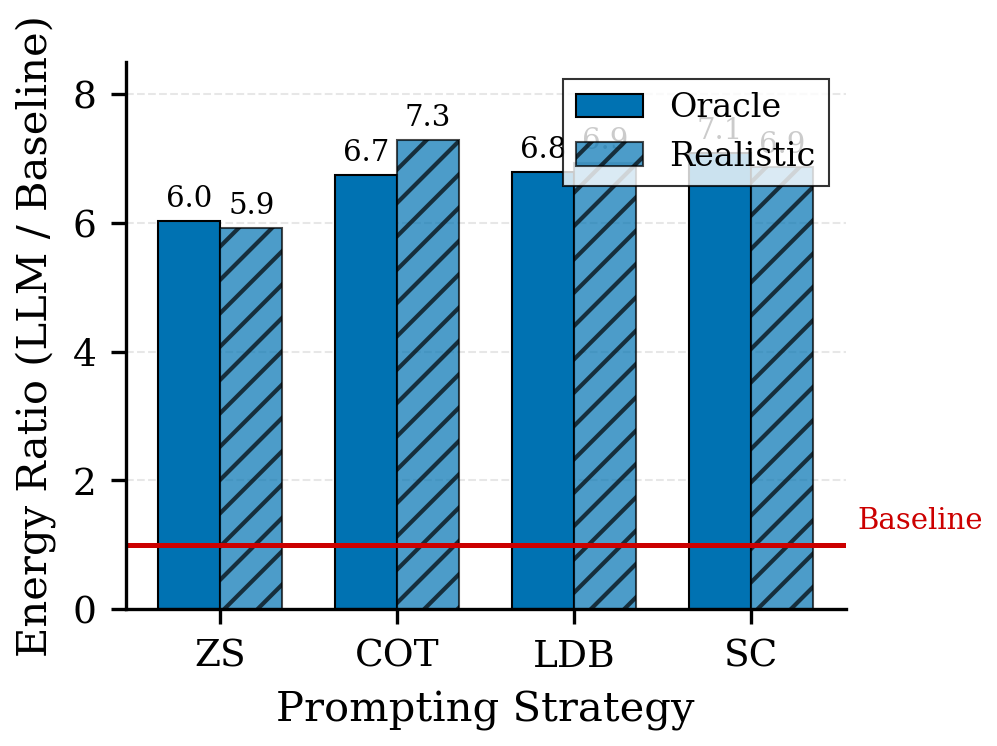

✅ Figure 1 saved


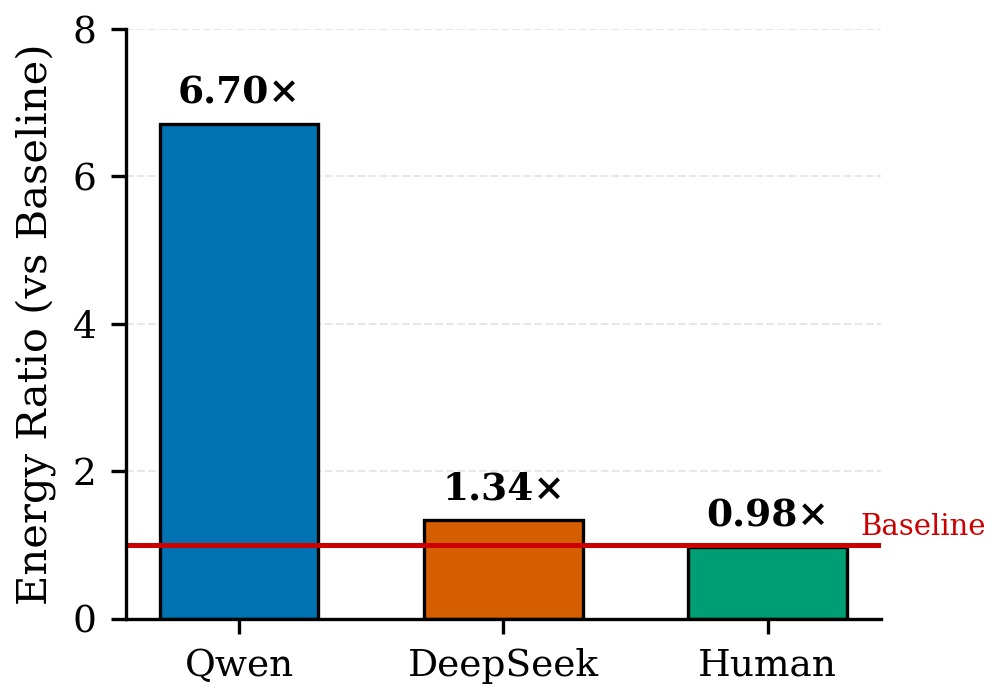

✅ Figure 2 saved


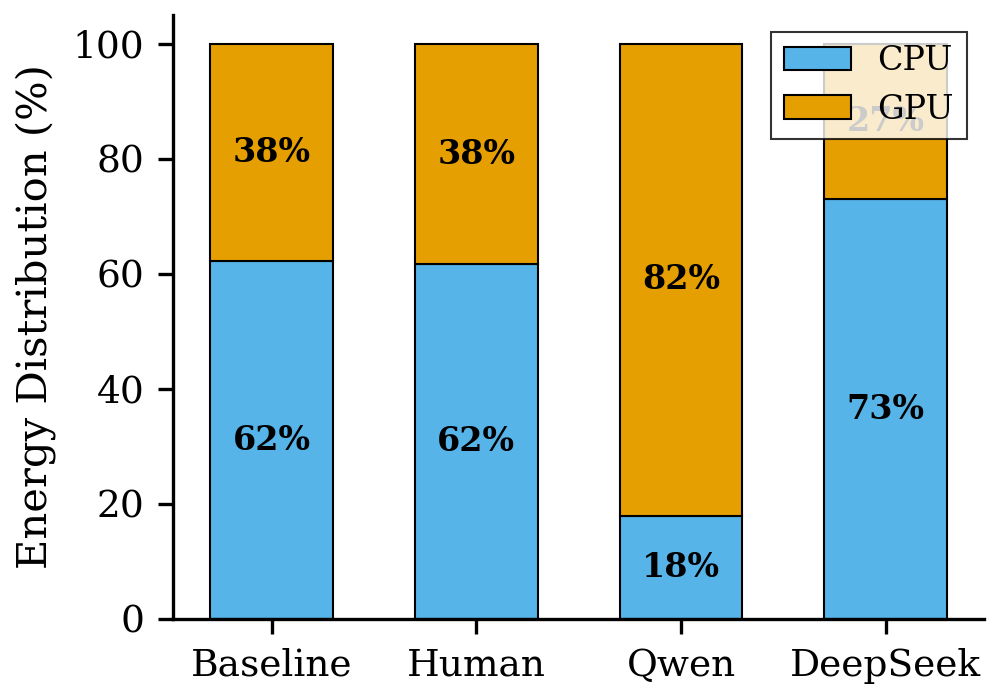

✅ Figure 3 saved


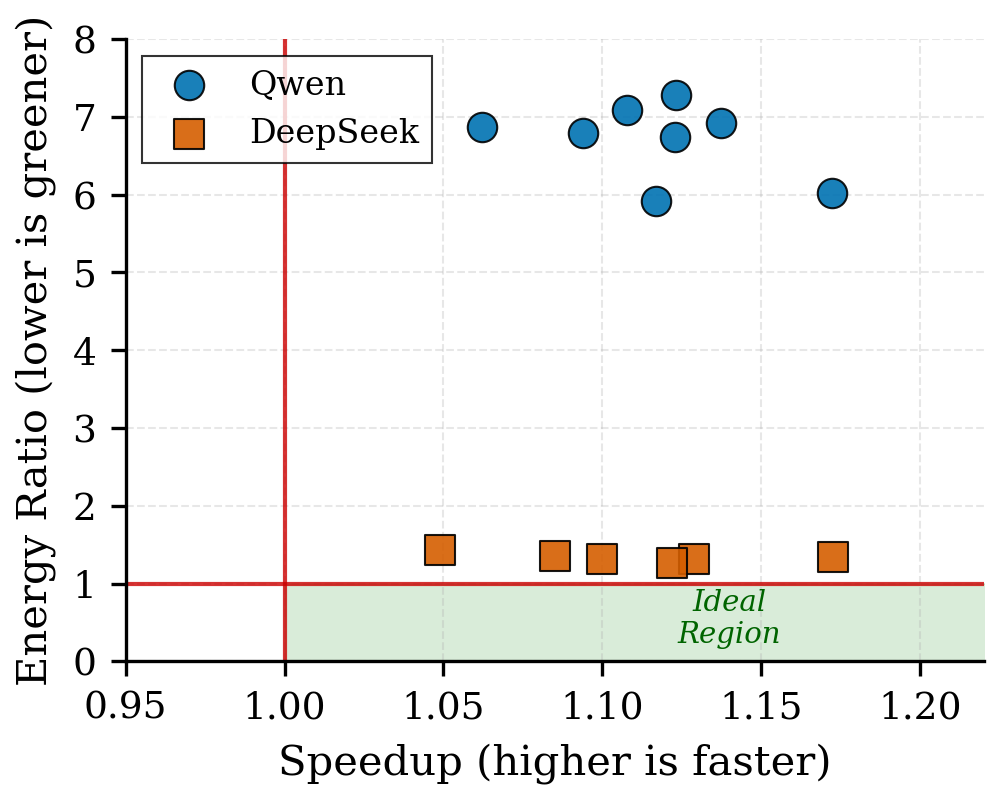

✅ Figure 4 saved

ALL FIGURES SAVED


In [12]:
# Cell 10: Publication-Quality Figures

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

# IEEE Conference Style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.5,
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.edgecolor': 'black',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Color palette (colorblind-friendly)
COLORS = {
    'qwen': '#0072B2',      # Blue
    'deepseek': '#D55E00',  # Orange/Red
    'human': '#009E73',     # Green
    'base': '#666666',      # Gray
    'cpu': '#56B4E9',       # Light blue
    'gpu': '#E69F00',       # Yellow/Orange
}

# ===========================================================================
# FIGURE 1: Main Results - Energy Ratio by Configuration (2-column width)
# ===========================================================================
fig1, ax1 = plt.subplots(figsize=(3.5, 2.5))  # Single column IEEE width

# Data preparation
strategies = ['ZS', 'COT', 'LDB', 'SC']
contexts = ['Oracle', 'Realistic']

# Get Qwen data (main focus due to more data)
qwen_oracle = []
qwen_realistic = []
for s in strategies:
    oracle_val = full_df[(full_df['Model'] == 'Qwen') & 
                          (full_df['Strategy'] == s) & 
                          (full_df['Context'] == 'Oracle')]['Energy Ratio'].values
    realistic_val = full_df[(full_df['Model'] == 'Qwen') & 
                             (full_df['Strategy'] == s) & 
                             (full_df['Context'] == 'Realistic')]['Energy Ratio'].values
    qwen_oracle.append(oracle_val[0] if len(oracle_val) > 0 else 0)
    qwen_realistic.append(realistic_val[0] if len(realistic_val) > 0 else 0)

x = np.arange(len(strategies))
width = 0.35

bars1 = ax1.bar(x - width/2, qwen_oracle, width, label='Oracle', 
                color=COLORS['qwen'], edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x + width/2, qwen_realistic, width, label='Realistic', 
                color=COLORS['qwen'], edgecolor='black', linewidth=0.5,
                hatch='///', alpha=0.7)

# Reference line
ax1.axhline(y=1, color='#CC0000', linestyle='-', linewidth=1.2, zorder=1)
ax1.text(3.6, 1.15, 'Baseline', fontsize=7, color='#CC0000', va='bottom')

# Labels
ax1.set_ylabel('Energy Ratio (LLM / Baseline)')
ax1.set_xlabel('Prompting Strategy')
ax1.set_xticks(x)
ax1.set_xticklabels(strategies)
ax1.set_ylim(0, 8.5)
ax1.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')

# Value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 2), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

# Add subtle grid
ax1.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig1_energy_ratio_qwen.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig1_energy_ratio_qwen.png', bbox_inches='tight', dpi=300)
plt.show()
print("✅ Figure 1 saved")

# ===========================================================================
# FIGURE 2: Model Comparison - Qwen vs DeepSeek
# ===========================================================================
fig2, ax2 = plt.subplots(figsize=(3.5, 2.5))

# Average across all configs for each model
models = ['Qwen', 'DeepSeek', 'Human']
energy_ratios = [
    full_df[full_df['Model'] == 'Qwen']['Energy Ratio'].mean(),
    full_df[full_df['Model'] == 'DeepSeek']['Energy Ratio'].mean(),
    1.0  # Human baseline (by definition, relative to itself adjusted to base)
]

# Actually compute human energy ratio vs base
human_energy_ratio = (df['human_head_total_energy_joules_mean'] / 
                      df['base_total_energy_joules_mean']).mean()
energy_ratios[2] = human_energy_ratio

colors = [COLORS['qwen'], COLORS['deepseek'], COLORS['human']]

bars = ax2.bar(models, energy_ratios, color=colors, edgecolor='black', linewidth=0.8, width=0.6)

# Reference line
ax2.axhline(y=1, color='#CC0000', linestyle='-', linewidth=1.2, zorder=1)
ax2.text(2.35, 1.05, 'Baseline', fontsize=7, color='#CC0000', va='bottom')

# Value labels
for bar, val in zip(bars, energy_ratios):
    ax2.annotate(f'{val:.2f}×',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_ylabel('Energy Ratio (vs Baseline)')
ax2.set_ylim(0, 8)
ax2.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax2.set_axisbelow(True)

# Remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_model_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig2_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print("✅ Figure 2 saved")

# ===========================================================================
# FIGURE 3: Energy Decomposition (CPU vs GPU) - Stacked Bar
# ===========================================================================
fig3, ax3 = plt.subplots(figsize=(3.5, 2.5))

categories = ['Baseline', 'Human', 'Qwen', 'DeepSeek']

# Calculate actual percentages
base_total = df['base_total_energy_joules_mean'].mean()
base_gpu_pct = df['base_gpu_energy_joules_mean'].mean() / base_total * 100
base_cpu_pct = df['base_cpu_energy_joules_mean'].mean() / base_total * 100

human_total = df['human_head_total_energy_joules_mean'].mean()
human_gpu_pct = df['human_head_gpu_energy_joules_mean'].mean() / human_total * 100
human_cpu_pct = df['human_head_cpu_energy_joules_mean'].mean() / human_total * 100

qwen_gpu_pct = full_df[full_df['Model'] == 'Qwen']['LLM GPU Share (%)'].mean()
qwen_cpu_pct = 100 - qwen_gpu_pct

deepseek_gpu_pct = full_df[full_df['Model'] == 'DeepSeek']['LLM GPU Share (%)'].mean()
deepseek_cpu_pct = 100 - deepseek_gpu_pct

cpu_vals = [base_cpu_pct, human_cpu_pct, qwen_cpu_pct, deepseek_cpu_pct]
gpu_vals = [base_gpu_pct, human_gpu_pct, qwen_gpu_pct, deepseek_gpu_pct]

x = np.arange(len(categories))
width = 0.6

bars_cpu = ax3.bar(x, cpu_vals, width, label='CPU', color=COLORS['cpu'], edgecolor='black', linewidth=0.5)
bars_gpu = ax3.bar(x, gpu_vals, width, bottom=cpu_vals, label='GPU', color=COLORS['gpu'], edgecolor='black', linewidth=0.5)

ax3.set_ylabel('Energy Distribution (%)')
ax3.set_xticks(x)
ax3.set_xticklabels(categories)
ax3.set_ylim(0, 105)
ax3.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')

# Add percentage labels inside bars
for i, (cpu, gpu) in enumerate(zip(cpu_vals, gpu_vals)):
    # CPU label
    if cpu > 15:
        ax3.text(i, cpu/2, f'{cpu:.0f}%', ha='center', va='center', 
                fontsize=8, fontweight='bold', color='black')
    # GPU label
    if gpu > 15:
        ax3.text(i, cpu + gpu/2, f'{gpu:.0f}%', ha='center', va='center', 
                fontsize=8, fontweight='bold', color='black')

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_energy_decomposition.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig3_energy_decomposition.png', bbox_inches='tight', dpi=300)
plt.show()
print("✅ Figure 3 saved")

# ===========================================================================
# FIGURE 4: Speed-Energy Trade-off Scatter Plot
# ===========================================================================
fig4, ax4 = plt.subplots(figsize=(3.5, 2.8))

# Plot each configuration
for model, color, marker in [('Qwen', COLORS['qwen'], 'o'), 
                              ('DeepSeek', COLORS['deepseek'], 's')]:
    model_data = full_df[full_df['Model'] == model]
    ax4.scatter(model_data['Speedup'], model_data['Energy Ratio'], 
               c=color, marker=marker, s=50, label=model, 
               edgecolors='black', linewidths=0.5, alpha=0.9, zorder=3)

# Reference lines
ax4.axhline(y=1, color='#CC0000', linestyle='-', linewidth=1, alpha=0.8, zorder=1)
ax4.axvline(x=1, color='#CC0000', linestyle='-', linewidth=1, alpha=0.8, zorder=1)

# Shade ideal region (faster AND less energy)
ax4.fill_between([1, 1.3], [0, 0], [1, 1], alpha=0.15, color='green', zorder=0)
ax4.text(1.14, 0.55, 'Ideal\nRegion', fontsize=7, ha='center', va='center', 
         color='darkgreen', style='italic')

# Labels and formatting
ax4.set_xlabel('Speedup (higher is faster)')
ax4.set_ylabel('Energy Ratio (lower is greener)')
ax4.set_xlim(0.95, 1.22)
ax4.set_ylim(0, 8)
ax4.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax4.xaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('fig4_speedup_energy_tradeoff.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig4_speedup_energy_tradeoff.png', bbox_inches='tight', dpi=300)
plt.show()
print("✅ Figure 4 saved")

print("\n" + "="*60)
print("ALL FIGURES SAVED")
print("="*60)

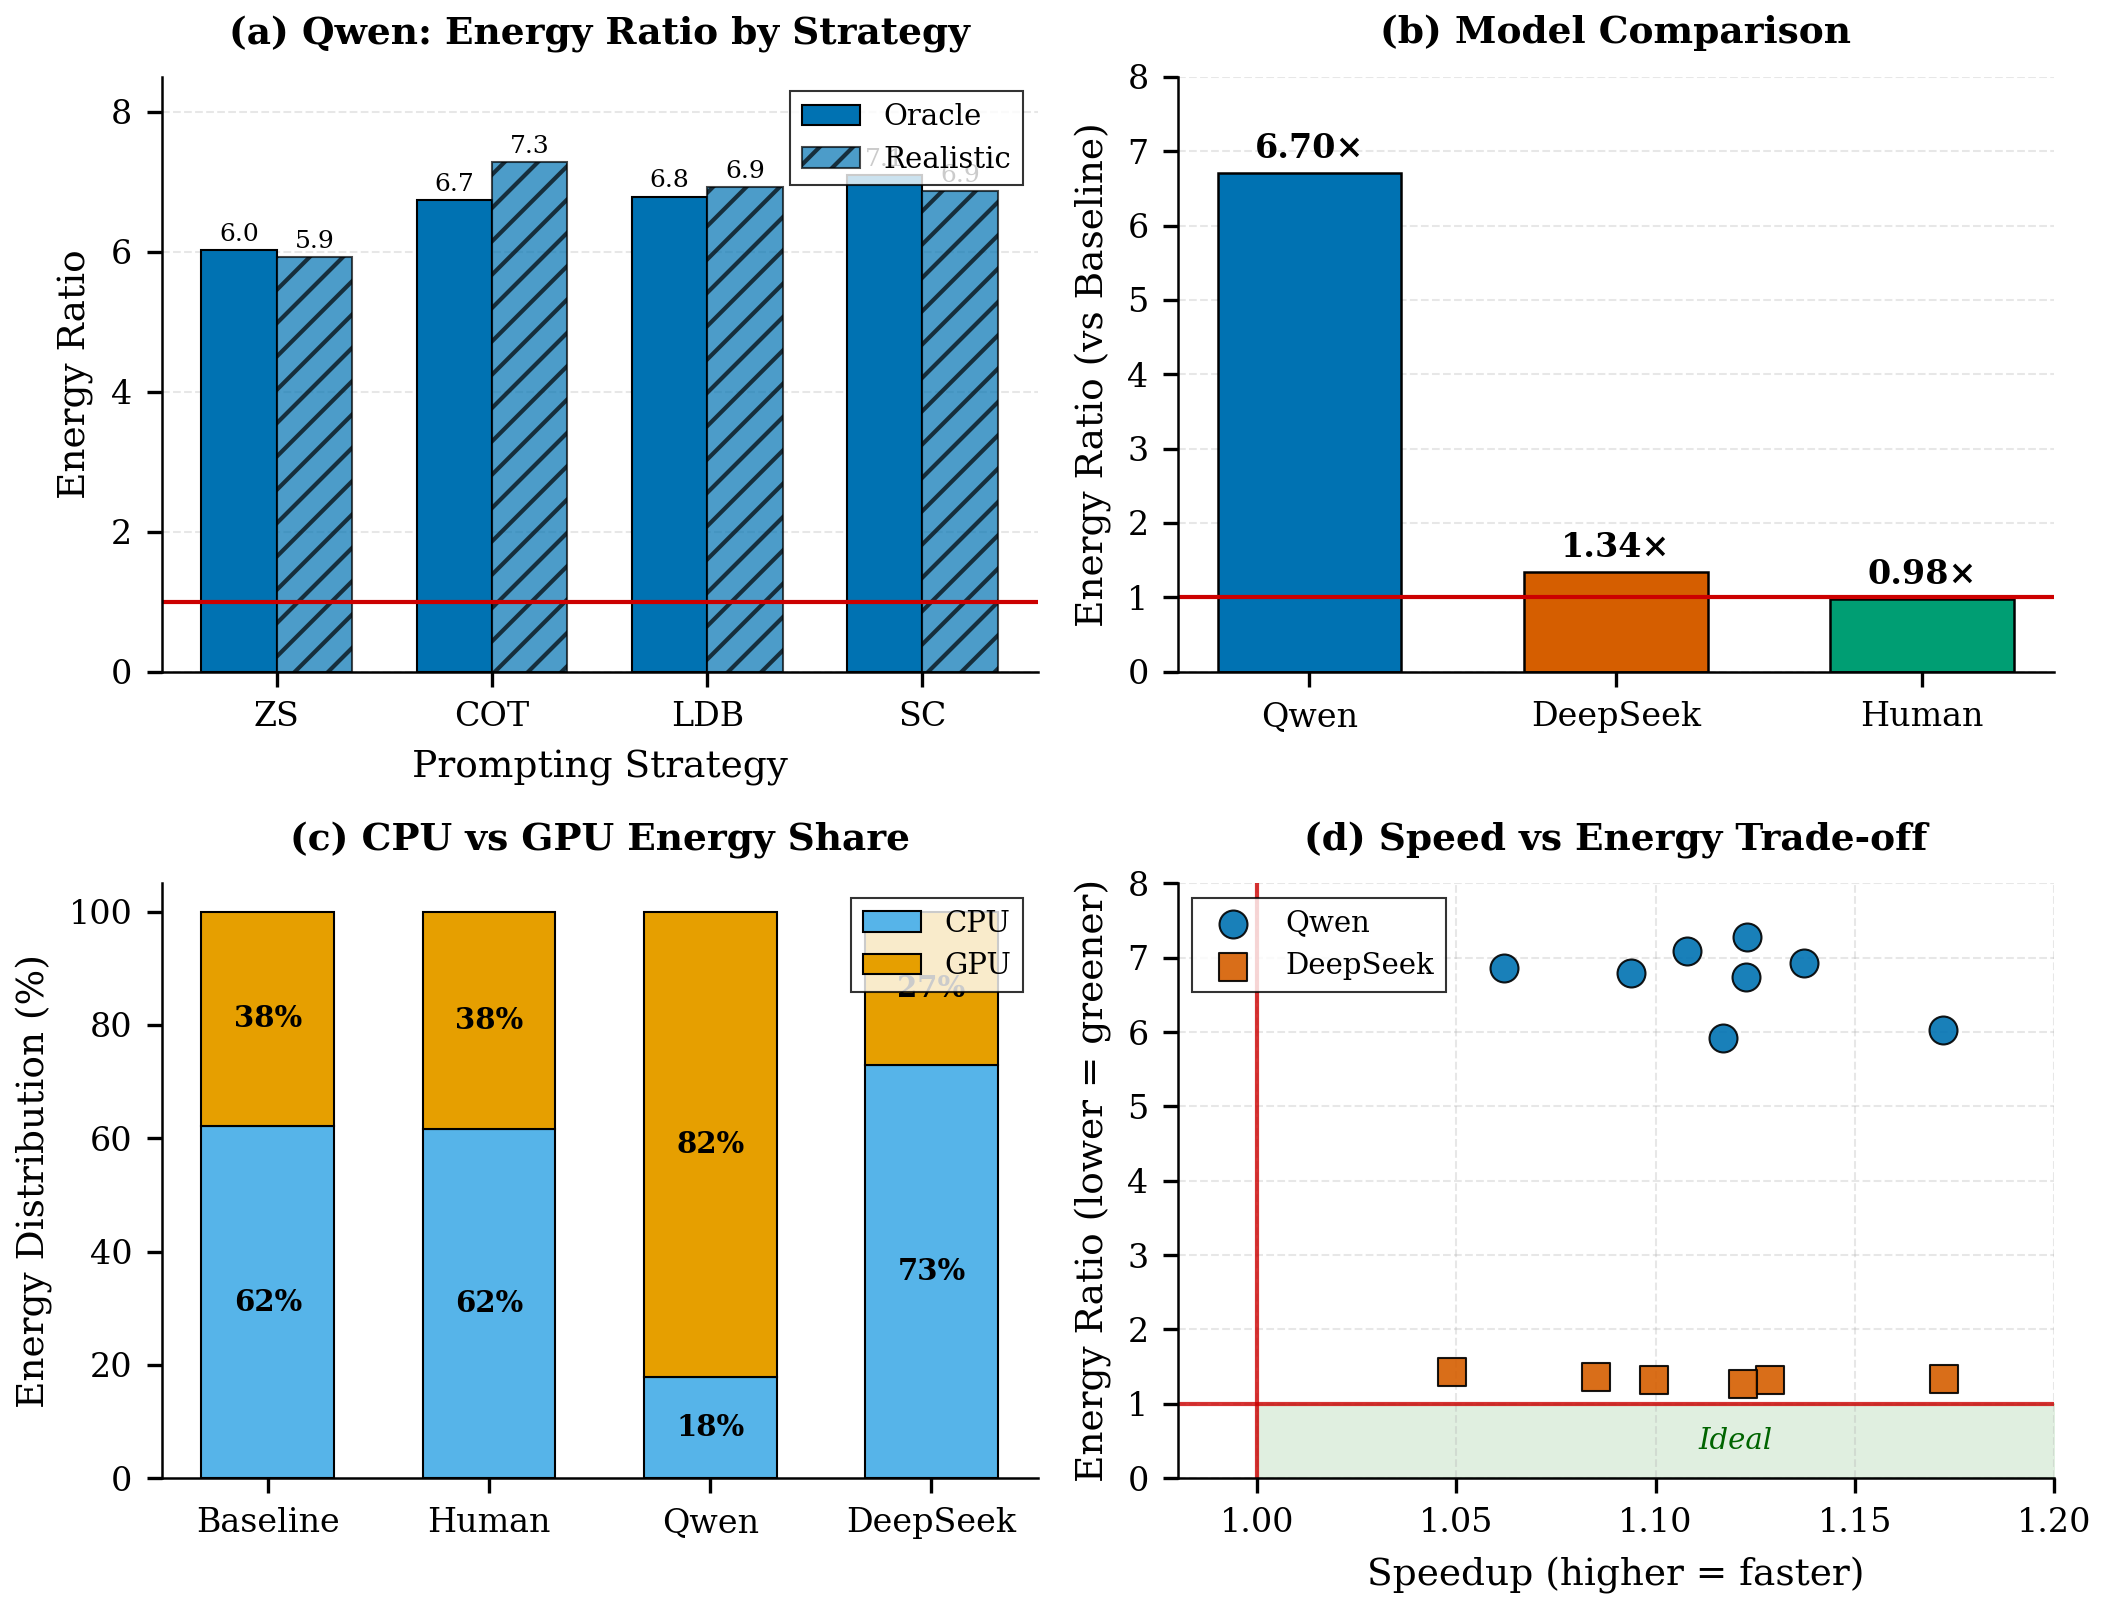

✅ Combined figure saved as 'fig_results_combined.pdf'

LATEX TABLE 1: Main Results (Pass Rate + Energy)

\begin{table}[t]
\centering
\caption{Energy Efficiency Results by Configuration}
\label{tab:main-results}
\small
\begin{tabular}{@{}llrrrrr@{}}
\toprule
\textbf{Model} & \textbf{Config} & \textbf{N} & \textbf{Pass\%} & \textbf{Speedup} & \textbf{Energy$\times$} & \textbf{GPU\%} \\
\midrule
Qwen & ZS-O & 74 & 59.2 & 1.17 & 6.02 & 80.2 \\
Qwen & ZS-R & 77 & 61.6 & 1.12 & 5.92 & 80.5 \\
Qwen & COT-O & 50 & 40.0 & 1.12 & 6.74 & 82.8 \\
Qwen & COT-R & 60 & 48.0 & 1.12 & 7.28 & 84.4 \\
Qwen & LDB-O & 82 & 65.6 & 1.09 & 6.79 & 81.3 \\
Qwen & LDB-R & 65 & 52.0 & 1.14 & 6.92 & 82.3 \\
Qwen & SC-O & 58 & 46.4 & 1.11 & 7.09 & 83.3 \\
Qwen & SC-R & 74 & 59.2 & 1.06 & 6.86 & 81.7 \\
DeepSeek & ZS-O & 19 & 15.2 & 1.09 & 1.36 & 26.5 \\
DeepSeek & ZS-R & 6 & 4.8 & 1.05 & 1.43 & 26.5 \\
DeepSeek & COT-O & 9 & 7.2 & 1.10 & 1.32 & 26.3 \\
DeepSeek & LDB-O & 28 & 22.4 & 1.13 & 1.32 & 27.4 \\
DeepSeek &

In [13]:
# Cell 11: Combined Figure (2x2) for Paper + LaTeX Tables

import matplotlib.pyplot as plt
import numpy as np

# IEEE Conference Style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'axes.linewidth': 0.6,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'qwen': '#0072B2',
    'deepseek': '#D55E00',
    'human': '#009E73',
    'base': '#666666',
    'cpu': '#56B4E9',
    'gpu': '#E69F00',
}

# ===========================================================================
# COMBINED FIGURE (2x2) - Full page width for IEEE
# ===========================================================================
fig, axes = plt.subplots(2, 2, figsize=(7.16, 5.5))  # IEEE double-column width

# ---------------------------------------------------------------------------
# (a) Energy Ratio by Strategy - Qwen
# ---------------------------------------------------------------------------
ax = axes[0, 0]

strategies = ['ZS', 'COT', 'LDB', 'SC']
qwen_oracle = []
qwen_realistic = []
for s in strategies:
    oracle_val = full_df[(full_df['Model'] == 'Qwen') & 
                          (full_df['Strategy'] == s) & 
                          (full_df['Context'] == 'Oracle')]['Energy Ratio'].values
    realistic_val = full_df[(full_df['Model'] == 'Qwen') & 
                             (full_df['Strategy'] == s) & 
                             (full_df['Context'] == 'Realistic')]['Energy Ratio'].values
    qwen_oracle.append(oracle_val[0] if len(oracle_val) > 0 else 0)
    qwen_realistic.append(realistic_val[0] if len(realistic_val) > 0 else 0)

x = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x - width/2, qwen_oracle, width, label='Oracle', 
               color=COLORS['qwen'], edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, qwen_realistic, width, label='Realistic', 
               color=COLORS['qwen'], edgecolor='black', linewidth=0.5,
               hatch='///', alpha=0.7)

ax.axhline(y=1, color='#CC0000', linestyle='-', linewidth=1)
ax.set_ylabel('Energy Ratio')
ax.set_xlabel('Prompting Strategy')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylim(0, 8.5)
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)
ax.set_title('(a) Qwen: Energy Ratio by Strategy', fontweight='bold', pad=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 1), textcoords="offset points", ha='center', va='bottom', fontsize=6)

# ---------------------------------------------------------------------------
# (b) Model Comparison
# ---------------------------------------------------------------------------
ax = axes[0, 1]

models = ['Qwen', 'DeepSeek', 'Human']
human_energy_ratio = (df['human_head_total_energy_joules_mean'] / 
                      df['base_total_energy_joules_mean']).mean()
energy_ratios = [
    full_df[full_df['Model'] == 'Qwen']['Energy Ratio'].mean(),
    full_df[full_df['Model'] == 'DeepSeek']['Energy Ratio'].mean(),
    human_energy_ratio
]
colors = [COLORS['qwen'], COLORS['deepseek'], COLORS['human']]

bars = ax.bar(models, energy_ratios, color=colors, edgecolor='black', linewidth=0.6, width=0.6)
ax.axhline(y=1, color='#CC0000', linestyle='-', linewidth=1)

for bar, val in zip(bars, energy_ratios):
    ax.annotate(f'{val:.2f}×', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
               xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', 
               fontsize=8, fontweight='bold')

ax.set_ylabel('Energy Ratio (vs Baseline)')
ax.set_ylim(0, 8)
ax.set_title('(b) Model Comparison', fontweight='bold', pad=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# ---------------------------------------------------------------------------
# (c) Energy Decomposition (CPU vs GPU)
# ---------------------------------------------------------------------------
ax = axes[1, 0]

categories = ['Baseline', 'Human', 'Qwen', 'DeepSeek']

base_total = df['base_total_energy_joules_mean'].mean()
base_gpu_pct = df['base_gpu_energy_joules_mean'].mean() / base_total * 100
base_cpu_pct = df['base_cpu_energy_joules_mean'].mean() / base_total * 100

human_total = df['human_head_total_energy_joules_mean'].mean()
human_gpu_pct = df['human_head_gpu_energy_joules_mean'].mean() / human_total * 100
human_cpu_pct = df['human_head_cpu_energy_joules_mean'].mean() / human_total * 100

qwen_gpu_pct = full_df[full_df['Model'] == 'Qwen']['LLM GPU Share (%)'].mean()
qwen_cpu_pct = 100 - qwen_gpu_pct

deepseek_gpu_pct = full_df[full_df['Model'] == 'DeepSeek']['LLM GPU Share (%)'].mean()
deepseek_cpu_pct = 100 - deepseek_gpu_pct

cpu_vals = [base_cpu_pct, human_cpu_pct, qwen_cpu_pct, deepseek_cpu_pct]
gpu_vals = [base_gpu_pct, human_gpu_pct, qwen_gpu_pct, deepseek_gpu_pct]

x = np.arange(len(categories))
width = 0.6

bars_cpu = ax.bar(x, cpu_vals, width, label='CPU', color=COLORS['cpu'], edgecolor='black', linewidth=0.5)
bars_gpu = ax.bar(x, gpu_vals, width, bottom=cpu_vals, label='GPU', color=COLORS['gpu'], edgecolor='black', linewidth=0.5)

ax.set_ylabel('Energy Distribution (%)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)
ax.set_title('(c) CPU vs GPU Energy Share', fontweight='bold', pad=8)

for i, (cpu, gpu) in enumerate(zip(cpu_vals, gpu_vals)):
    if cpu > 12:
        ax.text(i, cpu/2, f'{cpu:.0f}%', ha='center', va='center', fontsize=7, fontweight='bold')
    if gpu > 12:
        ax.text(i, cpu + gpu/2, f'{gpu:.0f}%', ha='center', va='center', fontsize=7, fontweight='bold')

# ---------------------------------------------------------------------------
# (d) Speed-Energy Trade-off
# ---------------------------------------------------------------------------
ax = axes[1, 1]

for model, color, marker in [('Qwen', COLORS['qwen'], 'o'), 
                              ('DeepSeek', COLORS['deepseek'], 's')]:
    model_data = full_df[full_df['Model'] == model]
    ax.scatter(model_data['Speedup'], model_data['Energy Ratio'], 
              c=color, marker=marker, s=45, label=model, 
              edgecolors='black', linewidths=0.5, alpha=0.9, zorder=3)

ax.axhline(y=1, color='#CC0000', linestyle='-', linewidth=1, alpha=0.8)
ax.axvline(x=1, color='#CC0000', linestyle='-', linewidth=1, alpha=0.8)

# Ideal region
ax.fill_between([1, 1.25], [0, 0], [1, 1], alpha=0.12, color='green', zorder=0)
ax.text(1.12, 0.5, 'Ideal', fontsize=7, ha='center', va='center', color='darkgreen', style='italic')

ax.set_xlabel('Speedup (higher = faster)')
ax.set_ylabel('Energy Ratio (lower = greener)')
ax.set_xlim(0.98, 1.20)
ax.set_ylim(0, 8)
ax.legend(loc='upper left', frameon=True, edgecolor='black', fancybox=False)
ax.set_title('(d) Speed vs Energy Trade-off', fontweight='bold', pad=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_results_combined.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_results_combined.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Combined figure saved as 'fig_results_combined.pdf'")

# ===========================================================================
# LATEX TABLES
# ===========================================================================
print("\n" + "="*70)
print("LATEX TABLE 1: Main Results (Pass Rate + Energy)")
print("="*70)

latex_table1 = r"""
\begin{table}[t]
\centering
\caption{Energy Efficiency Results by Configuration}
\label{tab:main-results}
\small
\begin{tabular}{@{}llrrrrr@{}}
\toprule
\textbf{Model} & \textbf{Config} & \textbf{N} & \textbf{Pass\%} & \textbf{Speedup} & \textbf{Energy$\times$} & \textbf{GPU\%} \\
\midrule
"""

for _, row in full_df.iterrows():
    config = f"{row['Strategy']}-{row['Context'][0]}"
    pass_rate = row['N'] / 125 * 100
    latex_table1 += f"{row['Model']} & {config} & {row['N']} & {pass_rate:.1f} & {row['Speedup']:.2f} & {row['Energy Ratio']:.2f} & {row['LLM GPU Share (%)']:.1f} \\\\\n"

latex_table1 += r"""
\midrule
\multicolumn{2}{l}{Human Baseline} & 125 & -- & 1.02 & 0.98 & 38.5 \\
\bottomrule
\end{tabular}
\end{table}
"""

print(latex_table1)

print("\n" + "="*70)
print("LATEX TABLE 2: Statistical Tests Summary")
print("="*70)

latex_table2 = r"""
\begin{table}[t]
\centering
\caption{Statistical Analysis Summary}
\label{tab:statistics}
\small
\begin{tabular}{@{}lllr@{}}
\toprule
\textbf{Comparison} & \textbf{Test} & \textbf{p-value} & \textbf{Effect} \\
\midrule
Qwen vs DeepSeek & Mann-Whitney U & $<$0.001 & Large ($\delta$=0.88) \\
Oracle vs Realistic & Mann-Whitney U & 0.659 & -- \\
Strategy (Qwen) & Kruskal-Wallis & 0.003 & Significant \\
LLM vs Human & Wilcoxon & $<$0.001 & -- \\
\bottomrule
\end{tabular}
\end{table}
"""

print(latex_table2)

print("\n" + "="*70)
print("LATEX TABLE 3: RQ Summary")  
print("="*70)

latex_table3 = r"""
\begin{table}[t]
\centering
\caption{Summary of Findings}
\label{tab:findings}
\small
\begin{tabular}{@{}lp{5.5cm}@{}}
\toprule
\textbf{RQ} & \textbf{Key Finding} \\
\midrule
RQ$_1$ & Context setting (Oracle vs Realistic) has \textbf{no significant impact} on energy efficiency (p=0.659). \\
\addlinespace
RQ$_2$ & Prompting strategy significantly affects energy (p=0.003). \textbf{Zero-Shot} achieves the best energy ratio (5.97$\times$), while \textbf{Self-Collaboration} performs worst (7.09$\times$). \\
\bottomrule
\end{tabular}
\end{table}
"""

print(latex_table3)

In [14]:
# Cell 13: Reconstruct Apply/Pass data for Preamble table

print("=" * 70)
print("PATCH SUCCESS PIPELINE DATA")
print("=" * 70)

# From our data, we know N = patches that passed tests AND have energy measurements
# We need: Generated → Applied → Passed

# Do you have apply rate data? Let's check what we can infer
print("\n📊 What we know (patches with energy measurements = passed tests):")
print("-" * 70)

total_instances = 125

summary_data = []
for model in ['qwen', 'deepseek']:
    model_name = 'Qwen2.5-Coder-7B' if model == 'qwen' else 'DeepSeek-R1-Distill-7B'
    
    for strategy in ['zs', 'cot', 'ldb', 'sc']:
        for context in ['oracle', 'realistic']:
            config = f"{model}_{strategy}_{context}"
            energy_col = f"{config}_total_energy_joules_mean"
            
            if energy_col not in df.columns:
                continue
            
            passed = df[energy_col].notna().sum()
            
            summary_data.append({
                'Model': model_name,
                'Strategy': strategy.upper(),
                'Context': context.capitalize(),
                'Config': f"{strategy.upper()}-{context[0].upper()}",
                'Generated': total_instances,  # All instances get a patch attempt
                'Passed': passed,
                'Pass Rate (%)': passed / total_instances * 100
            })

summary_df = pd.DataFrame(summary_data)

print("\nQwen Configurations:")
qwen_df = summary_df[summary_df['Model'] == 'Qwen2.5-Coder-7B']
print(qwen_df[['Config', 'Generated', 'Passed', 'Pass Rate (%)']].to_string(index=False))
print(f"\nQwen Total Passed: {qwen_df['Passed'].sum()} across {len(qwen_df)} configs")

print("\nDeepSeek Configurations:")
ds_df = summary_df[summary_df['Model'] == 'DeepSeek-R1-Distill-7B']
print(ds_df[['Config', 'Generated', 'Passed', 'Pass Rate (%)']].to_string(index=False))
print(f"\nDeepSeek Total Passed: {ds_df['Passed'].sum()} across {len(ds_df)} configs")

# For the paper, we need Apply Rate too
print("\n" + "=" * 70)
print("❓ QUESTION: Do you have Apply Rate data?")
print("=" * 70)
print("""
To complete the table, I need to know:
- How many patches were successfully APPLIED (before test execution)?
- This is different from PASSED (after test execution)

Options:
1. If you have this data in another file, share it
2. If not, we can estimate or just report Pass Rate
3. Or we can note that Apply Rate ≈ Pass Rate for most configs

What would you like to do?
""")

PATCH SUCCESS PIPELINE DATA

📊 What we know (patches with energy measurements = passed tests):
----------------------------------------------------------------------

Qwen Configurations:
Config  Generated  Passed  Pass Rate (%)
  ZS-O        125      74           59.2
  ZS-R        125      77           61.6
 COT-O        125      50           40.0
 COT-R        125      60           48.0
 LDB-O        125      82           65.6
 LDB-R        125      65           52.0
  SC-O        125      58           46.4
  SC-R        125      74           59.2

Qwen Total Passed: 540 across 8 configs

DeepSeek Configurations:
Config  Generated  Passed  Pass Rate (%)
  ZS-O        125      19           15.2
  ZS-R        125       6            4.8
 COT-O        125       9            7.2
 LDB-O        125      28           22.4
 LDB-R        125       8            6.4
  SC-O        125       8            6.4

DeepSeek Total Passed: 78 across 6 configs

❓ QUESTION: Do you have Apply Rate data?

To

In [15]:
# Cell 14: Count generated patches from results folder

import os
from pathlib import Path

print("=" * 70)
print("PATCH GENERATION PIPELINE: Generated → Applied → Passed")
print("=" * 70)

# Adjust this path to your results folder
results_path = Path("/home/giacomo/LLMs_For_Green_Code_Refactoring/results")  # <-- MODIFICA SE NECESSARIO (e.g., "/path/to/results")

# Check if path exists
if not results_path.exists():
    print(f"❌ Path '{results_path}' not found!")
    print("Please update the path to your results folder")
else:
    print(f"✅ Found results folder: {results_path}")
    
    # Structure: results/model_name/strategy_context/instance.json
    pipeline_data = []
    
    for model_dir in results_path.iterdir():
        if not model_dir.is_dir():
            continue
            
        model_name = model_dir.name
        print(f"\n📁 Model: {model_name}")
        
        for config_dir in model_dir.iterdir():
            if not config_dir.is_dir():
                continue
                
            config_name = config_dir.name
            
            # Count JSON files (generated patches)
            json_files = list(config_dir.glob("*.json"))
            generated = len(json_files)
            
            # Parse config name (e.g., "zs_oracle" or "cot_realistic")
            parts = config_name.split('_')
            if len(parts) >= 2:
                strategy = parts[0].upper()
                context = parts[1].capitalize()
            else:
                strategy = config_name.upper()
                context = "Unknown"
            
            print(f"   {config_name}: {generated} patches generated")
            
            pipeline_data.append({
                'Model': model_name,
                'Strategy': strategy,
                'Context': context,
                'Config': f"{strategy}-{context[0]}",
                'Generated': generated
            })
    
    # Create DataFrame
    pipeline_df = pd.DataFrame(pipeline_data)
    print("\n" + "=" * 70)
    print("Generated patches summary:")
    print(pipeline_df.to_string(index=False))

PATCH GENERATION PIPELINE: Generated → Applied → Passed
✅ Found results folder: /home/giacomo/LLMs_For_Green_Code_Refactoring/results

📁 Model: Qwen2.5-Coder-7B
   zs_realistic: 131 patches generated
   cot_realistic: 131 patches generated
   zs_oracle: 131 patches generated
   cot_oracle: 131 patches generated
   sc_oracle: 131 patches generated
   sc_realistic: 131 patches generated
   ldb_realistic: 131 patches generated
   ldb_oracle: 131 patches generated

📁 Model: DeepSeek-R1-Distill-7B
   zs_realistic: 131 patches generated
   cot_realistic: 131 patches generated
   zs_oracle: 131 patches generated
   cot_oracle: 131 patches generated
   sc_oracle: 131 patches generated
   sc_realistic: 131 patches generated
   ldb_realistic: 85 patches generated
   ldb_oracle: 131 patches generated

📁 Model: experiments

Generated patches summary:
                 Model Strategy   Context Config  Generated
      Qwen2.5-Coder-7B       ZS Realistic   ZS-R        131
      Qwen2.5-Coder-7B      C

In [16]:
# Cell 15: Complete Pipeline Analysis - Generated vs Passed

print("=" * 70)
print("COMPLETE PIPELINE: Generated → Passed (with Energy Measurement)")
print("=" * 70)

# Merge generated data with passed data
# Note: Our dataset has 125 instances, but 131 were generated (some filtered in curation)

total_benchmark_instances = 125  # After curation (CV < 0.3, etc.)

complete_pipeline = []

for model in ['Qwen2.5-Coder-7B', 'DeepSeek-R1-Distill-7B']:
    model_key = 'qwen' if 'Qwen' in model else 'deepseek'
    
    for strategy in ['ZS', 'COT', 'LDB', 'SC']:
        for context in ['Oracle', 'Realistic']:
            config = f"{model_key}_{strategy.lower()}_{context.lower()}"
            energy_col = f"{config}_total_energy_joules_mean"
            
            # Get generated count
            gen_row = pipeline_df[(pipeline_df['Model'] == model) & 
                                   (pipeline_df['Strategy'] == strategy) & 
                                   (pipeline_df['Context'] == context)]
            generated = gen_row['Generated'].values[0] if len(gen_row) > 0 else 0
            
            # Get passed count (from energy measurements)
            if energy_col in df.columns:
                passed = df[energy_col].notna().sum()
            else:
                passed = 0
            
            # Calculate rates
            # Note: Generated is out of 131 (all instances), Passed is out of 125 (curated)
            pass_rate = (passed / total_benchmark_instances * 100) if total_benchmark_instances > 0 else 0
            
            complete_pipeline.append({
                'Model': 'Qwen' if 'Qwen' in model else 'DeepSeek',
                'Strategy': strategy,
                'Context': context,
                'Config': f"{strategy}-{context[0]}",
                'Generated': generated,
                'Passed': passed,
                'Pass Rate (%)': pass_rate
            })

complete_df = pd.DataFrame(complete_pipeline)

# Display results
print("\n📊 QWEN Pipeline:")
print("-" * 70)
qwen_pipe = complete_df[complete_df['Model'] == 'Qwen']
print(qwen_pipe[['Config', 'Generated', 'Passed', 'Pass Rate (%)']].to_string(index=False))
print(f"\nQwen Totals: Generated={qwen_pipe['Generated'].sum()}, Passed={qwen_pipe['Passed'].sum()}")

print("\n📊 DEEPSEEK Pipeline:")
print("-" * 70)
ds_pipe = complete_df[complete_df['Model'] == 'DeepSeek']
print(ds_pipe[['Config', 'Generated', 'Passed', 'Pass Rate (%)']].to_string(index=False))
print(f"\nDeepSeek Totals: Generated={ds_pipe['Generated'].sum()}, Passed={ds_pipe['Passed'].sum()}")

# Summary table for paper
print("\n" + "=" * 70)
print("LATEX TABLE: Patch Success Pipeline")
print("=" * 70)

# Aggregate by model
model_summary = complete_df.groupby('Model').agg({
    'Generated': 'sum',
    'Passed': 'sum'
}).reset_index()
model_summary['Pass Rate (%)'] = (model_summary['Passed'] / (model_summary['Generated'] / 131 * 125) * 100).round(1)

print(model_summary)

# Grand totals
total_generated = complete_df['Generated'].sum()
total_passed = complete_df['Passed'].sum()
print(f"\n📊 GRAND TOTALS:")
print(f"   Total Configurations: {len(complete_df)}")
print(f"   Total Generated: {total_generated}")
print(f"   Total Passed (with energy): {total_passed}")
print(f"   Overall Success Rate: {total_passed / (len(complete_df) * 125) * 100:.1f}%")

# Save for later
complete_df.to_csv('pipeline_complete.csv', index=False)
print("\n✅ Pipeline data saved to 'pipeline_complete.csv'")

COMPLETE PIPELINE: Generated → Passed (with Energy Measurement)

📊 QWEN Pipeline:
----------------------------------------------------------------------
Config  Generated  Passed  Pass Rate (%)
  ZS-O        131      74           59.2
  ZS-R        131      77           61.6
 COT-O        131      50           40.0
 COT-R        131      60           48.0
 LDB-O        131      82           65.6
 LDB-R        131      65           52.0
  SC-O        131      58           46.4
  SC-R        131      74           59.2

Qwen Totals: Generated=1048, Passed=540

📊 DEEPSEEK Pipeline:
----------------------------------------------------------------------
Config  Generated  Passed  Pass Rate (%)
  ZS-O        131      19           15.2
  ZS-R        131       6            4.8
 COT-O        131       9            7.2
 COT-R        131       0            0.0
 LDB-O        131      28           22.4
 LDB-R         85       8            6.4
  SC-O        131       8            6.4
  SC-R        13

In [17]:
# Cell 16: RQ1 Analysis - Oracle vs Realistic for BOTH models

from scipy import stats

print("=" * 70)
print("RQ1: CONTEXT SETTING IMPACT (Oracle vs Realistic)")
print("=" * 70)

# ===== QWEN ANALYSIS =====
print("\n" + "="*70)
print("QWEN: Oracle vs Realistic")
print("="*70)

qwen_oracle_data = full_df[(full_df['Model'] == 'Qwen') & (full_df['Context'] == 'Oracle')]
qwen_realistic_data = full_df[(full_df['Model'] == 'Qwen') & (full_df['Context'] == 'Realistic')]

print("\n📊 Pass Rate:")
print(f"   Oracle:    {qwen_oracle_data['N'].sum()} passed, avg {qwen_oracle_data['N'].mean():.1f} per strategy")
print(f"   Realistic: {qwen_realistic_data['N'].sum()} passed, avg {qwen_realistic_data['N'].mean():.1f} per strategy")

print("\n📊 Energy Ratio:")
print(f"   Oracle:    {qwen_oracle_data['Energy Ratio'].mean():.2f}× (std: {qwen_oracle_data['Energy Ratio'].std():.2f})")
print(f"   Realistic: {qwen_realistic_data['Energy Ratio'].mean():.2f}× (std: {qwen_realistic_data['Energy Ratio'].std():.2f})")

print("\n📊 Speedup:")
print(f"   Oracle:    {qwen_oracle_data['Speedup'].mean():.2f}×")
print(f"   Realistic: {qwen_realistic_data['Speedup'].mean():.2f}×")

# Statistical test - get per-instance data
def get_energy_ratios_by_context(model, context):
    """Get per-instance energy ratios for all strategies in a context"""
    model_key = 'qwen' if model == 'Qwen' else 'deepseek'
    all_ratios = []
    
    for strategy in ['zs', 'cot', 'ldb', 'sc']:
        config = f"{model_key}_{strategy}_{context.lower()}"
        energy_col = f"{config}_total_energy_joules_mean"
        
        if energy_col not in df.columns:
            continue
            
        mask = df[energy_col].notna()
        if mask.sum() == 0:
            continue
            
        llm_energy = df.loc[mask, energy_col]
        base_energy = df.loc[mask, 'base_total_energy_joules_mean']
        ratios = (llm_energy / base_energy).values
        all_ratios.extend(ratios)
    
    return np.array(all_ratios)

qwen_oracle_ratios = get_energy_ratios_by_context('Qwen', 'Oracle')
qwen_realistic_ratios = get_energy_ratios_by_context('Qwen', 'Realistic')

stat, p_value = stats.mannwhitneyu(qwen_oracle_ratios, qwen_realistic_ratios, alternative='two-sided')
print(f"\n📊 Statistical Test (Mann-Whitney U):")
print(f"   Oracle n={len(qwen_oracle_ratios)}, Realistic n={len(qwen_realistic_ratios)}")
print(f"   U={stat:.1f}, p={p_value:.4f}")
print(f"   Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# ===== DEEPSEEK ANALYSIS =====
print("\n" + "="*70)
print("DEEPSEEK: Oracle vs Realistic")
print("="*70)

deepseek_oracle_data = full_df[(full_df['Model'] == 'DeepSeek') & (full_df['Context'] == 'Oracle')]
deepseek_realistic_data = full_df[(full_df['Model'] == 'DeepSeek') & (full_df['Context'] == 'Realistic')]

print("\n📊 Configurations available:")
print(f"   Oracle:    {len(deepseek_oracle_data)} configs")
print(f"   Realistic: {len(deepseek_realistic_data)} configs")

if len(deepseek_oracle_data) > 0:
    print("\n📊 Pass Rate:")
    print(f"   Oracle:    {deepseek_oracle_data['N'].sum()} passed")
    print(f"   Realistic: {deepseek_realistic_data['N'].sum()} passed")
    
    print("\n📊 Energy Ratio:")
    print(f"   Oracle:    {deepseek_oracle_data['Energy Ratio'].mean():.2f}× (std: {deepseek_oracle_data['Energy Ratio'].std():.2f})")
    if len(deepseek_realistic_data) > 0:
        print(f"   Realistic: {deepseek_realistic_data['Energy Ratio'].mean():.2f}× (std: {deepseek_realistic_data['Energy Ratio'].std():.2f})")
    else:
        print(f"   Realistic: No data (0 configs with passing patches)")

# Statistical test for DeepSeek
deepseek_oracle_ratios = get_energy_ratios_by_context('DeepSeek', 'Oracle')
deepseek_realistic_ratios = get_energy_ratios_by_context('DeepSeek', 'Realistic')

print(f"\n📊 Statistical Test (Mann-Whitney U):")
print(f"   Oracle n={len(deepseek_oracle_ratios)}, Realistic n={len(deepseek_realistic_ratios)}")

if len(deepseek_realistic_ratios) >= 5:  # Need enough samples
    stat_ds, p_value_ds = stats.mannwhitneyu(deepseek_oracle_ratios, deepseek_realistic_ratios, alternative='two-sided')
    print(f"   U={stat_ds:.1f}, p={p_value_ds:.4f}")
    print(f"   Significant at α=0.05: {'Yes' if p_value_ds < 0.05 else 'No'}")
else:
    print(f"   ⚠️ Insufficient Realistic samples for statistical test")

# ===== COMBINED SUMMARY TABLE =====
print("\n" + "="*70)
print("SUMMARY TABLE FOR PAPER: RQ1 Results")
print("="*70)

rq1_summary = []
for model in ['Qwen', 'DeepSeek']:
    for context in ['Oracle', 'Realistic']:
        data = full_df[(full_df['Model'] == model) & (full_df['Context'] == context)]
        if len(data) > 0:
            rq1_summary.append({
                'Model': model,
                'Context': context,
                'Configs': len(data),
                'N (passed)': data['N'].sum(),
                'Avg Pass Rate (%)': (data['N'].sum() / (len(data) * 125) * 100),
                'Energy Ratio': data['Energy Ratio'].mean(),
                'Speedup': data['Speedup'].mean()
            })

rq1_df = pd.DataFrame(rq1_summary)
print(rq1_df.round(2).to_string(index=False))

# ===== BREAKDOWN BY STRATEGY =====
print("\n" + "="*70)
print("BREAKDOWN BY STRATEGY")
print("="*70)

print("\nQWEN:")
for strategy in ['ZS', 'COT', 'LDB', 'SC']:
    oracle = full_df[(full_df['Model'] == 'Qwen') & (full_df['Strategy'] == strategy) & (full_df['Context'] == 'Oracle')]
    realistic = full_df[(full_df['Model'] == 'Qwen') & (full_df['Strategy'] == strategy) & (full_df['Context'] == 'Realistic')]
    if len(oracle) > 0 and len(realistic) > 0:
        print(f"   {strategy}: Oracle={oracle['Energy Ratio'].values[0]:.2f}×, Realistic={realistic['Energy Ratio'].values[0]:.2f}×, Δ={oracle['Energy Ratio'].values[0] - realistic['Energy Ratio'].values[0]:.2f}")

print("\nDEEPSEEK:")
for strategy in ['ZS', 'COT', 'LDB', 'SC']:
    oracle = full_df[(full_df['Model'] == 'DeepSeek') & (full_df['Strategy'] == strategy) & (full_df['Context'] == 'Oracle')]
    realistic = full_df[(full_df['Model'] == 'DeepSeek') & (full_df['Strategy'] == strategy) & (full_df['Context'] == 'Realistic')]
    if len(oracle) > 0:
        oracle_val = oracle['Energy Ratio'].values[0]
        if len(realistic) > 0:
            realistic_val = realistic['Energy Ratio'].values[0]
            print(f"   {strategy}: Oracle={oracle_val:.2f}×, Realistic={realistic_val:.2f}×, Δ={oracle_val - realistic_val:.2f}")
        else:
            print(f"   {strategy}: Oracle={oracle_val:.2f}×, Realistic=N/A")

RQ1: CONTEXT SETTING IMPACT (Oracle vs Realistic)

QWEN: Oracle vs Realistic

📊 Pass Rate:
   Oracle:    264 passed, avg 66.0 per strategy
   Realistic: 276 passed, avg 69.0 per strategy

📊 Energy Ratio:
   Oracle:    6.66× (std: 0.45)
   Realistic: 6.75× (std: 0.58)

📊 Speedup:
   Oracle:    1.12×
   Realistic: 1.11×

📊 Statistical Test (Mann-Whitney U):
   Oracle n=264, Realistic n=276
   U=35594.0, p=0.6440
   Significant at α=0.05: No

DEEPSEEK: Oracle vs Realistic

📊 Configurations available:
   Oracle:    4 configs
   Realistic: 2 configs

📊 Pass Rate:
   Oracle:    64 passed
   Realistic: 14 passed

📊 Energy Ratio:
   Oracle:    1.33× (std: 0.02)
   Realistic: 1.35× (std: 0.12)

📊 Statistical Test (Mann-Whitney U):
   Oracle n=64, Realistic n=14
   U=441.0, p=0.9326
   Significant at α=0.05: No

SUMMARY TABLE FOR PAPER: RQ1 Results
   Model   Context  Configs  N (passed)  Avg Pass Rate (%)  Energy Ratio  Speedup
    Qwen    Oracle        4         264               52.8         

In [18]:
# Cell 17: RQ2 Analysis - Prompting Strategy Impact for BOTH models

from scipy import stats

print("=" * 70)
print("RQ2: PROMPTING STRATEGY IMPACT")
print("=" * 70)

# ===== QWEN ANALYSIS =====
print("\n" + "="*70)
print("QWEN: Strategy Comparison")
print("="*70)

# Get per-instance energy ratios for each strategy
def get_strategy_ratios(model, strategy):
    """Get per-instance energy ratios for a strategy (both contexts combined)"""
    model_key = 'qwen' if model == 'Qwen' else 'deepseek'
    all_ratios = []
    
    for context in ['oracle', 'realistic']:
        config = f"{model_key}_{strategy.lower()}_{context}"
        energy_col = f"{config}_total_energy_joules_mean"
        
        if energy_col not in df.columns:
            continue
            
        mask = df[energy_col].notna()
        if mask.sum() == 0:
            continue
            
        llm_energy = df.loc[mask, energy_col]
        base_energy = df.loc[mask, 'base_total_energy_joules_mean']
        ratios = (llm_energy / base_energy).values
        all_ratios.extend(ratios)
    
    return np.array(all_ratios)

# Qwen strategies
qwen_strategies = {}
for strategy in ['ZS', 'COT', 'LDB', 'SC']:
    qwen_strategies[strategy] = get_strategy_ratios('Qwen', strategy)

print("\n📊 Energy Ratio by Strategy (mean ± std):")
for strategy, ratios in qwen_strategies.items():
    print(f"   {strategy}: {np.mean(ratios):.2f}× ± {np.std(ratios):.2f} (n={len(ratios)})")

# Kruskal-Wallis test
kw_stat, kw_p = stats.kruskal(*qwen_strategies.values())
print(f"\n📊 Kruskal-Wallis Test:")
print(f"   H={kw_stat:.2f}, p={kw_p:.4f}")
print(f"   Significant at α=0.05: {'Yes' if kw_p < 0.05 else 'No'}")

# Pairwise comparisons (ZS vs others)
print("\n📊 Pairwise Comparisons (ZS vs others):")
for strategy in ['COT', 'LDB', 'SC']:
    stat, p = stats.mannwhitneyu(qwen_strategies['ZS'], qwen_strategies[strategy], alternative='less')
    print(f"   ZS vs {strategy}: U={stat:.0f}, p={p:.4f} {'*' if p < 0.05 else ''}")

# GPU Share by strategy
print("\n📊 GPU Share by Strategy:")
qwen_gpu = full_df[full_df['Model'] == 'Qwen'].groupby('Strategy')['LLM GPU Share (%)'].mean()
for strategy in ['ZS', 'COT', 'LDB', 'SC']:
    print(f"   {strategy}: {qwen_gpu[strategy]:.1f}%")

# Speedup by strategy
print("\n📊 Speedup by Strategy:")
qwen_speedup = full_df[full_df['Model'] == 'Qwen'].groupby('Strategy')['Speedup'].mean()
for strategy in ['ZS', 'COT', 'LDB', 'SC']:
    print(f"   {strategy}: {qwen_speedup[strategy]:.2f}×")

# ===== DEEPSEEK ANALYSIS =====
print("\n" + "="*70)
print("DEEPSEEK: Strategy Comparison")
print("="*70)

# DeepSeek strategies
deepseek_strategies = {}
for strategy in ['ZS', 'COT', 'LDB', 'SC']:
    ratios = get_strategy_ratios('DeepSeek', strategy)
    if len(ratios) > 0:
        deepseek_strategies[strategy] = ratios

print("\n📊 Energy Ratio by Strategy (mean ± std):")
for strategy, ratios in deepseek_strategies.items():
    print(f"   {strategy}: {np.mean(ratios):.2f}× ± {np.std(ratios):.2f} (n={len(ratios)})")

# Kruskal-Wallis test for DeepSeek (if enough data)
if len(deepseek_strategies) >= 3:
    ds_kw_stat, ds_kw_p = stats.kruskal(*deepseek_strategies.values())
    print(f"\n📊 Kruskal-Wallis Test:")
    print(f"   H={ds_kw_stat:.2f}, p={ds_kw_p:.4f}")
    print(f"   Significant at α=0.05: {'Yes' if ds_kw_p < 0.05 else 'No'}")

# GPU Share by strategy (DeepSeek)
print("\n📊 GPU Share by Strategy:")
ds_gpu = full_df[full_df['Model'] == 'DeepSeek'].groupby('Strategy')['LLM GPU Share (%)'].mean()
for strategy in ds_gpu.index:
    print(f"   {strategy}: {ds_gpu[strategy]:.1f}%")

# ===== MODEL COMPARISON =====
print("\n" + "="*70)
print("MODEL COMPARISON: Qwen vs DeepSeek")
print("="*70)

# Overall stats
qwen_all = np.concatenate(list(qwen_strategies.values()))
deepseek_all = np.concatenate(list(deepseek_strategies.values()))

print(f"\n📊 Overall Energy Ratio:")
print(f"   Qwen:     {np.mean(qwen_all):.2f}× ± {np.std(qwen_all):.2f} (n={len(qwen_all)})")
print(f"   DeepSeek: {np.mean(deepseek_all):.2f}× ± {np.std(deepseek_all):.2f} (n={len(deepseek_all)})")

# Mann-Whitney U test
stat, p = stats.mannwhitneyu(qwen_all, deepseek_all, alternative='greater')
print(f"\n📊 Mann-Whitney U Test (Qwen > DeepSeek):")
print(f"   U={stat:.0f}, p={p:.2e}")
print(f"   Significant: {'Yes' if p < 0.05 else 'No'}")

# Cliff's delta
def cliffs_delta(x, y):
    n1, n2 = len(x), len(y)
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (greater - less) / (n1 * n2)

delta = cliffs_delta(qwen_all, deepseek_all)
effect_size = 'large' if abs(delta) > 0.474 else 'medium' if abs(delta) > 0.33 else 'small'
print(f"   Cliff's delta: {delta:.3f} ({effect_size})")

# ===== COMPARISON WITH HUMAN =====
print("\n" + "="*70)
print("COMPARISON WITH HUMAN BASELINE")
print("="*70)

# Human energy ratio
human_ratio = (df['human_head_total_energy_joules_mean'] / df['base_total_energy_joules_mean'])
print(f"\n📊 Human Energy Ratio: {human_ratio.mean():.2f}× ± {human_ratio.std():.2f}")

# LLM vs Human (Wilcoxon for paired data where both exist)
# Use Qwen ZS Oracle as representative
config = 'qwen_zs_oracle'
mask = df[f'{config}_total_energy_joules_mean'].notna()
llm_energy = df.loc[mask, f'{config}_total_energy_joules_mean']
human_energy = df.loc[mask, 'human_head_total_energy_joules_mean']

stat, p = stats.wilcoxon(llm_energy, human_energy, alternative='greater')
print(f"\n📊 Wilcoxon Test (Qwen ZS-Oracle > Human):")
print(f"   W={stat:.0f}, p={p:.2e}")
print(f"   LLM significantly worse than Human: {'Yes' if p < 0.05 else 'No'}")

# ===== SUMMARY TABLE =====
print("\n" + "="*70)
print("SUMMARY TABLE FOR PAPER: RQ2 Results")
print("="*70)

rq2_data = []
for model in ['Qwen', 'DeepSeek']:
    model_data = full_df[full_df['Model'] == model]
    for strategy in ['ZS', 'COT', 'LDB', 'SC']:
        strat_data = model_data[model_data['Strategy'] == strategy]
        if len(strat_data) > 0:
            rq2_data.append({
                'Model': model,
                'Strategy': strategy,
                'N': strat_data['N'].sum(),
                'Energy Ratio': strat_data['Energy Ratio'].mean(),
                'Speedup': strat_data['Speedup'].mean(),
                'GPU Share (%)': strat_data['LLM GPU Share (%)'].mean()
            })

# Add human baseline
rq2_data.append({
    'Model': 'Human',
    'Strategy': '--',
    'N': 125,
    'Energy Ratio': human_ratio.mean(),
    'Speedup': (df['base_duration_seconds_mean'] / df['human_head_duration_seconds_mean']).mean(),
    'GPU Share (%)': df['human_head_gpu_energy_joules_mean'].mean() / df['human_head_total_energy_joules_mean'].mean() * 100
})

rq2_df = pd.DataFrame(rq2_data)
print(rq2_df.round(2).to_string(index=False))

RQ2: PROMPTING STRATEGY IMPACT

QWEN: Strategy Comparison

📊 Energy Ratio by Strategy (mean ± std):
   ZS: 5.97× ± 1.96 (n=151)
   COT: 7.04× ± 1.33 (n=110)
   LDB: 6.85× ± 1.58 (n=147)
   SC: 6.96× ± 1.43 (n=132)

📊 Kruskal-Wallis Test:
   H=33.58, p=0.0000
   Significant at α=0.05: Yes

📊 Pairwise Comparisons (ZS vs others):
   ZS vs COT: U=5411, p=0.0000 *
   ZS vs LDB: U=7961, p=0.0000 *
   ZS vs SC: U=6666, p=0.0000 *

📊 GPU Share by Strategy:
   ZS: 80.4%
   COT: 83.6%
   LDB: 81.8%
   SC: 82.5%

📊 Speedup by Strategy:
   ZS: 1.14×
   COT: 1.12×
   LDB: 1.12×
   SC: 1.08×

DEEPSEEK: Strategy Comparison

📊 Energy Ratio by Strategy (mean ± std):
   ZS: 1.38× ± 0.15 (n=25)
   COT: 1.32× ± 0.25 (n=9)
   LDB: 1.31× ± 0.19 (n=36)
   SC: 1.34× ± 0.11 (n=8)

📊 Kruskal-Wallis Test:
   H=2.00, p=0.5727
   Significant at α=0.05: No

📊 GPU Share by Strategy:
   COT: 26.3%
   LDB: 27.7%
   SC: 27.7%
   ZS: 26.5%

MODEL COMPARISON: Qwen vs DeepSeek

📊 Overall Energy Ratio:
   Qwen:     6.67× ±

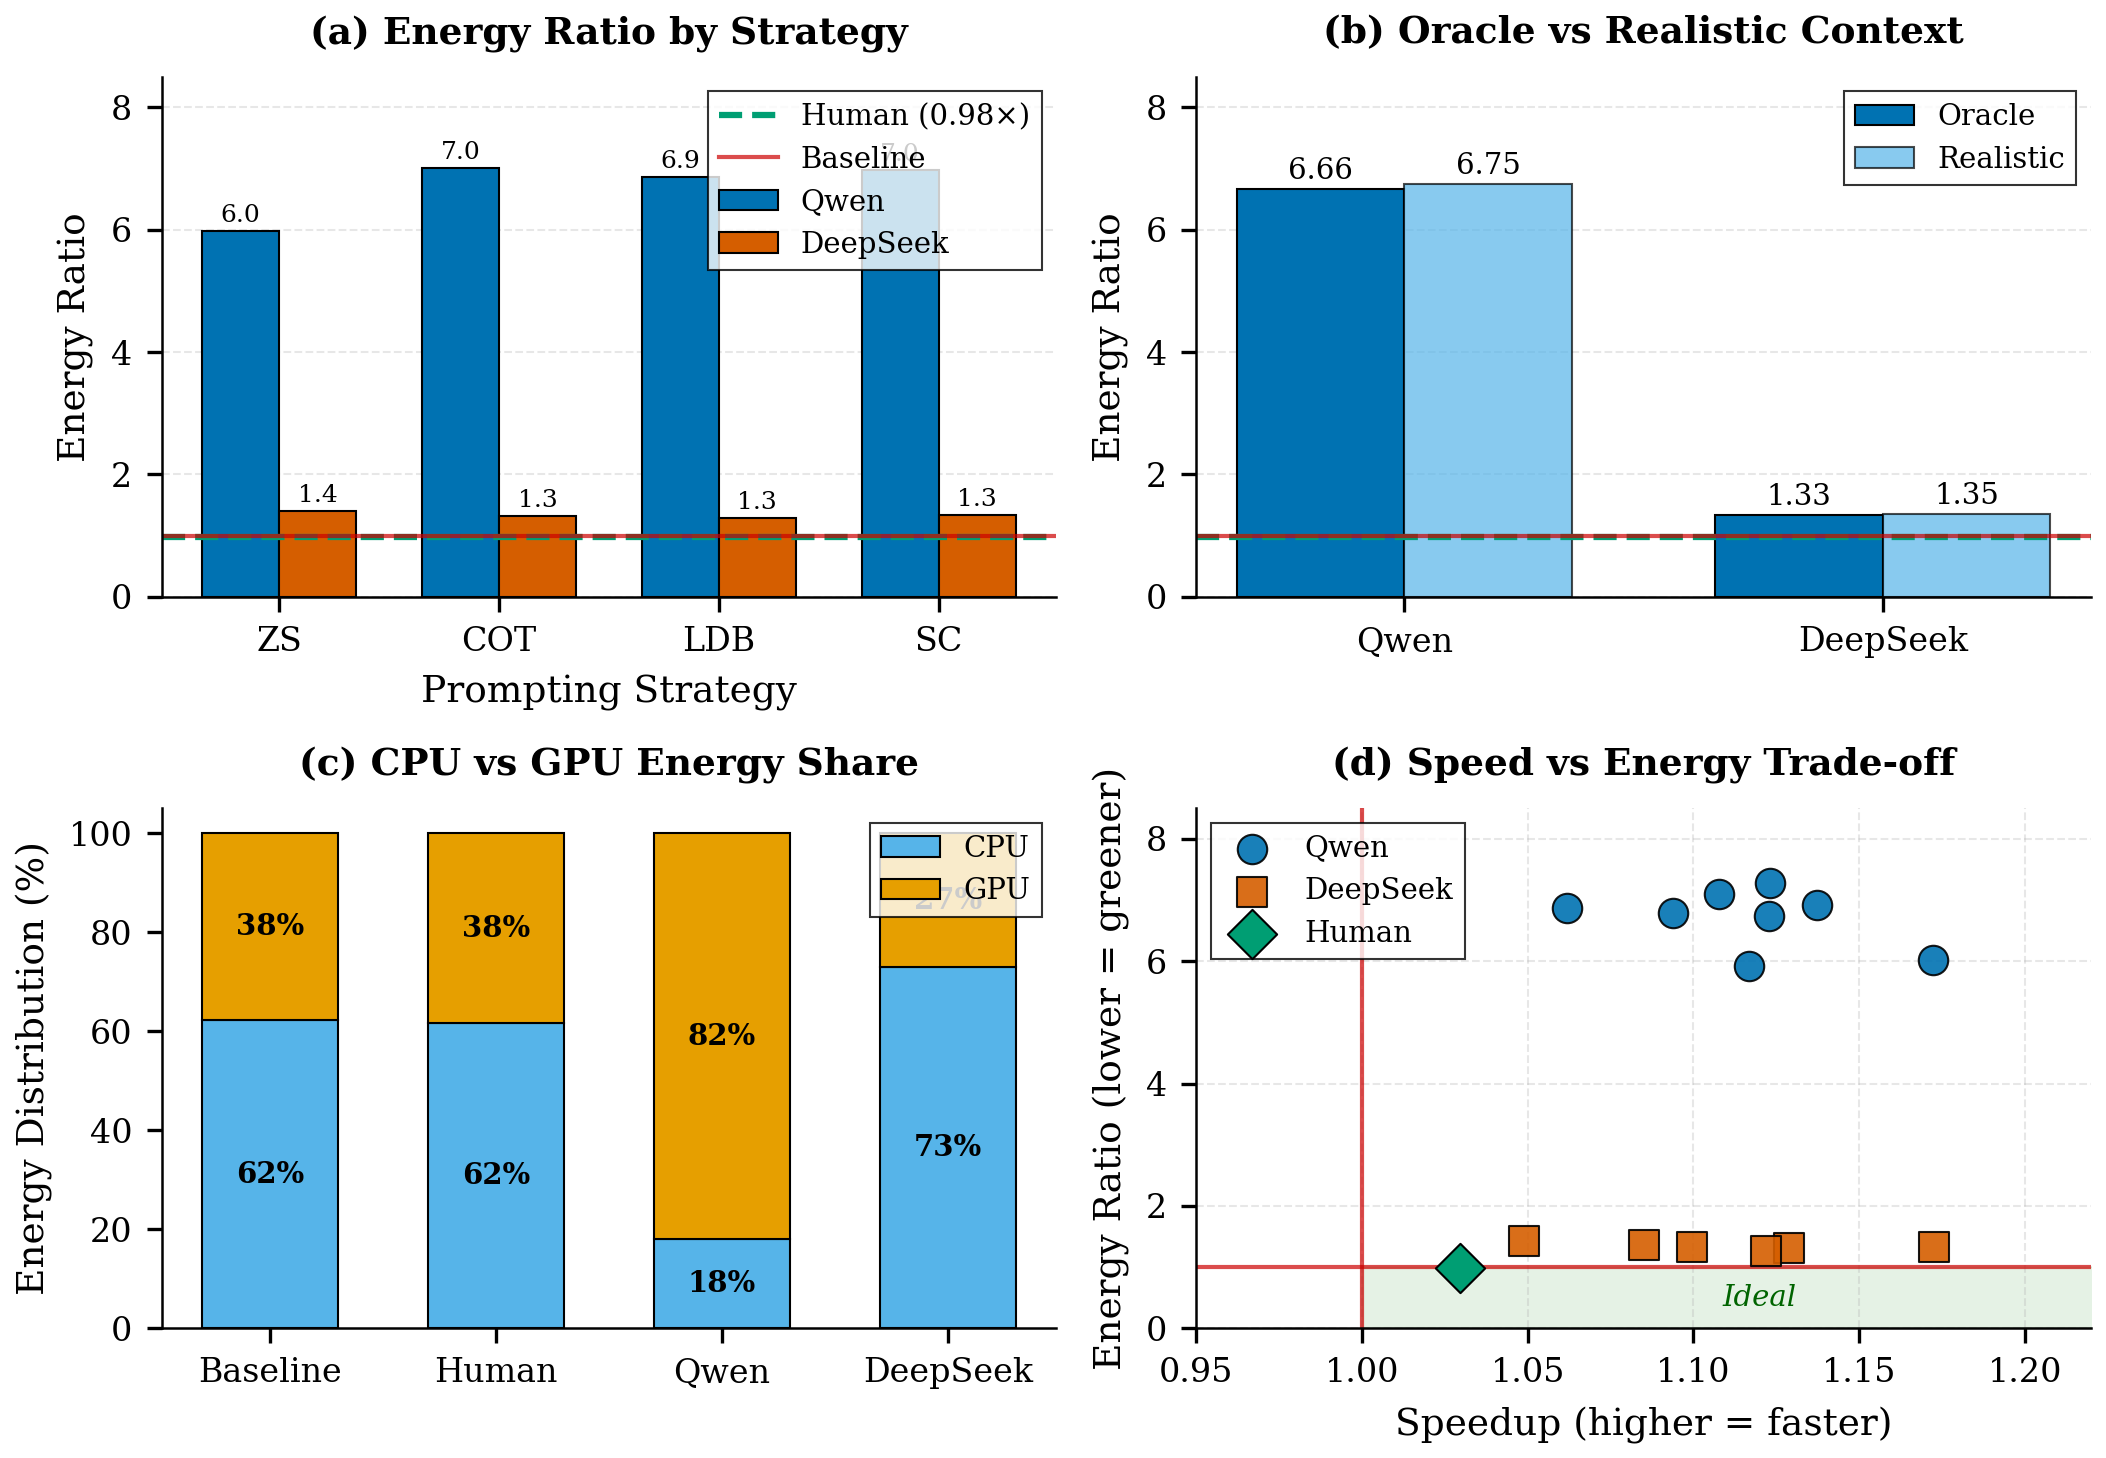

✅ Combined figure saved as 'fig_results_combined.pdf'


In [19]:
# Cell 18: Updated Combined Figure with BOTH models

import matplotlib.pyplot as plt
import numpy as np

# IEEE Conference Style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'axes.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'qwen': '#0072B2',
    'deepseek': '#D55E00',
    'human': '#009E73',
    'baseline': '#CC0000',
    'cpu': '#56B4E9',
    'gpu': '#E69F00',
    'oracle': '#0072B2',
    'realistic': '#56B4E9',
}

fig, axes = plt.subplots(2, 2, figsize=(7.16, 5.0))

# ===========================================================================
# (a) Energy Ratio by Strategy - BOTH MODELS
# ===========================================================================
ax = axes[0, 0]

strategies = ['ZS', 'COT', 'LDB', 'SC']
x = np.arange(len(strategies))
width = 0.35

# Qwen data
qwen_energy = []
for s in strategies:
    val = full_df[(full_df['Model'] == 'Qwen') & (full_df['Strategy'] == s)]['Energy Ratio'].mean()
    qwen_energy.append(val)

# DeepSeek data
deepseek_energy = []
for s in strategies:
    data = full_df[(full_df['Model'] == 'DeepSeek') & (full_df['Strategy'] == s)]
    val = data['Energy Ratio'].mean() if len(data) > 0 else 0
    deepseek_energy.append(val)

bars1 = ax.bar(x - width/2, qwen_energy, width, label='Qwen', 
               color=COLORS['qwen'], edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, deepseek_energy, width, label='DeepSeek', 
               color=COLORS['deepseek'], edgecolor='black', linewidth=0.5)

# Human baseline line
human_ratio = (df['human_head_total_energy_joules_mean'] / df['base_total_energy_joules_mean']).mean()
ax.axhline(y=human_ratio, color=COLORS['human'], linestyle='--', linewidth=1.5, label=f'Human ({human_ratio:.2f}×)')
ax.axhline(y=1, color=COLORS['baseline'], linestyle='-', linewidth=1, alpha=0.7, label='Baseline')

ax.set_ylabel('Energy Ratio')
ax.set_xlabel('Prompting Strategy')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylim(0, 8.5)
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)
ax.set_title('(a) Energy Ratio by Strategy', fontweight='bold', pad=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
               xytext=(0, 1), textcoords="offset points", ha='center', va='bottom', fontsize=6)
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 1), textcoords="offset points", ha='center', va='bottom', fontsize=6)

# ===========================================================================
# (b) Context Setting Comparison - BOTH MODELS
# ===========================================================================
ax = axes[0, 1]

models = ['Qwen', 'DeepSeek']
x = np.arange(len(models))
width = 0.35

oracle_vals = []
realistic_vals = []
for model in models:
    oracle_data = full_df[(full_df['Model'] == model) & (full_df['Context'] == 'Oracle')]
    realistic_data = full_df[(full_df['Model'] == model) & (full_df['Context'] == 'Realistic')]
    oracle_vals.append(oracle_data['Energy Ratio'].mean() if len(oracle_data) > 0 else 0)
    realistic_vals.append(realistic_data['Energy Ratio'].mean() if len(realistic_data) > 0 else 0)

bars1 = ax.bar(x - width/2, oracle_vals, width, label='Oracle', 
               color=COLORS['oracle'], edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, realistic_vals, width, label='Realistic', 
               color=COLORS['realistic'], edgecolor='black', linewidth=0.5, alpha=0.7)

ax.axhline(y=human_ratio, color=COLORS['human'], linestyle='--', linewidth=1.5)
ax.axhline(y=1, color=COLORS['baseline'], linestyle='-', linewidth=1, alpha=0.7)

ax.set_ylabel('Energy Ratio')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 8.5)
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)
ax.set_title('(b) Oracle vs Realistic Context', fontweight='bold', pad=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 1), textcoords="offset points", ha='center', va='bottom', fontsize=7)

# ===========================================================================
# (c) CPU vs GPU Energy Distribution - ALL
# ===========================================================================
ax = axes[1, 0]

categories = ['Baseline', 'Human', 'Qwen', 'DeepSeek']

# Calculate percentages
base_total = df['base_total_energy_joules_mean'].mean()
base_gpu_pct = df['base_gpu_energy_joules_mean'].mean() / base_total * 100
base_cpu_pct = 100 - base_gpu_pct

human_total = df['human_head_total_energy_joules_mean'].mean()
human_gpu_pct = df['human_head_gpu_energy_joules_mean'].mean() / human_total * 100
human_cpu_pct = 100 - human_gpu_pct

qwen_gpu_pct = full_df[full_df['Model'] == 'Qwen']['LLM GPU Share (%)'].mean()
qwen_cpu_pct = 100 - qwen_gpu_pct

deepseek_gpu_pct = full_df[full_df['Model'] == 'DeepSeek']['LLM GPU Share (%)'].mean()
deepseek_cpu_pct = 100 - deepseek_gpu_pct

cpu_vals = [base_cpu_pct, human_cpu_pct, qwen_cpu_pct, deepseek_cpu_pct]
gpu_vals = [base_gpu_pct, human_gpu_pct, qwen_gpu_pct, deepseek_gpu_pct]

x = np.arange(len(categories))
width = 0.6

bars_cpu = ax.bar(x, cpu_vals, width, label='CPU', color=COLORS['cpu'], edgecolor='black', linewidth=0.5)
bars_gpu = ax.bar(x, gpu_vals, width, bottom=cpu_vals, label='GPU', color=COLORS['gpu'], edgecolor='black', linewidth=0.5)

ax.set_ylabel('Energy Distribution (%)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', frameon=True, edgecolor='black', fancybox=False)
ax.set_title('(c) CPU vs GPU Energy Share', fontweight='bold', pad=8)

# Percentage labels
for i, (cpu, gpu) in enumerate(zip(cpu_vals, gpu_vals)):
    if cpu > 10:
        ax.text(i, cpu/2, f'{cpu:.0f}%', ha='center', va='center', fontsize=7, fontweight='bold')
    if gpu > 10:
        ax.text(i, cpu + gpu/2, f'{gpu:.0f}%', ha='center', va='center', fontsize=7, fontweight='bold')

# ===========================================================================
# (d) Speed-Energy Trade-off - ALL CONFIGURATIONS
# ===========================================================================
ax = axes[1, 1]

# Plot each model
for model, color, marker in [('Qwen', COLORS['qwen'], 'o'), 
                              ('DeepSeek', COLORS['deepseek'], 's')]:
    model_data = full_df[full_df['Model'] == model]
    ax.scatter(model_data['Speedup'], model_data['Energy Ratio'], 
              c=color, marker=marker, s=50, label=model, 
              edgecolors='black', linewidths=0.5, alpha=0.9, zorder=3)

# Human point
human_speedup = (df['base_duration_seconds_mean'] / df['human_head_duration_seconds_mean']).mean()
ax.scatter([human_speedup], [human_ratio], c=COLORS['human'], marker='D', s=70, 
          label='Human', edgecolors='black', linewidths=0.5, zorder=4)

# Reference lines
ax.axhline(y=1, color=COLORS['baseline'], linestyle='-', linewidth=1, alpha=0.7)
ax.axvline(x=1, color=COLORS['baseline'], linestyle='-', linewidth=1, alpha=0.7)

# Ideal region
ax.fill_between([1, 1.25], [0, 0], [1, 1], alpha=0.1, color='green', zorder=0)
ax.text(1.12, 0.5, 'Ideal', fontsize=7, ha='center', va='center', color='darkgreen', style='italic')

ax.set_xlabel('Speedup (higher = faster)')
ax.set_ylabel('Energy Ratio (lower = greener)')
ax.set_xlim(0.95, 1.22)
ax.set_ylim(0, 8.5)
ax.legend(loc='upper left', frameon=True, edgecolor='black', fancybox=False)
ax.set_title('(d) Speed vs Energy Trade-off', fontweight='bold', pad=8)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_results_combined.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_results_combined.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Combined figure saved as 'fig_results_combined.pdf'")

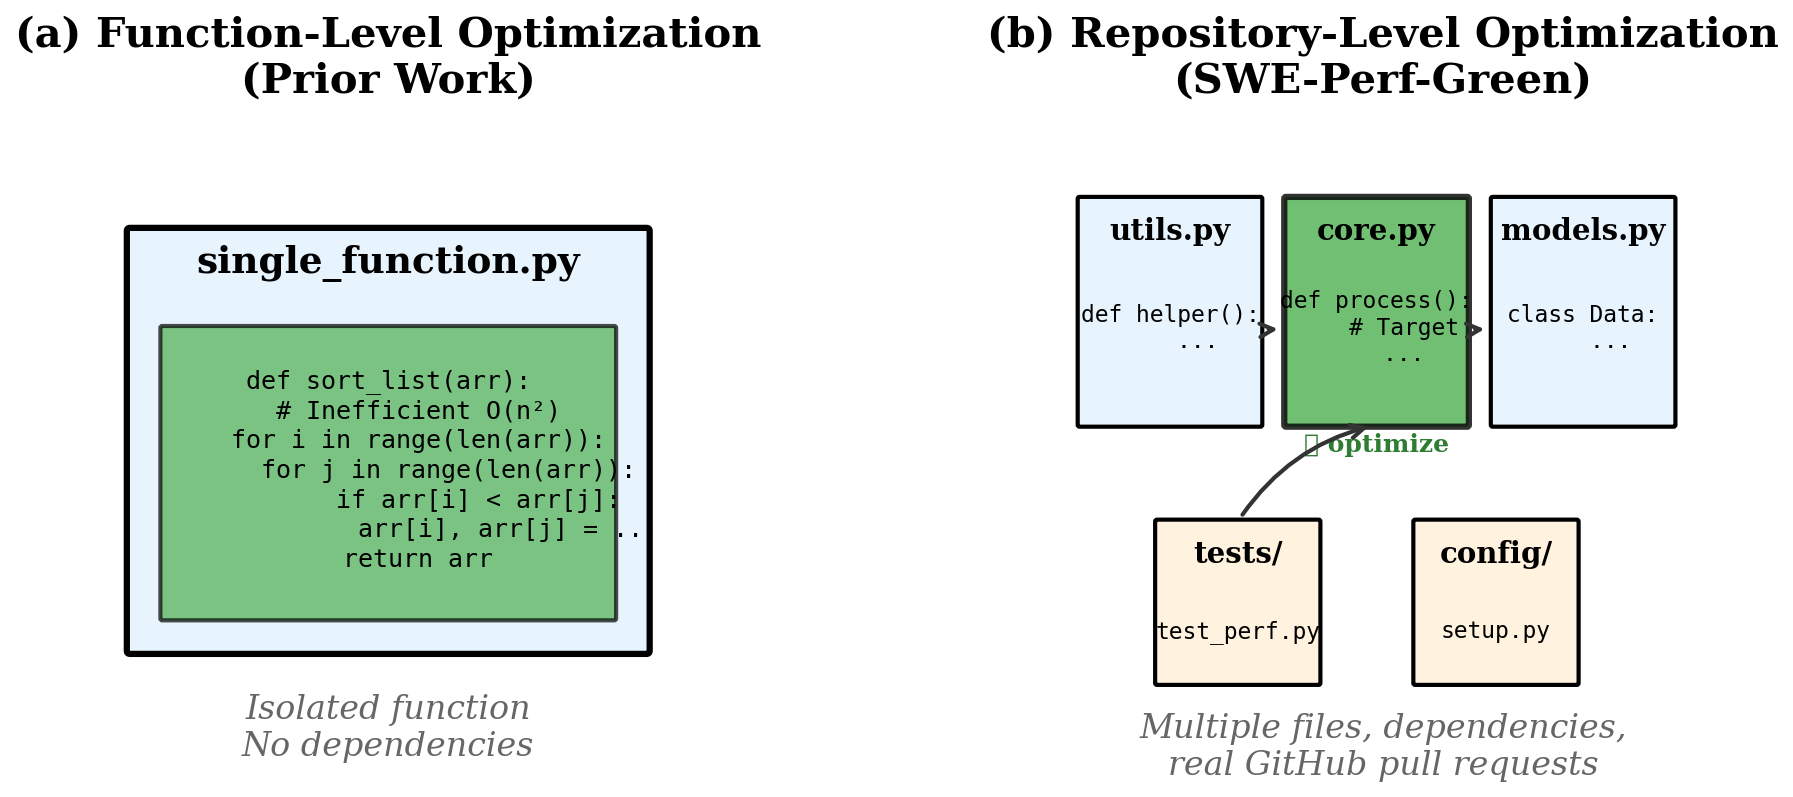

✅ Figure saved as 'fig_function_vs_repo.pdf'


In [20]:
# Cell 19: Figure showing Function-level vs Repository-level optimization

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

# IEEE Style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'figure.dpi': 300,
})

fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.8))

# Colors
COLOR_FILE = '#E8F4FD'
COLOR_FUNCTION = '#BBDEFB'
COLOR_TARGET = '#4CAF50'
COLOR_CONTEXT = '#FFF3E0'
COLOR_ARROW = '#333333'

# ===========================================================================
# LEFT: Function-level (Prior Work)
# ===========================================================================
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('(a) Function-Level Optimization\n(Prior Work)', fontweight='bold', pad=10)

# Single file box
file_box = FancyBboxPatch((1, 2), 8, 6.5, boxstyle="round,pad=0.05", 
                           facecolor=COLOR_FILE, edgecolor='black', linewidth=1.5)
ax.add_patch(file_box)
ax.text(5, 8, 'single_function.py', ha='center', va='center', fontsize=9, fontweight='bold')

# Function inside
func_box = FancyBboxPatch((1.5, 2.5), 7, 4.5, boxstyle="round,pad=0.03",
                          facecolor=COLOR_TARGET, edgecolor='black', linewidth=1, alpha=0.7)
ax.add_patch(func_box)

# Code snippet
code_text = '''def sort_list(arr):
    # Inefficient O(n²)
    for i in range(len(arr)):
        for j in range(len(arr)):
            if arr[i] < arr[j]:
                arr[i], arr[j] = ...
    return arr'''
ax.text(5, 4.8, code_text, ha='center', va='center', fontsize=6, 
        fontfamily='monospace', linespacing=1.3)

# Label
ax.text(5, 0.8, 'Isolated function\nNo dependencies', ha='center', va='center', 
        fontsize=8, style='italic', color='#666666')

# ===========================================================================
# RIGHT: Repository-level (Our Work)
# ===========================================================================
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('(b) Repository-Level Optimization\n(SWE-Perf-Green)', fontweight='bold', pad=10)

# Repository structure - multiple files
# File 1 (utils.py)
f1 = FancyBboxPatch((0.3, 5.5), 2.8, 3.5, boxstyle="round,pad=0.03",
                    facecolor=COLOR_FILE, edgecolor='black', linewidth=1)
ax.add_patch(f1)
ax.text(1.7, 8.5, 'utils.py', ha='center', va='center', fontsize=7, fontweight='bold')
ax.text(1.7, 7, 'def helper():\n    ...', ha='center', va='center', fontsize=5.5, 
        fontfamily='monospace')

# File 2 (core.py) - TARGET
f2 = FancyBboxPatch((3.5, 5.5), 2.8, 3.5, boxstyle="round,pad=0.03",
                    facecolor=COLOR_TARGET, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.add_patch(f2)
ax.text(4.9, 8.5, 'core.py', ha='center', va='center', fontsize=7, fontweight='bold')
ax.text(4.9, 7, 'def process():\n    # Target\n    ...', ha='center', va='center', 
        fontsize=5.5, fontfamily='monospace')
ax.text(4.9, 5.2, '★ optimize', ha='center', va='center', fontsize=6, 
        color='#2E7D32', fontweight='bold')

# File 3 (models.py)
f3 = FancyBboxPatch((6.7, 5.5), 2.8, 3.5, boxstyle="round,pad=0.03",
                    facecolor=COLOR_FILE, edgecolor='black', linewidth=1)
ax.add_patch(f3)
ax.text(8.1, 8.5, 'models.py', ha='center', va='center', fontsize=7, fontweight='bold')
ax.text(8.1, 7, 'class Data:\n    ...', ha='center', va='center', fontsize=5.5, 
        fontfamily='monospace')

# File 4 (tests/)
f4 = FancyBboxPatch((1.5, 1.5), 2.5, 2.5, boxstyle="round,pad=0.03",
                    facecolor=COLOR_CONTEXT, edgecolor='black', linewidth=1)
ax.add_patch(f4)
ax.text(2.75, 3.5, 'tests/', ha='center', va='center', fontsize=7, fontweight='bold')
ax.text(2.75, 2.3, 'test_perf.py', ha='center', va='center', fontsize=5.5, 
        fontfamily='monospace')

# File 5 (config)
f5 = FancyBboxPatch((5.5, 1.5), 2.5, 2.5, boxstyle="round,pad=0.03",
                    facecolor=COLOR_CONTEXT, edgecolor='black', linewidth=1)
ax.add_patch(f5)
ax.text(6.75, 3.5, 'config/', ha='center', va='center', fontsize=7, fontweight='bold')
ax.text(6.75, 2.3, 'setup.py', ha='center', va='center', fontsize=5.5, 
        fontfamily='monospace')

# Arrows showing dependencies
arrow_style = dict(arrowstyle='->', color=COLOR_ARROW, lw=1, 
                   connectionstyle='arc3,rad=0.1')
ax.annotate('', xy=(3.5, 7), xytext=(3.1, 7), arrowprops=arrow_style)
ax.annotate('', xy=(6.7, 7), xytext=(6.3, 7), arrowprops=arrow_style)
ax.annotate('', xy=(4.9, 5.5), xytext=(2.75, 4), arrowprops=dict(arrowstyle='->', 
            color=COLOR_ARROW, lw=1, connectionstyle='arc3,rad=-0.2'))

# Label
ax.text(5, 0.5, 'Multiple files, dependencies,\nreal GitHub pull requests', 
        ha='center', va='center', fontsize=8, style='italic', color='#666666')

plt.tight_layout()
plt.savefig('fig_function_vs_repo.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_function_vs_repo.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Figure saved as 'fig_function_vs_repo.pdf'")

In [21]:
# Cell 20: Create draw.io XML files

# Function-level vs Repository-level comparison figure

drawio_xml = '''<?xml version="1.0" encoding="UTF-8"?>
<mxfile host="app.diagrams.net" modified="2025-01-18T12:00:00.000Z" agent="Mozilla/5.0" version="21.0.0" type="device">
  <diagram id="func-vs-repo" name="Function vs Repository Level">
    <mxGraphModel dx="1434" dy="780" grid="1" gridSize="10" guides="1" tooltips="1" connect="1" arrows="1" fold="1" page="1" pageScale="1" pageWidth="1100" pageHeight="400" math="0" shadow="0">
      <root>
        <mxCell id="0" />
        <mxCell id="1" parent="0" />
        
        <!-- ==================== LEFT PANEL: Function-Level ==================== -->
        
        <!-- Title (a) -->
        <mxCell id="title_a" value="&lt;b&gt;(a) Function-Level Optimization&lt;/b&gt;&lt;br&gt;&lt;i&gt;Prior Work&lt;/i&gt;" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=14;" vertex="1" parent="1">
          <mxGeometry x="80" y="20" width="280" height="40" as="geometry" />
        </mxCell>
        
        <!-- Main file box -->
        <mxCell id="func_file" value="" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#E3F2FD;strokeColor=#1976D2;strokeWidth=2;" vertex="1" parent="1">
          <mxGeometry x="40" y="70" width="360" height="280" as="geometry" />
        </mxCell>
        
        <!-- File name -->
        <mxCell id="func_filename" value="&lt;b&gt;sort_algorithm.py&lt;/b&gt;" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=12;" vertex="1" parent="1">
          <mxGeometry x="140" y="80" width="160" height="20" as="geometry" />
        </mxCell>
        
        <!-- Before code box -->
        <mxCell id="func_before" value="&lt;font face=&quot;Courier New&quot;&gt;def sort_list(arr):&lt;br&gt;&amp;nbsp; &amp;nbsp; # Inefficient O(n²)&lt;br&gt;&amp;nbsp; &amp;nbsp; for i in range(len(arr)):&lt;br&gt;&amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; for j in range(i+1, len(arr)):&lt;br&gt;&amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; if arr[i] &amp;gt; arr[j]:&lt;br&gt;&amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; arr[i], arr[j] = arr[j], arr[i]&lt;br&gt;&amp;nbsp; &amp;nbsp; return arr&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#1976D2;strokeWidth=1;align=left;verticalAlign=top;spacingLeft=10;spacingTop=10;fontSize=10;" vertex="1" parent="1">
          <mxGeometry x="60" y="110" width="320" height="100" as="geometry" />
        </mxCell>
        
        <!-- Arrow down -->
        <mxCell id="func_arrow" value="" style="endArrow=classic;html=1;strokeColor=#4CAF50;strokeWidth=3;entryX=0.5;entryY=0;exitX=0.5;exitY=1;" edge="1" parent="1">
          <mxGeometry width="50" height="50" relative="1" as="geometry">
            <mxPoint x="220" y="215" as="sourcePoint" />
            <mxPoint x="220" y="245" as="targetPoint" />
          </mxGeometry>
        </mxCell>
        
        <!-- Optimize label -->
        <mxCell id="func_optimize" value="&lt;b&gt;&lt;font color=&quot;#4CAF50&quot;&gt;OPTIMIZE&lt;/font&gt;&lt;/b&gt;" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=11;" vertex="1" parent="1">
          <mxGeometry x="240" y="218" width="70" height="20" as="geometry" />
        </mxCell>
        
        <!-- After code box -->
        <mxCell id="func_after" value="&lt;font face=&quot;Courier New&quot;&gt;def sort_list(arr):&lt;br&gt;&amp;nbsp; &amp;nbsp; return sorted(arr)&amp;nbsp; # O(n log n)&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#E8F5E9;strokeColor=#4CAF50;strokeWidth=2;align=left;verticalAlign=top;spacingLeft=10;spacingTop=10;fontSize=10;" vertex="1" parent="1">
          <mxGeometry x="60" y="250" width="320" height="50" as="geometry" />
        </mxCell>
        
        <!-- Description -->
        <mxCell id="func_desc" value="&lt;i&gt;&lt;font color=&quot;#666666&quot;&gt;✓ Isolated function&lt;br&gt;✓ No dependencies&lt;br&gt;✓ Synthetic benchmarks (e.g., LeetCode)&lt;/font&gt;&lt;/i&gt;" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=10;" vertex="1" parent="1">
          <mxGeometry x="100" y="310" width="240" height="50" as="geometry" />
        </mxCell>
        
        <!-- ==================== DIVIDER ==================== -->
        <mxCell id="divider" value="" style="endArrow=none;dashed=1;html=1;strokeColor=#999999;strokeWidth=2;" edge="1" parent="1">
          <mxGeometry width="50" height="50" relative="1" as="geometry">
            <mxPoint x="440" y="350" as="sourcePoint" />
            <mxPoint x="440" y="30" as="targetPoint" />
          </mxGeometry>
        </mxCell>
        
        <!-- ==================== RIGHT PANEL: Repository-Level ==================== -->
        
        <!-- Title (b) -->
        <mxCell id="title_b" value="&lt;b&gt;(b) Repository-Level Optimization&lt;/b&gt;&lt;br&gt;&lt;i&gt;SWE-Perf-Green (Ours)&lt;/i&gt;" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=14;" vertex="1" parent="1">
          <mxGeometry x="520" y="20" width="280" height="40" as="geometry" />
        </mxCell>
        
        <!-- Repository box -->
        <mxCell id="repo_box" value="" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#E8F5E9;strokeColor=#2E7D32;strokeWidth=2;" vertex="1" parent="1">
          <mxGeometry x="480" y="70" width="580" height="280" as="geometry" />
        </mxCell>
        
        <!-- Repo name -->
        <mxCell id="repo_name" value="&lt;b&gt;scikit-learn/scikit-learn&lt;/b&gt;" style="text;html=1;strokeColor=none;fillColor=none;align=center;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=12;" vertex="1" parent="1">
          <mxGeometry x="680" y="78" width="180" height="20" as="geometry" />
        </mxCell>
        
        <!-- File 1: utils.py -->
        <mxCell id="file_utils" value="&lt;b&gt;sklearn/utils.py&lt;/b&gt;&lt;hr&gt;&lt;font face=&quot;Courier New&quot; size=&quot;1&quot;&gt;def check_array():&lt;br&gt;&amp;nbsp; &amp;nbsp; ...&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#1976D2;strokeWidth=1;align=center;verticalAlign=top;spacingTop=5;fontSize=9;" vertex="1" parent="1">
          <mxGeometry x="500" y="105" width="120" height="70" as="geometry" />
        </mxCell>
        
        <!-- File 2: _base.py -->
        <mxCell id="file_base" value="&lt;b&gt;sklearn/base.py&lt;/b&gt;&lt;hr&gt;&lt;font face=&quot;Courier New&quot; size=&quot;1&quot;&gt;class BaseEstimator:&lt;br&gt;&amp;nbsp; &amp;nbsp; ...&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#1976D2;strokeWidth=1;align=center;verticalAlign=top;spacingTop=5;fontSize=9;" vertex="1" parent="1">
          <mxGeometry x="710" y="105" width="120" height="70" as="geometry" />
        </mxCell>
        
        <!-- File 3: metrics.py -->
        <mxCell id="file_metrics" value="&lt;b&gt;sklearn/metrics.py&lt;/b&gt;&lt;hr&gt;&lt;font face=&quot;Courier New&quot; size=&quot;1&quot;&gt;def accuracy_score():&lt;br&gt;&amp;nbsp; &amp;nbsp; ...&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#FFFFFF;strokeColor=#1976D2;strokeWidth=1;align=center;verticalAlign=top;spacingTop=5;fontSize=9;" vertex="1" parent="1">
          <mxGeometry x="920" y="105" width="120" height="70" as="geometry" />
        </mxCell>
        
        <!-- TARGET File: _forest.py -->
        <mxCell id="file_target" value="&lt;b&gt;★ sklearn/ensemble/_forest.py&lt;/b&gt;&lt;hr&gt;&lt;font face=&quot;Courier New&quot; size=&quot;1&quot;&gt;def fit(self, X, y):&lt;br&gt;&amp;nbsp; &amp;nbsp; # Performance bottleneck&lt;br&gt;&amp;nbsp; &amp;nbsp; trees = [self._fit_tree(...)&lt;br&gt;&amp;nbsp; &amp;nbsp; &amp;nbsp; &amp;nbsp; for i in range(n)]&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#FFF3E0;strokeColor=#FF9800;strokeWidth=3;align=center;verticalAlign=top;spacingTop=5;fontSize=9;" vertex="1" parent="1">
          <mxGeometry x="680" y="200" width="180" height="90" as="geometry" />
        </mxCell>
        
        <!-- PR Label -->
        <mxCell id="pr_label" value="&lt;font color=&quot;#E65100&quot;&gt;&lt;b&gt;← PR #12230&lt;/b&gt;&lt;br&gt;Optimize parallel fitting&lt;/font&gt;" style="text;html=1;strokeColor=none;fillColor=none;align=left;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=9;" vertex="1" parent="1">
          <mxGeometry x="870" y="220" width="120" height="40" as="geometry" />
        </mxCell>
        
        <!-- Tests folder -->
        <mxCell id="file_tests" value="&lt;b&gt;tests/&lt;/b&gt;&lt;hr&gt;&lt;font face=&quot;Courier New&quot; size=&quot;1&quot;&gt;test_forest.py&lt;br&gt;test_ensemble.py&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#F3E5F5;strokeColor=#7B1FA2;strokeWidth=1;align=center;verticalAlign=top;spacingTop=5;fontSize=9;" vertex="1" parent="1">
          <mxGeometry x="520" y="305" width="100" height="60" as="geometry" />
        </mxCell>
        
        <!-- Setup.py -->
        <mxCell id="file_setup" value="&lt;b&gt;setup.py&lt;/b&gt;&lt;hr&gt;&lt;font face=&quot;Courier New&quot; size=&quot;1&quot;&gt;dependencies&lt;br&gt;config&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#ECEFF1;strokeColor=#607D8B;strokeWidth=1;align=center;verticalAlign=top;spacingTop=5;fontSize=9;" vertex="1" parent="1">
          <mxGeometry x="720" y="305" width="100" height="60" as="geometry" />
        </mxCell>
        
        <!-- Docs folder -->
        <mxCell id="file_docs" value="&lt;b&gt;docs/&lt;/b&gt;&lt;hr&gt;&lt;font face=&quot;Courier New&quot; size=&quot;1&quot;&gt;api_reference&lt;br&gt;examples&lt;/font&gt;" style="rounded=1;whiteSpace=wrap;html=1;fillColor=#ECEFF1;strokeColor=#607D8B;strokeWidth=1;align=center;verticalAlign=top;spacingTop=5;fontSize=9;" vertex="1" parent="1">
          <mxGeometry x="920" y="305" width="100" height="60" as="geometry" />
        </mxCell>
        
        <!-- Arrows: dependencies -->
        <mxCell id="arrow1" value="" style="endArrow=classic;html=1;strokeColor=#666666;strokeWidth=1;exitX=1;exitY=0.5;entryX=0;entryY=0.5;" edge="1" parent="1" source="file_utils" target="file_base">
          <mxGeometry width="50" height="50" relative="1" as="geometry" />
        </mxCell>
        
        <mxCell id="arrow2" value="" style="endArrow=classic;html=1;strokeColor=#666666;strokeWidth=1;exitX=1;exitY=0.5;entryX=0;entryY=0.5;" edge="1" parent="1" source="file_base" target="file_metrics">
          <mxGeometry width="50" height="50" relative="1" as="geometry" />
        </mxCell>
        
        <mxCell id="arrow3" value="" style="endArrow=classic;html=1;strokeColor=#FF9800;strokeWidth=2;exitX=0.5;exitY=1;entryX=0.5;entryY=0;" edge="1" parent="1" source="file_base" target="file_target">
          <mxGeometry width="50" height="50" relative="1" as="geometry" />
        </mxCell>
        
        <mxCell id="arrow4" value="" style="endArrow=classic;html=1;strokeColor=#666666;strokeWidth=1;dashed=1;exitX=0.5;exitY=1;entryX=0.5;entryY=0;" edge="1" parent="1" source="file_target" target="file_tests">
          <mxGeometry width="50" height="50" relative="1" as="geometry">
            <mxPoint x="770" y="290" as="sourcePoint" />
            <mxPoint x="570" y="305" as="targetPoint" />
            <Array as="points">
              <mxPoint x="770" y="295" />
              <mxPoint x="570" y="295" />
            </Array>
          </mxGeometry>
        </mxCell>
        
        <!-- Description -->
        <mxCell id="repo_desc" value="&lt;i&gt;&lt;font color=&quot;#666666&quot;&gt;✓ Real GitHub pull requests&lt;br&gt;✓ Cross-file dependencies&lt;br&gt;✓ Full test suites&lt;/font&gt;&lt;/i&gt;" style="text;html=1;strokeColor=none;fillColor=none;align=left;verticalAlign=middle;whiteSpace=wrap;rounded=0;fontSize=10;" vertex="1" parent="1">
          <mxGeometry x="500" y="195" width="170" height="50" as="geometry" />
        </mxCell>
        
      </root>
    </mxGraphModel>
  </diagram>
</mxfile>'''

# Save the file
with open('fig_function_vs_repo.drawio', 'w', encoding='utf-8') as f:
    f.write(drawio_xml)

print("✅ File saved: fig_function_vs_repo.drawio")
print("\nPer usarlo:")
print("1. Vai su https://app.diagrams.net/")
print("2. File → Open from → Device")
print("3. Seleziona 'fig_function_vs_repo.drawio'")
print("4. Modifica come preferisci")
print("5. File → Export as → PDF (o PNG)")

✅ File saved: fig_function_vs_repo.drawio

Per usarlo:
1. Vai su https://app.diagrams.net/
2. File → Open from → Device
3. Seleziona 'fig_function_vs_repo.drawio'
4. Modifica come preferisci
5. File → Export as → PDF (o PNG)


In [22]:
import pandas as pd

# Carica il dataset (aggiusta il path se necessario)
df = pd.read_csv('/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/green/FINAL_UNIFIED_BENCHMARK.csv')  # o il nome del tuo file

# ============================================
# DATI PER CARBON FOOTPRINT (ACKNOWLEDGMENTS)
# ============================================

print("=" * 60)
print("DATI PER ACKNOWLEDGMENTS - CARBON FOOTPRINT")
print("=" * 60)

# 1. Energia totale consumata (tutte le misurazioni)
# Cerca colonne con energia (adatta i nomi se diversi)
energy_cols = [col for col in df.columns if 'energy' in col.lower() or 'joule' in col.lower()]
print(f"\nColonne energia trovate: {energy_cols}")

# Energia totale baseline
if 'baseline_total_energy_mean' in df.columns:
    baseline_energy_j = df['baseline_total_energy_mean'].sum()
    print(f"\nEnergia baseline totale: {baseline_energy_j:.2f} J ({baseline_energy_j/3600000:.4f} kWh)")

# Energia totale human
if 'human_total_energy_mean' in df.columns:
    human_energy_j = df['human_total_energy_mean'].sum()
    print(f"Energia human totale: {human_energy_j:.2f} J ({human_energy_j/3600000:.4f} kWh)")

# Energia totale LLM (tutte le configurazioni)
llm_energy_cols = [col for col in df.columns if 'llm_' in col.lower() and 'energy' in col.lower() and 'mean' in col.lower()]
print(f"\nColonne energia LLM: {llm_energy_cols}")

total_llm_energy = 0
for col in llm_energy_cols:
    col_sum = df[col].dropna().sum()
    total_llm_energy += col_sum
    print(f"  {col}: {col_sum:.2f} J")

print(f"\nEnergia LLM totale: {total_llm_energy:.2f} J ({total_llm_energy/3600000:.4f} kWh)")

# 2. Energia TOTALE esperimento
total_energy_j = 0
if 'baseline_total_energy_mean' in df.columns:
    total_energy_j += df['baseline_total_energy_mean'].sum()
if 'human_total_energy_mean' in df.columns:
    total_energy_j += df['human_total_energy_mean'].sum()
total_energy_j += total_llm_energy

# Moltiplica per k=3 ripetizioni + 1 warmup = 4 runs per configurazione
total_energy_j_with_reps = total_energy_j * 4

print(f"\n" + "=" * 60)
print(f"ENERGIA TOTALE ESPERIMENTO: {total_energy_j:.2f} J")
print(f"ENERGIA CON RIPETIZIONI (x4): {total_energy_j_with_reps:.2f} J")
print(f"ENERGIA TOTALE: {total_energy_j_with_reps/3600000:.4f} kWh")
print("=" * 60)

# 3. Calcolo Carbon Footprint
# Grid intensity Spagna: ~200 gCO2/kWh (aggiorna se hai dato più preciso)
GRID_INTENSITY_SPAIN = 200  # gCO2/kWh

total_kwh = total_energy_j_with_reps / 3600000
carbon_footprint_g = total_kwh * GRID_INTENSITY_SPAIN
carbon_footprint_kg = carbon_footprint_g / 1000

print(f"\n" + "=" * 60)
print(f"CARBON FOOTPRINT")
print(f"=" * 60)
print(f"Grid intensity (Spain): {GRID_INTENSITY_SPAIN} gCO2/kWh")
print(f"Carbon footprint: {carbon_footprint_g:.2f} gCO2 ({carbon_footprint_kg:.4f} kgCO2)")

# 4. Conversione in km auto elettrica
# Media: ~0.15 kWh/km per auto elettrica
KWH_PER_KM = 0.15
equivalent_km = total_kwh / KWH_PER_KM
equivalent_miles = equivalent_km * 0.621371

print(f"\nEquivalente auto elettrica: {equivalent_km:.2f} km ({equivalent_miles:.2f} miles)")

# 5. Statistiche aggiuntive
print(f"\n" + "=" * 60)
print(f"STATISTICHE AGGIUNTIVE")
print(f"=" * 60)
print(f"Numero istanze nel dataset: {len(df)}")
print(f"Numero configurazioni LLM: {len(llm_energy_cols)}")

# Conta patches successful
pass_cols = [col for col in df.columns if 'pass' in col.lower()]
print(f"\nColonne pass rate: {pass_cols}")

# Durata totale (se disponibile)
duration_cols = [col for col in df.columns if 'duration' in col.lower() or 'time' in col.lower()]
print(f"\nColonne durata: {duration_cols[:10]}...")  # prime 10

if 'baseline_duration_mean' in df.columns:
    total_duration_baseline = df['baseline_duration_mean'].sum()
    print(f"\nDurata totale baseline: {total_duration_baseline:.2f} s ({total_duration_baseline/3600:.2f} h)")

DATI PER ACKNOWLEDGMENTS - CARBON FOOTPRINT

Colonne energia trovate: ['base_total_energy_joules_mean', 'base_cpu_energy_joules_mean', 'base_gpu_energy_joules_mean', 'human_head_total_energy_joules_mean', 'human_head_cpu_energy_joules_mean', 'human_head_gpu_energy_joules_mean', 'qwen_zs_oracle_total_energy_joules_mean', 'qwen_zs_oracle_cpu_energy_joules_mean', 'qwen_zs_oracle_gpu_energy_joules_mean', 'qwen_zs_realistic_total_energy_joules_mean', 'qwen_zs_realistic_cpu_energy_joules_mean', 'qwen_zs_realistic_gpu_energy_joules_mean', 'qwen_cot_oracle_total_energy_joules_mean', 'qwen_cot_oracle_cpu_energy_joules_mean', 'qwen_cot_oracle_gpu_energy_joules_mean', 'qwen_cot_realistic_total_energy_joules_mean', 'qwen_cot_realistic_cpu_energy_joules_mean', 'qwen_cot_realistic_gpu_energy_joules_mean', 'qwen_ldb_oracle_total_energy_joules_mean', 'qwen_ldb_oracle_cpu_energy_joules_mean', 'qwen_ldb_oracle_gpu_energy_joules_mean', 'qwen_ldb_realistic_total_energy_joules_mean', 'qwen_ldb_realistic_cp

In [23]:
import pandas as pd

# Carica il dataset
df = pd.read_csv('/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/green/FINAL_UNIFIED_BENCHMARK.csv')

print("=" * 60)
print("DATI PER ACKNOWLEDGMENTS - CARBON FOOTPRINT")
print("=" * 60)

# 1. Energia BASELINE
base_energy = df['base_total_energy_joules_mean'].sum()
print(f"\nEnergia baseline totale: {base_energy:.2f} J ({base_energy/3600000:.6f} kWh)")

# 2. Energia HUMAN
human_energy = df['human_head_total_energy_joules_mean'].sum()
print(f"Energia human totale: {human_energy:.2f} J ({human_energy/3600000:.6f} kWh)")

# 3. Energia LLM (tutte le configurazioni)
llm_configs = [
    'qwen_zs_oracle', 'qwen_zs_realistic',
    'qwen_cot_oracle', 'qwen_cot_realistic',
    'qwen_ldb_oracle', 'qwen_ldb_realistic',
    'qwen_sc_oracle', 'qwen_sc_realistic',
    'deepseek_zs_oracle', 'deepseek_zs_realistic',
    'deepseek_cot_oracle',
    'deepseek_ldb_oracle', 'deepseek_ldb_realistic',
    'deepseek_sc_oracle'
]

total_llm_energy = 0
print(f"\nEnergia per configurazione LLM:")
for config in llm_configs:
    col = f'{config}_total_energy_joules_mean'
    if col in df.columns:
        col_sum = df[col].dropna().sum()
        total_llm_energy += col_sum
        print(f"  {config}: {col_sum:.2f} J")

print(f"\nEnergia LLM totale: {total_llm_energy:.2f} J ({total_llm_energy/3600000:.6f} kWh)")

# 4. ENERGIA TOTALE
total_energy_j = base_energy + human_energy + total_llm_energy

# Con k=3 ripetizioni + 1 warmup = 4 runs
total_energy_with_reps = total_energy_j * 4

print(f"\n" + "=" * 60)
print(f"ENERGIA TOTALE (singola run): {total_energy_j:.2f} J ({total_energy_j/3600000:.6f} kWh)")
print(f"ENERGIA CON RIPETIZIONI (x4): {total_energy_with_reps:.2f} J ({total_energy_with_reps/3600000:.6f} kWh)")
print("=" * 60)

# 5. CARBON FOOTPRINT
# Grid intensity Spagna 2024: ~150-200 gCO2/kWh
GRID_INTENSITY_SPAIN = 180  # gCO2/kWh (valore medio)

total_kwh = total_energy_with_reps / 3600000
carbon_g = total_kwh * GRID_INTENSITY_SPAIN
carbon_kg = carbon_g / 1000

print(f"\n" + "=" * 60)
print(f"CARBON FOOTPRINT")
print("=" * 60)
print(f"Grid intensity (Spain): {GRID_INTENSITY_SPAIN} gCO2/kWh")
print(f"Energia totale: {total_kwh:.4f} kWh")
print(f"Carbon footprint: {carbon_g:.2f} gCO2 ({carbon_kg:.4f} kgCO2)")

# Equivalente auto elettrica (~0.17 kWh/km media)
KWH_PER_KM = 0.17
equivalent_km = total_kwh / KWH_PER_KM
equivalent_miles = equivalent_km * 0.621371
print(f"\nEquivalente auto elettrica: {equivalent_km:.2f} km ({equivalent_miles:.2f} miles)")

# 6. DURATA TOTALE
print(f"\n" + "=" * 60)
print(f"DURATA TOTALE")
print("=" * 60)

base_duration = df['base_duration_seconds_mean'].sum()
human_duration = df['human_head_duration_seconds_mean'].sum()

total_llm_duration = 0
for config in llm_configs:
    col = f'{config}_duration_seconds_mean'
    if col in df.columns:
        total_llm_duration += df[col].dropna().sum()

total_duration = base_duration + human_duration + total_llm_duration
total_duration_with_reps = total_duration * 4

print(f"Durata baseline: {base_duration:.2f} s")
print(f"Durata human: {human_duration:.2f} s")
print(f"Durata LLM totale: {total_llm_duration:.2f} s")
print(f"DURATA TOTALE (singola): {total_duration:.2f} s ({total_duration/3600:.2f} h)")
print(f"DURATA CON REPS (x4): {total_duration_with_reps:.2f} s ({total_duration_with_reps/3600:.2f} h)")

# 7. RIEPILOGO FINALE
print(f"\n" + "=" * 60)
print(f"RIEPILOGO PER ACKNOWLEDGMENTS")
print("=" * 60)
print(f"• Energia totale esperimento: {total_kwh:.4f} kWh")
print(f"• Carbon footprint: {carbon_kg:.4f} kg CO2")
print(f"• Equivalente auto elettrica: {equivalent_km:.2f} km ({equivalent_miles:.2f} miles)")
print(f"• Durata totale: {total_duration_with_reps/3600:.2f} ore")

DATI PER ACKNOWLEDGMENTS - CARBON FOOTPRINT

Energia baseline totale: 9253.02 J (0.002570 kWh)
Energia human totale: 8897.06 J (0.002471 kWh)

Energia per configurazione LLM:
  qwen_zs_oracle: 28922.45 J
  qwen_zs_realistic: 29360.08 J
  qwen_cot_oracle: 20885.09 J
  qwen_cot_realistic: 28737.25 J
  qwen_ldb_oracle: 36998.79 J
  qwen_ldb_realistic: 28726.85 J
  qwen_sc_oracle: 26522.62 J
  qwen_sc_realistic: 32404.63 J
  deepseek_zs_oracle: 1838.91 J
  deepseek_zs_realistic: 541.09 J
  deepseek_cot_oracle: 920.59 J
  deepseek_ldb_oracle: 2285.76 J
  deepseek_ldb_realistic: 641.85 J
  deepseek_sc_oracle: 684.06 J

Energia LLM totale: 239470.02 J (0.066519 kWh)

ENERGIA TOTALE (singola run): 257620.10 J (0.071561 kWh)
ENERGIA CON RIPETIZIONI (x4): 1030480.39 J (0.286245 kWh)

CARBON FOOTPRINT
Grid intensity (Spain): 180 gCO2/kWh
Energia totale: 0.2862 kWh
Carbon footprint: 51.52 gCO2 (0.0515 kgCO2)

Equivalente auto elettrica: 1.68 km (1.05 miles)

DURATA TOTALE
Durata baseline: 218.61 s

Dati estratti: 618 osservazioni
model     strategy  context  
Deepseek  COT       Oracle        9
          LDB       Oracle       28
                    Realistic     8
          SC        Oracle        8
          ZS        Oracle       19
                    Realistic     6
Qwen      COT       Oracle       50
                    Realistic    60
          LDB       Oracle       82
                    Realistic    65
          SC        Oracle       58
                    Realistic    74
          ZS        Oracle       74
                    Realistic    77
dtype: int64


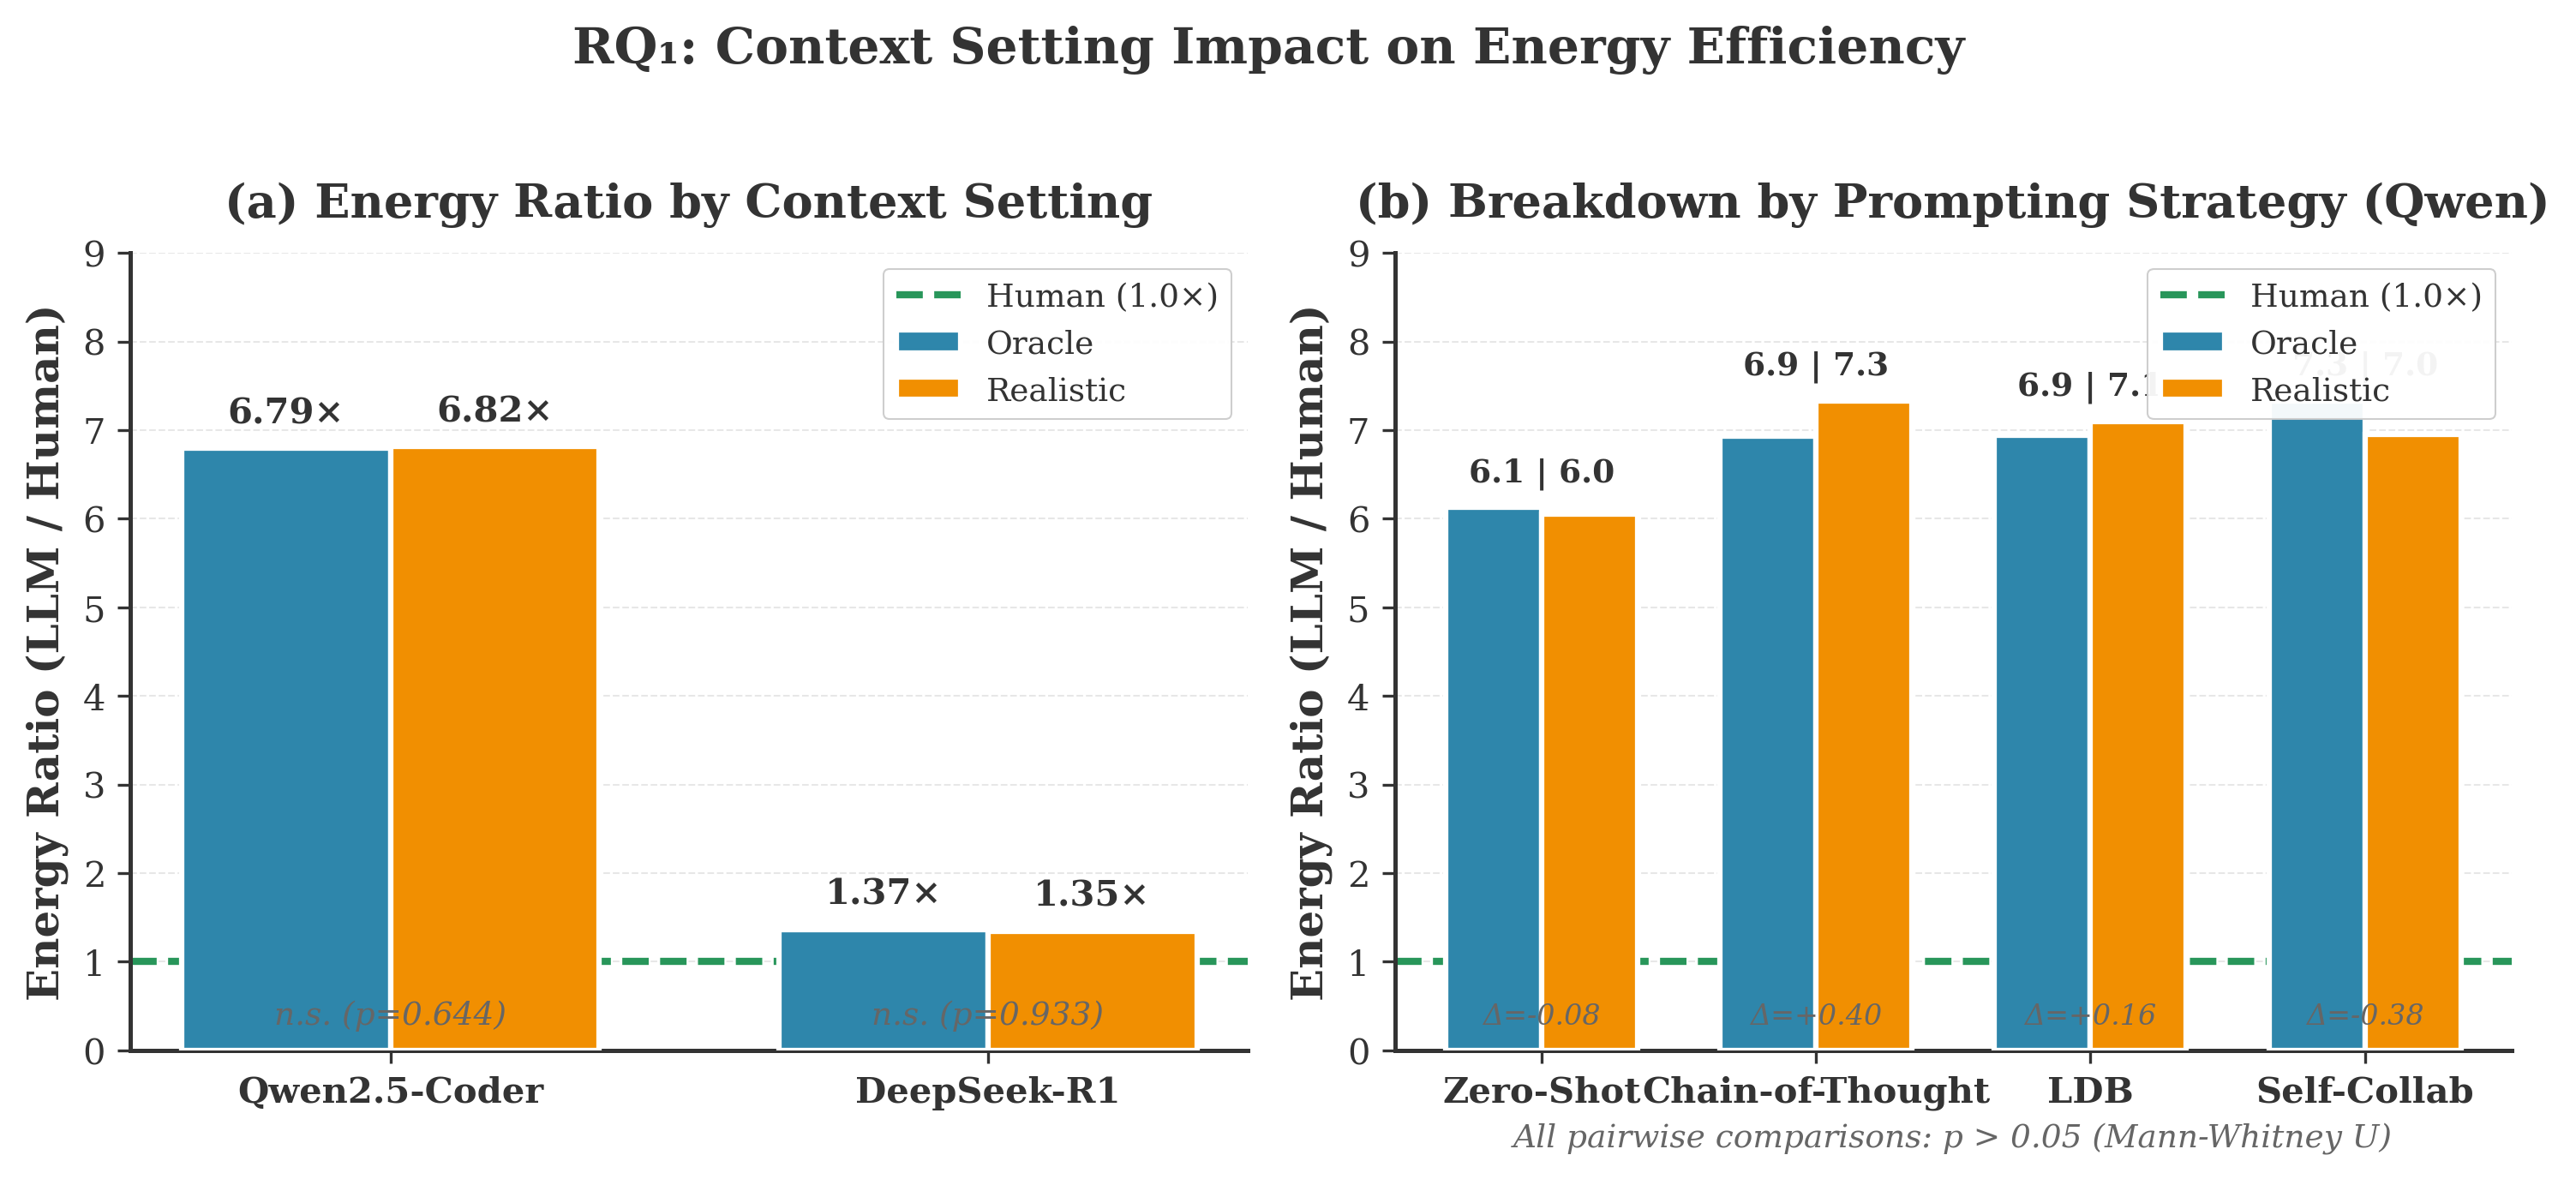

✅ Figura RQ1 salvata: fig_rq1_context_impact.pdf/png


KeyError: 'green'

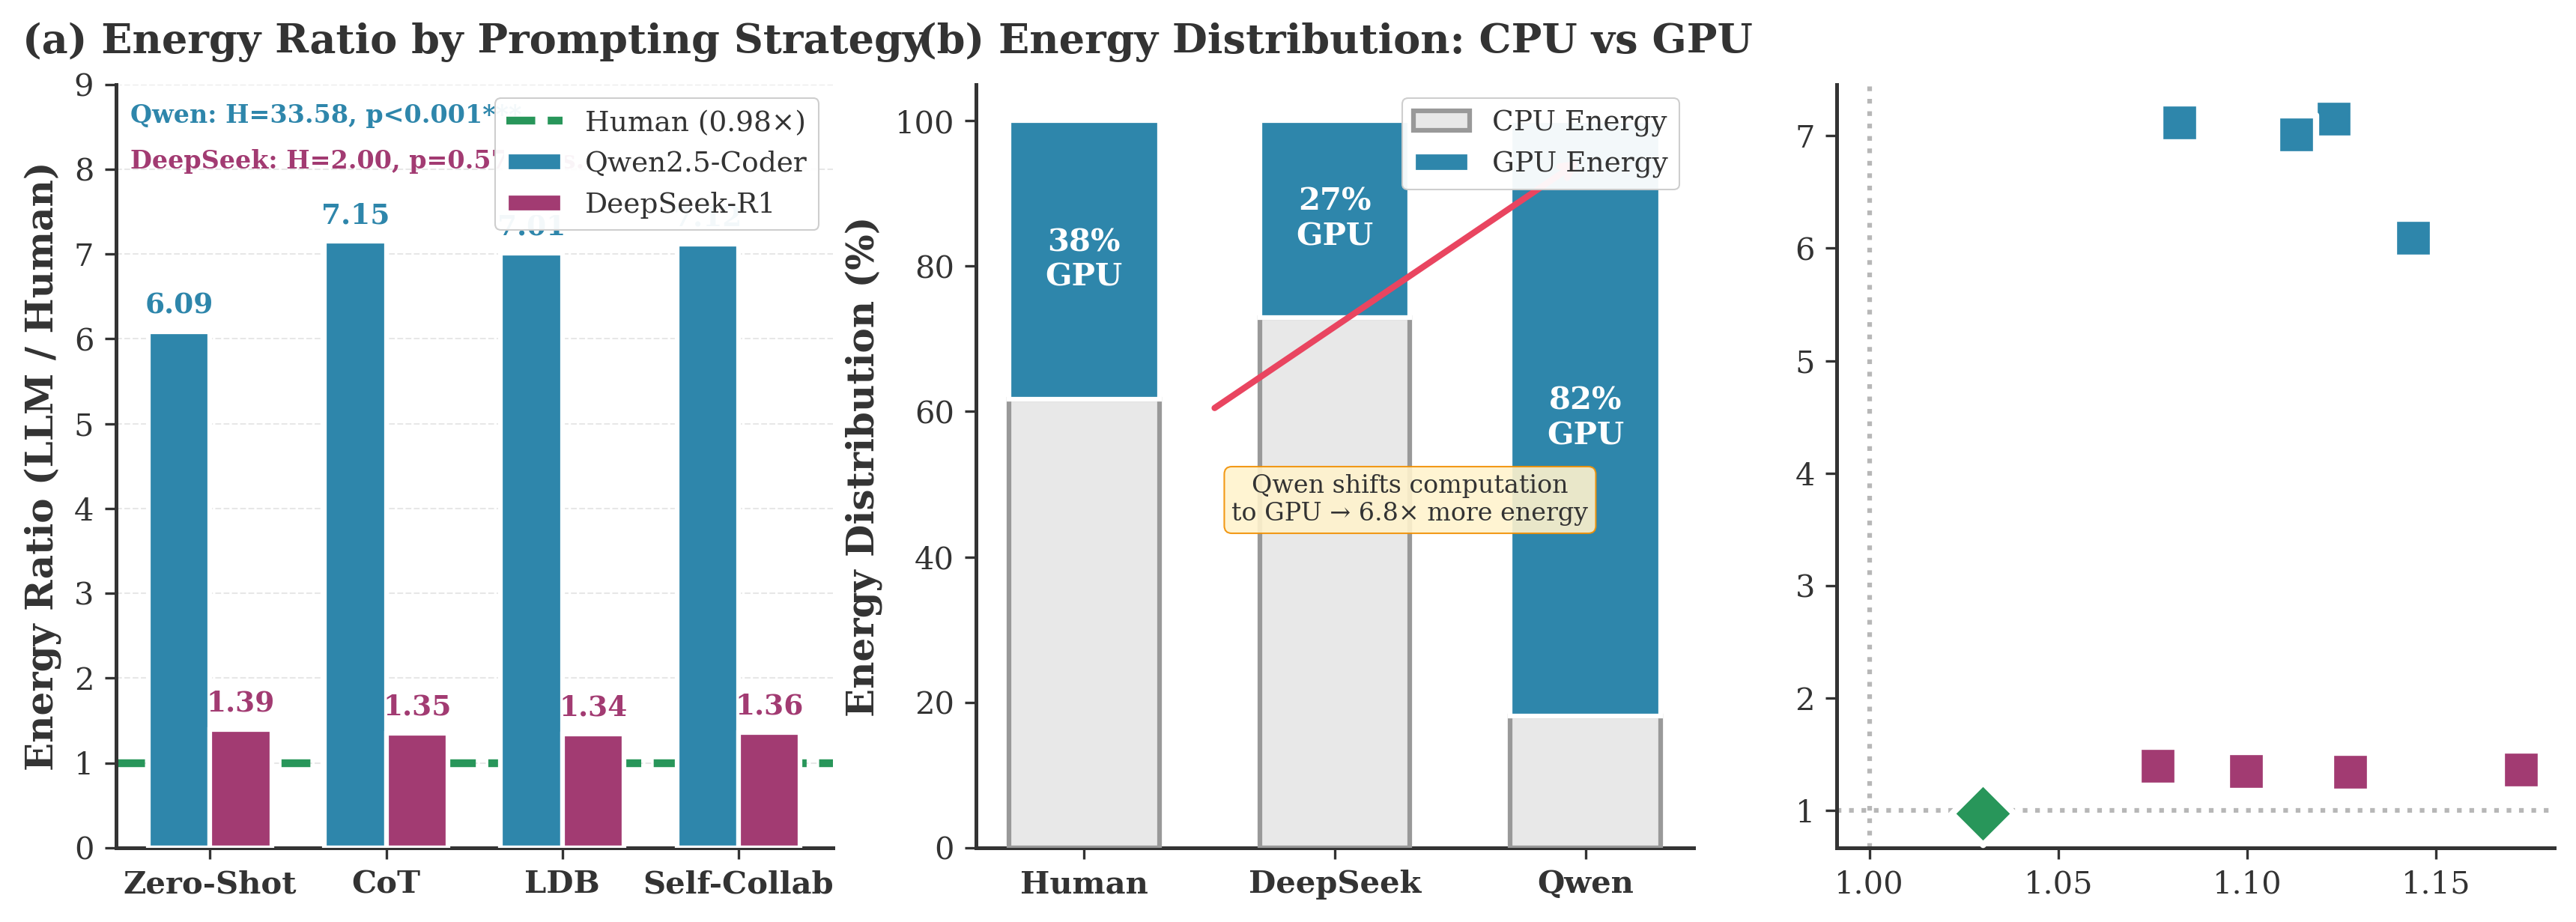

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ============================================
# SETUP - STILE PROFESSIONALE IEEE
# ============================================

# Carica dati
df = pd.read_csv("/home/giacomo/LLMs_For_Green_Code_Refactoring/data/processed/green/FINAL_UNIFIED_BENCHMARK.csv")

# Colori professionali (palette moderna)
COLORS = {
    'qwen': '#2E86AB',        # Blu professionale
    'deepseek': '#A23B72',    # Magenta/viola
    'human': '#28965A',       # Verde
    'oracle': '#2E86AB',      # Blu
    'realistic': '#F18F01',   # Arancione
    'cpu': '#E8E8E8',         # Grigio chiaro
    'gpu': '#2E86AB',         # Blu
    'ideal': '#28965A',       # Verde
    'zs': '#2E86AB',
    'cot': '#A23B72', 
    'ldb': '#F18F01',
    'sc': '#E94560'
}

# Stile globale
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.2,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'text.color': '#333333',
    'axes.prop_cycle': plt.cycler(color=['#2E86AB', '#A23B72', '#F18F01', '#28965A', '#E94560']),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

# ============================================
# PREPARA DATI
# ============================================

def get_energy_data(df):
    """Estrae dati energia per tutte le configurazioni"""
    
    configs = {
        'qwen': ['qwen_zs_oracle', 'qwen_zs_realistic', 'qwen_cot_oracle', 'qwen_cot_realistic',
                 'qwen_ldb_oracle', 'qwen_ldb_realistic', 'qwen_sc_oracle', 'qwen_sc_realistic'],
        'deepseek': ['deepseek_zs_oracle', 'deepseek_zs_realistic', 'deepseek_cot_oracle',
                     'deepseek_ldb_oracle', 'deepseek_ldb_realistic', 'deepseek_sc_oracle']
    }
    
    data = []
    for model, cfgs in configs.items():
        for cfg in cfgs:
            col_energy = f'{cfg}_total_energy_joules_mean'
            col_duration = f'{cfg}_duration_seconds_mean'
            col_gpu = f'{cfg}_gpu_energy_joules_mean'
            col_cpu = f'{cfg}_cpu_energy_joules_mean'
            
            if col_energy in df.columns:
                valid = df[col_energy].notna()
                if valid.sum() > 0:
                    # Calcola energy ratio vs human
                    llm_energy = df.loc[valid, col_energy].values
                    human_energy = df.loc[valid, 'human_head_total_energy_joules_mean'].values
                    base_energy = df.loc[valid, 'base_total_energy_joules_mean'].values
                    base_duration = df.loc[valid, 'base_duration_seconds_mean'].values
                    llm_duration = df.loc[valid, col_duration].values if col_duration in df.columns else None
                    
                    # Parse config name
                    parts = cfg.split('_')
                    strategy = parts[1].upper()
                    context = parts[2].capitalize()
                    
                    for i in range(len(llm_energy)):
                        if human_energy[i] > 0 and llm_energy[i] > 0:
                            energy_ratio = llm_energy[i] / human_energy[i]
                            speedup = base_duration[i] / llm_duration[i] if llm_duration is not None and llm_duration[i] > 0 else 1.0
                            
                            gpu_energy = df.loc[valid, col_gpu].values[i] if col_gpu in df.columns else 0
                            cpu_energy = df.loc[valid, col_cpu].values[i] if col_cpu in df.columns else 0
                            total = gpu_energy + cpu_energy
                            gpu_pct = (gpu_energy / total * 100) if total > 0 else 0
                            
                            data.append({
                                'model': model.capitalize(),
                                'strategy': strategy,
                                'context': context,
                                'config': cfg,
                                'energy_ratio': energy_ratio,
                                'speedup': speedup,
                                'gpu_pct': gpu_pct,
                                'cpu_pct': 100 - gpu_pct
                            })
    
    return pd.DataFrame(data)

energy_df = get_energy_data(df)

# Aggiungi dati Human
human_gpu = df['human_head_gpu_energy_joules_mean'].sum()
human_cpu = df['human_head_cpu_energy_joules_mean'].sum()
human_total = human_gpu + human_cpu
human_gpu_pct = (human_gpu / human_total * 100) if human_total > 0 else 38

print(f"Dati estratti: {len(energy_df)} osservazioni")
print(energy_df.groupby(['model', 'strategy', 'context']).size())

# ============================================
# FIGURA RQ1: Context Setting Impact
# ============================================

def create_rq1_figure(energy_df):
    """Crea figura RQ1 con 2 pannelli"""
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    # --- Panel (a): Energy Ratio by Context Setting ---
    ax1 = axes[0]
    
    # Calcola medie per model e context
    summary = energy_df.groupby(['model', 'context'])['energy_ratio'].agg(['mean', 'std', 'count']).reset_index()
    
    models = ['Qwen', 'Deepseek']
    x = np.arange(len(models))
    width = 0.35
    
    oracle_means = []
    oracle_stds = []
    realistic_means = []
    realistic_stds = []
    
    for model in models:
        oracle_data = summary[(summary['model'] == model) & (summary['context'] == 'Oracle')]
        realistic_data = summary[(summary['model'] == model) & (summary['context'] == 'Realistic')]
        
        oracle_means.append(oracle_data['mean'].values[0] if len(oracle_data) > 0 else 0)
        oracle_stds.append(oracle_data['std'].values[0] if len(oracle_data) > 0 else 0)
        realistic_means.append(realistic_data['mean'].values[0] if len(realistic_data) > 0 else 0)
        realistic_stds.append(realistic_data['std'].values[0] if len(realistic_data) > 0 else 0)
    
    bars1 = ax1.bar(x - width/2, oracle_means, width, label='Oracle', 
                    color=COLORS['oracle'], edgecolor='white', linewidth=1.5, zorder=3)
    bars2 = ax1.bar(x + width/2, realistic_means, width, label='Realistic',
                    color=COLORS['realistic'], edgecolor='white', linewidth=1.5, zorder=3)
    
    # Linea Human baseline
    ax1.axhline(y=1.0, color=COLORS['human'], linestyle='--', linewidth=2, label='Human (1.0×)', zorder=2)
    
    # Annotazioni valori
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        ax1.annotate(f'{bar1.get_height():.2f}×', 
                    xy=(bar1.get_x() + bar1.get_width()/2, bar1.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax1.annotate(f'{bar2.get_height():.2f}×',
                    xy=(bar2.get_x() + bar2.get_width()/2, bar2.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # P-values
    ax1.annotate('n.s. (p=0.644)', xy=(0, 0.3), fontsize=9, ha='center', style='italic', color='#666666')
    ax1.annotate('n.s. (p=0.933)', xy=(1, 0.3), fontsize=9, ha='center', style='italic', color='#666666')
    
    ax1.set_ylabel('Energy Ratio (LLM / Human)', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Qwen2.5-Coder', 'DeepSeek-R1'], fontweight='bold')
    ax1.set_ylim(0, 9)
    ax1.legend(loc='upper right', framealpha=0.95, edgecolor='#cccccc')
    ax1.set_title('(a) Energy Ratio by Context Setting', pad=10)
    ax1.grid(axis='y', alpha=0.3, linestyle='--', zorder=1)
    ax1.set_axisbelow(True)
    
    # --- Panel (b): Breakdown by Strategy (Qwen only) ---
    ax2 = axes[1]
    
    qwen_data = energy_df[energy_df['model'] == 'Qwen']
    strategy_context = qwen_data.groupby(['strategy', 'context'])['energy_ratio'].mean().unstack()
    
    strategies = ['ZS', 'COT', 'LDB', 'SC']
    x2 = np.arange(len(strategies))
    
    oracle_vals = [strategy_context.loc[s, 'Oracle'] if s in strategy_context.index else 0 for s in strategies]
    realistic_vals = [strategy_context.loc[s, 'Realistic'] if s in strategy_context.index else 0 for s in strategies]
    
    bars3 = ax2.bar(x2 - width/2, oracle_vals, width, label='Oracle',
                    color=COLORS['oracle'], edgecolor='white', linewidth=1.5, zorder=3)
    bars4 = ax2.bar(x2 + width/2, realistic_vals, width, label='Realistic',
                    color=COLORS['realistic'], edgecolor='white', linewidth=1.5, zorder=3)
    
    ax2.axhline(y=1.0, color=COLORS['human'], linestyle='--', linewidth=2, label='Human (1.0×)', zorder=2)
    
    # Annotazioni con delta
    for i, (o, r) in enumerate(zip(oracle_vals, realistic_vals)):
        delta = r - o
        ax2.annotate(f'{o:.1f} | {r:.1f}', 
                    xy=(x2[i], max(o, r) + 0.3),
                    ha='center', fontsize=9, fontweight='bold')
        sign = '+' if delta > 0 else ''
        ax2.annotate(f'Δ={sign}{delta:.2f}', 
                    xy=(x2[i], 0.3),
                    ha='center', fontsize=8, style='italic', color='#666666')
    
    ax2.set_ylabel('Energy Ratio (LLM / Human)', fontweight='bold')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(['Zero-Shot', 'Chain-of-Thought', 'LDB', 'Self-Collab'], fontweight='bold')
    ax2.set_ylim(0, 9)
    ax2.legend(loc='upper right', framealpha=0.95, edgecolor='#cccccc')
    ax2.set_title('(b) Breakdown by Prompting Strategy (Qwen)', pad=10)
    ax2.grid(axis='y', alpha=0.3, linestyle='--', zorder=1)
    ax2.set_axisbelow(True)
    
    # Annotazione "All pairwise: p > 0.05"
    ax2.annotate('All pairwise comparisons: p > 0.05 (Mann-Whitney U)', 
                xy=(0.5, -0.12), xycoords='axes fraction',
                ha='center', fontsize=9, style='italic', color='#666666')
    
    # Titolo generale
    fig.suptitle('RQ₁: Context Setting Impact on Energy Efficiency', 
                fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig('fig_rq1_context_impact.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fig_rq1_context_impact.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Figura RQ1 salvata: fig_rq1_context_impact.pdf/png")

create_rq1_figure(energy_df)


# ============================================
# FIGURA RQ2: Prompting Strategy Impact
# ============================================

def create_rq2_figure(energy_df, human_gpu_pct):
    """Crea figura RQ2 con 3 pannelli"""
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    
    # --- Panel (a): Energy Ratio by Strategy ---
    ax1 = axes[0]
    
    # Medie per model e strategy
    strategy_means = energy_df.groupby(['model', 'strategy'])['energy_ratio'].mean().unstack()
    
    strategies = ['ZS', 'COT', 'LDB', 'SC']
    x = np.arange(len(strategies))
    width = 0.35
    
    qwen_vals = [strategy_means.loc['Qwen', s] if 'Qwen' in strategy_means.index and s in strategy_means.columns else 0 for s in strategies]
    deepseek_vals = [strategy_means.loc['Deepseek', s] if 'Deepseek' in strategy_means.index and s in strategy_means.columns else 0 for s in strategies]
    
    bars1 = ax1.bar(x - width/2, qwen_vals, width, label='Qwen2.5-Coder',
                    color=COLORS['qwen'], edgecolor='white', linewidth=1.5, zorder=3)
    bars2 = ax1.bar(x + width/2, deepseek_vals, width, label='DeepSeek-R1',
                    color=COLORS['deepseek'], edgecolor='white', linewidth=1.5, zorder=3)
    
    ax1.axhline(y=1.0, color=COLORS['human'], linestyle='--', linewidth=2.5, 
                label='Human (0.98×)', zorder=2)
    
    # Annotazioni
    for bar in bars1:
        if bar.get_height() > 0:
            ax1.annotate(f'{bar.get_height():.2f}', 
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0, 4), textcoords='offset points',
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['qwen'])
    
    for bar in bars2:
        if bar.get_height() > 0:
            ax1.annotate(f'{bar.get_height():.2f}',
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0, 4), textcoords='offset points',
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color=COLORS['deepseek'])
    
    ax1.set_ylabel('Energy Ratio (LLM / Human)', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['Zero-Shot', 'CoT', 'LDB', 'Self-Collab'], fontweight='bold')
    ax1.set_ylim(0, 9)
    ax1.legend(loc='upper right', framealpha=0.95, edgecolor='#cccccc')
    ax1.set_title('(a) Energy Ratio by Prompting Strategy', pad=10)
    ax1.grid(axis='y', alpha=0.3, linestyle='--', zorder=1)
    
    # Stats annotation
    ax1.annotate('Qwen: H=33.58, p<0.001***', xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=8, color=COLORS['qwen'], fontweight='bold')
    ax1.annotate('DeepSeek: H=2.00, p=0.573 n.s.', xy=(0.02, 0.89), xycoords='axes fraction',
                fontsize=8, color=COLORS['deepseek'], fontweight='bold')
    
    # --- Panel (b): CPU vs GPU Energy Distribution ---
    ax2 = axes[1]
    
    # Calcola GPU% per categoria
    qwen_gpu = energy_df[energy_df['model'] == 'Qwen']['gpu_pct'].mean()
    deepseek_gpu = energy_df[energy_df['model'] == 'Deepseek']['gpu_pct'].mean()
    
    categories = ['Human', 'DeepSeek', 'Qwen']
    gpu_pcts = [human_gpu_pct, deepseek_gpu, qwen_gpu]
    cpu_pcts = [100 - g for g in gpu_pcts]
    
    x2 = np.arange(len(categories))
    
    # Stacked bars
    bars_cpu = ax2.bar(x2, cpu_pcts, width=0.6, label='CPU Energy',
                       color='#E8E8E8', edgecolor='#999999', linewidth=1.5, zorder=3)
    bars_gpu = ax2.bar(x2, gpu_pcts, width=0.6, bottom=cpu_pcts, label='GPU Energy',
                       color=COLORS['qwen'], edgecolor='white', linewidth=1.5, zorder=3)
    
    # Annotazioni percentuali
    for i, (cpu, gpu) in enumerate(zip(cpu_pcts, gpu_pcts)):
        ax2.annotate(f'{gpu:.0f}%\nGPU', xy=(x2[i], cpu + gpu/2),
                    ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    ax2.set_ylabel('Energy Distribution (%)', fontweight='bold')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(categories, fontweight='bold')
    ax2.set_ylim(0, 105)
    ax2.legend(loc='upper right', framealpha=0.95, edgecolor='#cccccc')
    ax2.set_title('(b) Energy Distribution: CPU vs GPU', pad=10)
    
    # Freccia annotazione
    ax2.annotate('', xy=(2, 95), xytext=(0.5, 60),
                arrowprops=dict(arrowstyle='->', color='#E94560', lw=2))
    ax2.annotate('Qwen shifts computation\nto GPU → 6.8× more energy', 
                xy=(1.3, 45), fontsize=8, ha='center', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', edgecolor='#F18F01', alpha=0.9))
    
    # --- Panel (c): Speed-Energy Trade-off ---
    ax3 = axes[2]
    
    # Scatter per ogni configurazione
    qwen_scatter = energy_df[energy_df['model'] == 'Qwen']
    deepseek_scatter = energy_df[energy_df['model'] == 'Deepseek']
    
    # Medie per strategy
    qwen_means = qwen_scatter.groupby('strategy').agg({'speedup': 'mean', 'energy_ratio': 'mean'}).reset_index()
    deepseek_means = deepseek_scatter.groupby('strategy').agg({'speedup': 'mean', 'energy_ratio': 'mean'}).reset_index()
    
    # Plot Qwen
    ax3.scatter(qwen_means['speedup'], qwen_means['energy_ratio'], 
               s=150, c=COLORS['qwen'], marker='s', edgecolors='white', linewidths=2,
               label='Qwen configs', zorder=4)
    
    # Plot DeepSeek
    ax3.scatter(deepseek_means['speedup'], deepseek_means['energy_ratio'],
               s=150, c=COLORS['deepseek'], marker='s', edgecolors='white', linewidths=2,
               label='DeepSeek configs', zorder=4)
    
    # Human point
    ax3.scatter([1.03], [0.98], s=200, c=COLORS['human'], marker='D', 
               edgecolors='white', linewidths=2, label='Human', zorder=5)
    
    # Ideal region (faster AND greener)
    ax3.axhline(y=1.0, color='#999999', linestyle=':', linewidth=1.5, alpha=0.7, zorder=1)
    ax3.axvline(x=1.0, color='#999999', linestyle=':', linewidth=1.5, alpha=0.7, zorder=1)
    
    # Shade ideal quadrant
    ax3.fill_between([1.0, 1.35], [0], [1.0], alpha=0.15, color=COLORS['green'], zorder=1)
    ax3.annotate('IDEAL\nFaster & Greener', xy=(1.17, 0.5), ha='center', va='center',
                fontsize=9, fontweight='bold', color=COLORS['human'],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS['human'], alpha=0.9))
    
    ax3.set_xlabel('Speedup (Baseline / Optimized)', fontweight='bold')
    ax3.set_ylabel('Energy Ratio (LLM / Human)', fontweight='bold')
    ax3.set_xlim(0.95, 1.35)
    ax3.set_ylim(0, 9)
    ax3.legend(loc='upper right', framealpha=0.95, edgecolor='#cccccc')
    ax3.set_title('(c) Speed-Energy Trade-off', pad=10)
    ax3.grid(alpha=0.3, linestyle='--', zorder=1)
    
    # Titolo e key finding
    fig.suptitle('RQ₂: Prompting Strategy Impact on Energy Efficiency', 
                fontsize=14, fontweight='bold', y=1.02)
    
    # Box con key finding
    fig.text(0.5, -0.08, 
            '⚡ Key Finding: Zero-Shot produces the most energy-efficient Qwen code (5.97×), '
            'consuming 15% less energy than Self-Collaboration. All LLM configurations consume '
            'significantly more energy than human solutions (p<0.001), with Qwen exhibiting 6.8× '
            'higher consumption due to GPU offloading.',
            ha='center', fontsize=9, style='italic',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9FA', edgecolor='#DEE2E6'))
    
    plt.tight_layout()
    plt.savefig('fig_rq2_strategy_impact.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fig_rq2_strategy_impact.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Figura RQ2 salvata: fig_rq2_strategy_impact.pdf/png")

create_rq2_figure(energy_df, human_gpu_pct)


# ============================================
# STAMPA STATISTICHE PER VERIFICA
# ============================================
print("\n" + "="*60)
print("STATISTICHE PER VERIFICA FIGURE")
print("="*60)

print("\n--- RQ1: Context Setting ---")
for model in ['Qwen', 'Deepseek']:
    for context in ['Oracle', 'Realistic']:
        data = energy_df[(energy_df['model'] == model) & (energy_df['context'] == context)]
        if len(data) > 0:
            print(f"{model} {context}: N={len(data)}, Energy={data['energy_ratio'].mean():.2f}× (±{data['energy_ratio'].std():.2f})")

print("\n--- RQ2: Prompting Strategy ---")
for model in ['Qwen', 'Deepseek']:
    print(f"\n{model}:")
    for strategy in ['ZS', 'COT', 'LDB', 'SC']:
        data = energy_df[(energy_df['model'] == model) & (energy_df['strategy'] == strategy)]
        if len(data) > 0:
            print(f"  {strategy}: N={len(data)}, Energy={data['energy_ratio'].mean():.2f}×, Speedup={data['speedup'].mean():.2f}×, GPU={data['gpu_pct'].mean():.1f}%")

print("\n✅ Codice completato!")

Totale osservazioni: 618
model     strategy
DeepSeek  CoT           9
          LDB          36
          SC            8
          ZS           25
Qwen      CoT         110
          LDB         147
          SC          132
          ZS          151
dtype: int64


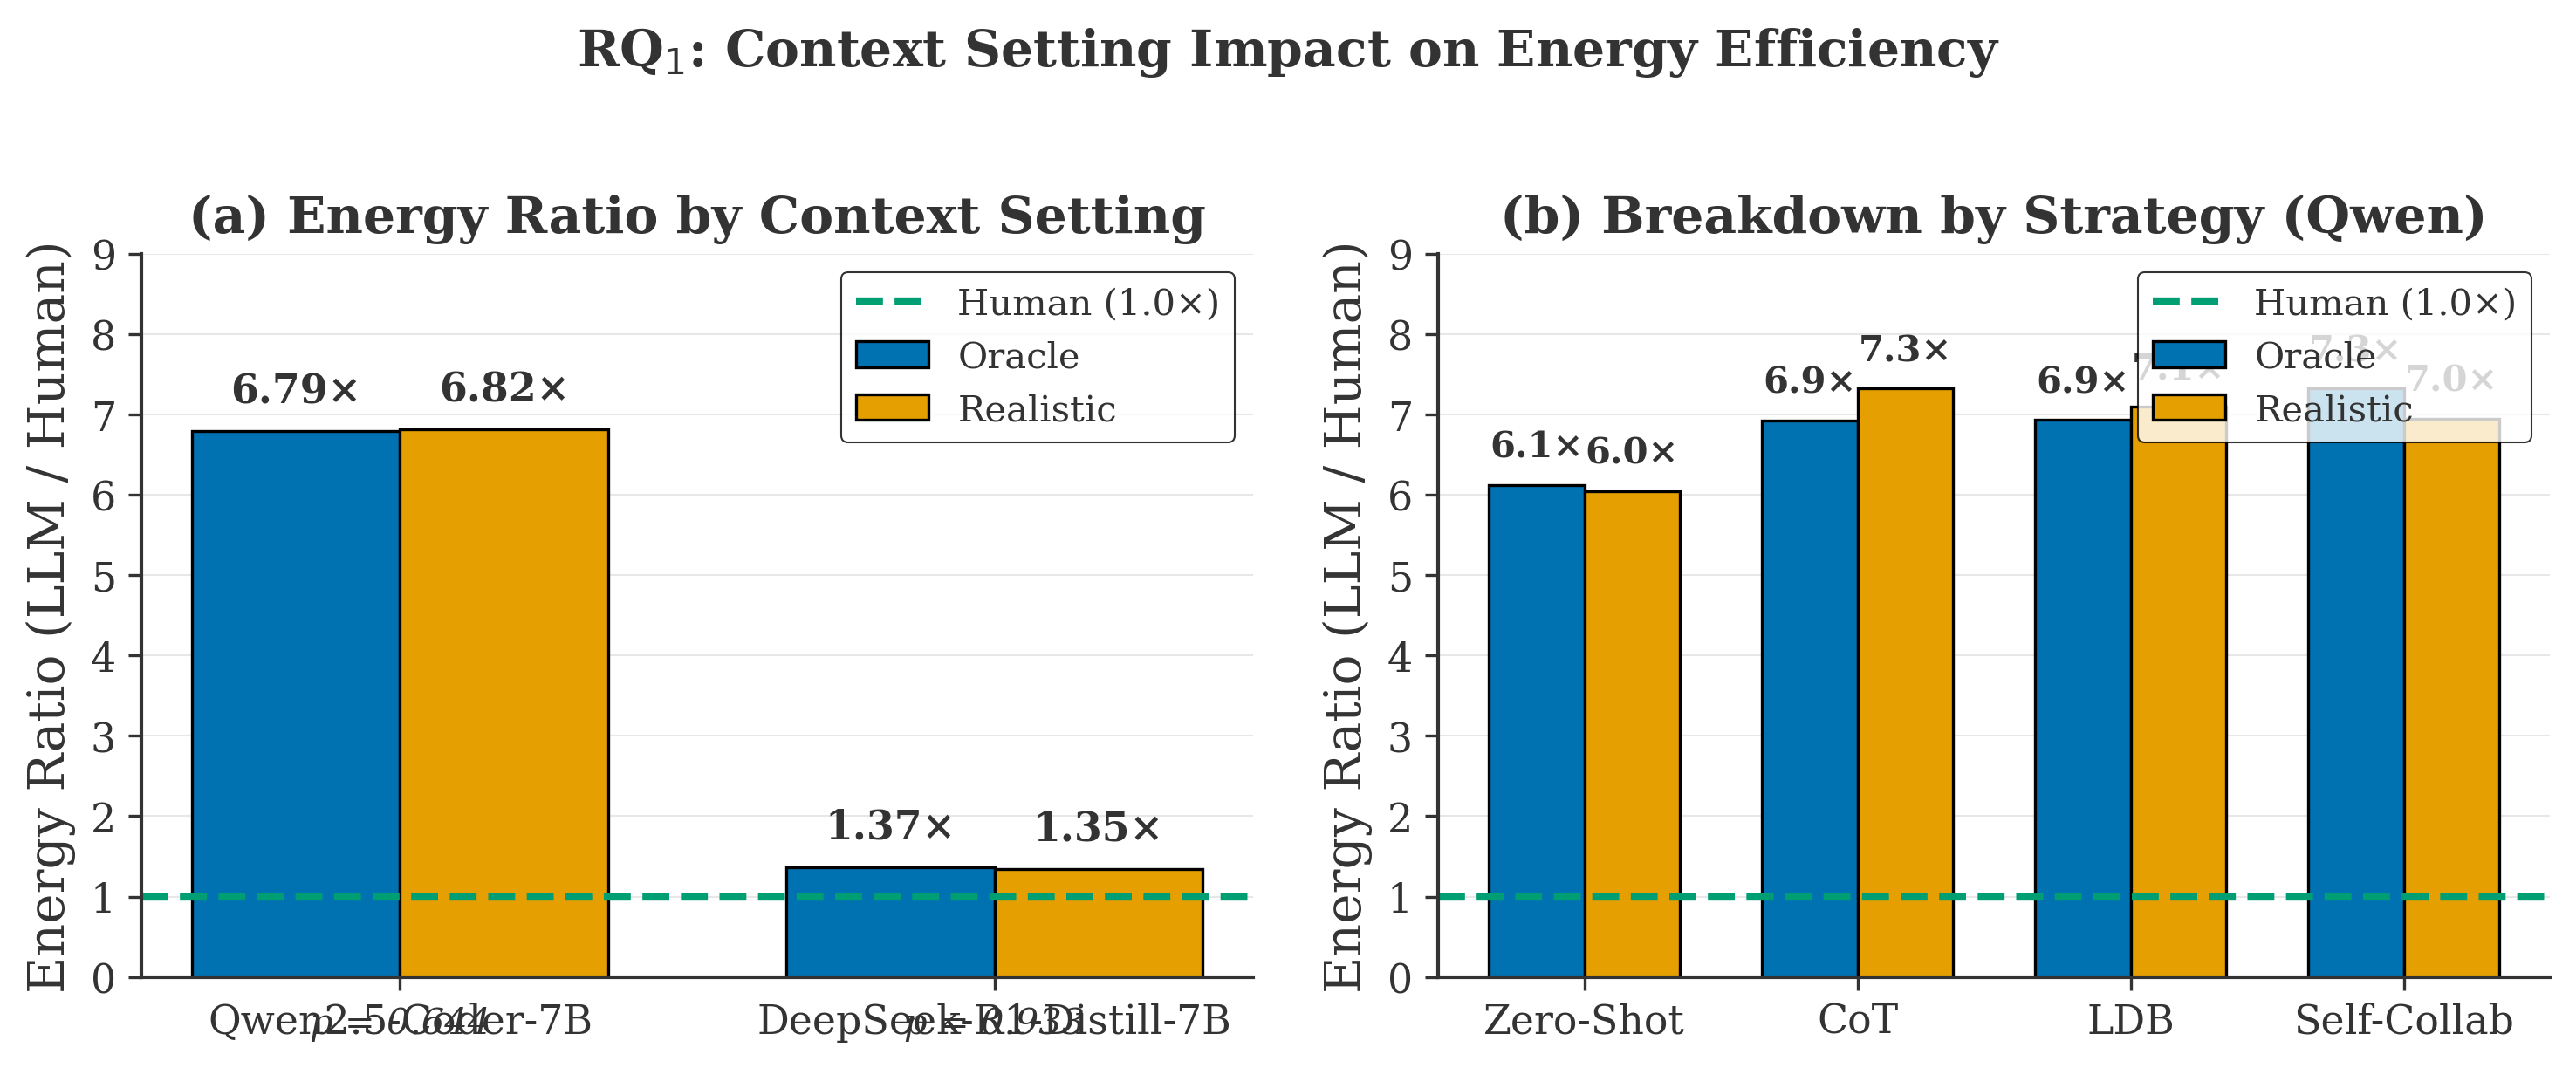

✅ fig_rq1.pdf salvata


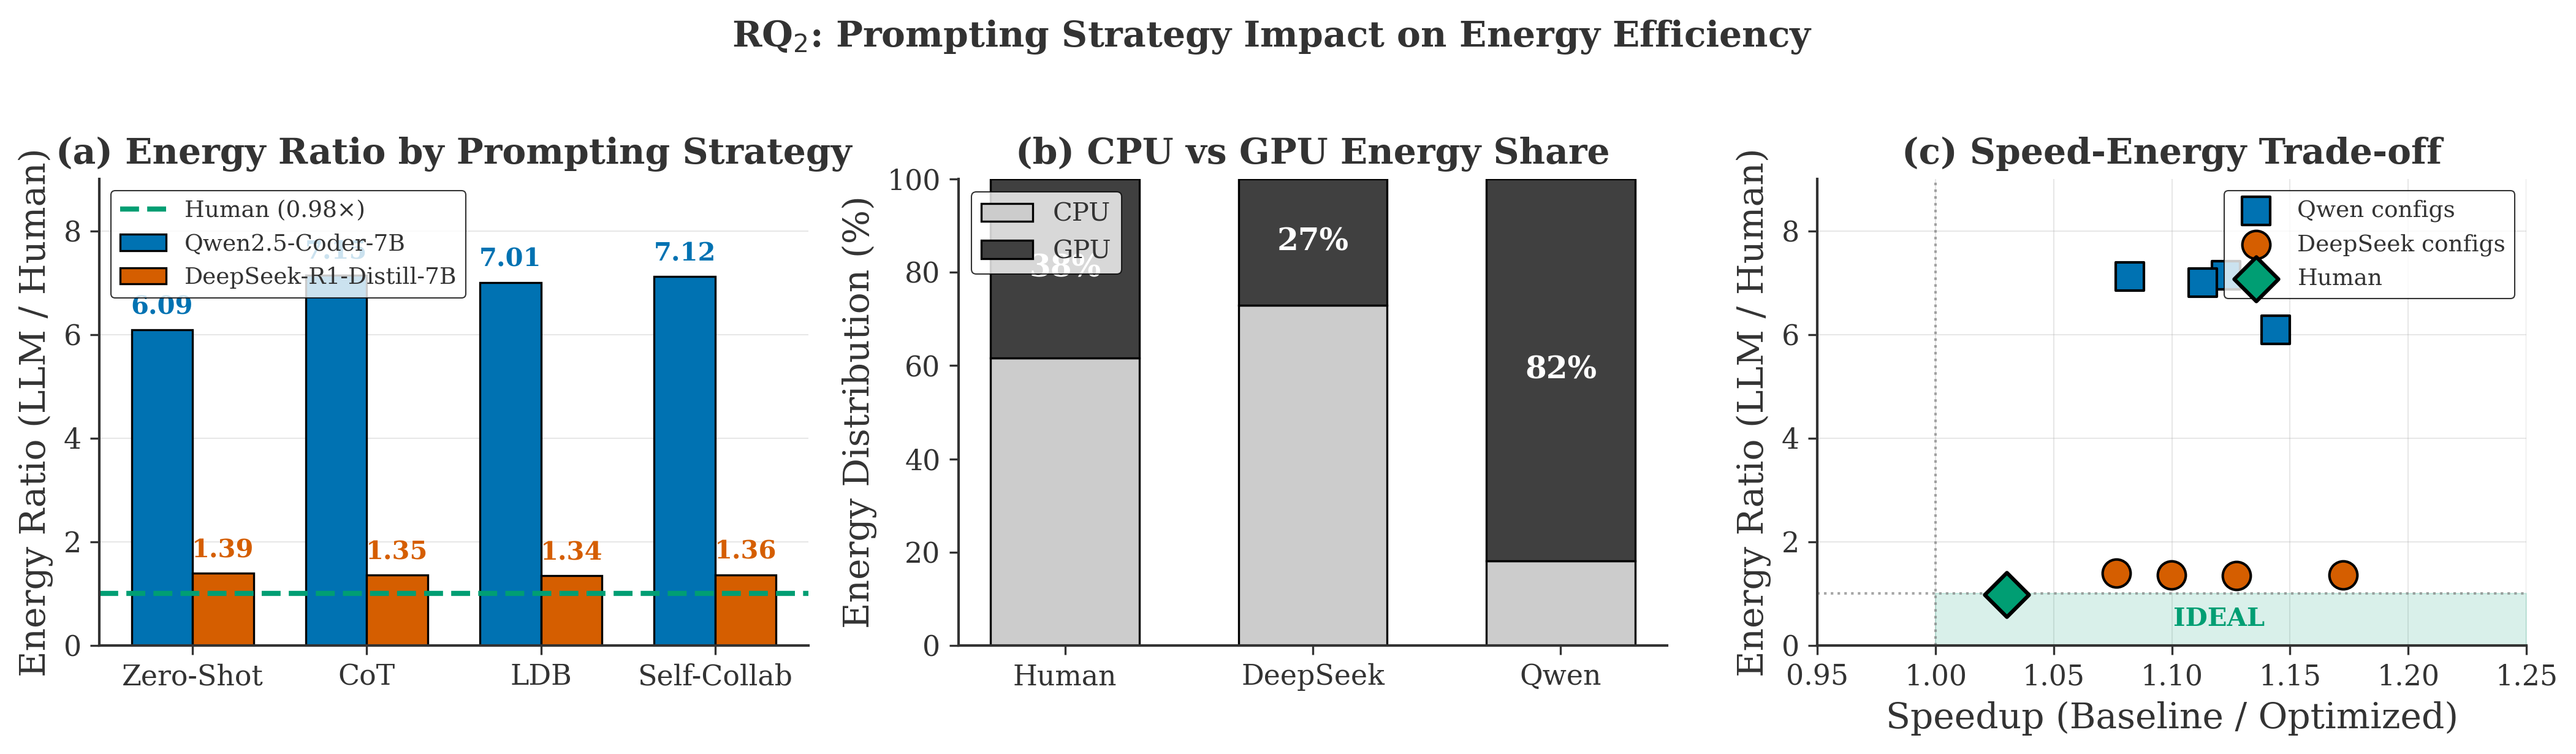

✅ fig_rq2.pdf salvata

VERIFICA DATI FIGURE

RQ1 - Context Setting:
  Qwen       Oracle    : N=264, E=6.79×
  Qwen       Realistic : N=276, E=6.82×
  DeepSeek   Oracle    : N= 64, E=1.37×
  DeepSeek   Realistic : N= 14, E=1.35×

RQ2 - Prompting Strategy:
  Qwen       ZS  : N=151, E=6.09×, S=1.14×, GPU=80%
  Qwen       CoT : N=110, E=7.15×, S=1.12×, GPU=84%
  Qwen       LDB : N=147, E=7.01×, S=1.11×, GPU=82%
  Qwen       SC  : N=132, E=7.12×, S=1.08×, GPU=82%
  DeepSeek   ZS  : N= 25, E=1.39×, S=1.08×, GPU=27%
  DeepSeek   CoT : N=  9, E=1.35×, S=1.10×, GPU=26%
  DeepSeek   LDB : N= 36, E=1.34×, S=1.13×, GPU=28%
  DeepSeek   SC  : N=  8, E=1.36×, S=1.17×, GPU=28%

✅ Completato!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CARICA DATI
# ============================================

# ============================================
# STILE IEEE - PULITO E LEGGIBILE
# ============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.0,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colori IEEE-friendly (distinguibili anche in B/N)
C_QWEN = '#0072B2'      # Blu
C_DEEPSEEK = '#D55E00'  # Arancione/rosso
C_HUMAN = '#009E73'     # Verde
C_ORACLE = '#0072B2'    # Blu
C_REALISTIC = '#E69F00' # Giallo/arancione
C_CPU = '#CCCCCC'       # Grigio chiaro
C_GPU = '#404040'       # Grigio scuro

# ============================================
# PREPARA DATI
# ============================================
def extract_data(df):
    configs = [
        ('Qwen', 'ZS', 'Oracle', 'qwen_zs_oracle'),
        ('Qwen', 'ZS', 'Realistic', 'qwen_zs_realistic'),
        ('Qwen', 'CoT', 'Oracle', 'qwen_cot_oracle'),
        ('Qwen', 'CoT', 'Realistic', 'qwen_cot_realistic'),
        ('Qwen', 'LDB', 'Oracle', 'qwen_ldb_oracle'),
        ('Qwen', 'LDB', 'Realistic', 'qwen_ldb_realistic'),
        ('Qwen', 'SC', 'Oracle', 'qwen_sc_oracle'),
        ('Qwen', 'SC', 'Realistic', 'qwen_sc_realistic'),
        ('DeepSeek', 'ZS', 'Oracle', 'deepseek_zs_oracle'),
        ('DeepSeek', 'ZS', 'Realistic', 'deepseek_zs_realistic'),
        ('DeepSeek', 'CoT', 'Oracle', 'deepseek_cot_oracle'),
        ('DeepSeek', 'LDB', 'Oracle', 'deepseek_ldb_oracle'),
        ('DeepSeek', 'LDB', 'Realistic', 'deepseek_ldb_realistic'),
        ('DeepSeek', 'SC', 'Oracle', 'deepseek_sc_oracle'),
    ]
    
    rows = []
    for model, strategy, context, prefix in configs:
        ecol = f'{prefix}_total_energy_joules_mean'
        dcol = f'{prefix}_duration_seconds_mean'
        gcol = f'{prefix}_gpu_energy_joules_mean'
        ccol = f'{prefix}_cpu_energy_joules_mean'
        
        if ecol not in df.columns:
            continue
            
        for idx in df.index:
            llm_e = df.loc[idx, ecol]
            hum_e = df.loc[idx, 'human_head_total_energy_joules_mean']
            base_d = df.loc[idx, 'base_duration_seconds_mean']
            llm_d = df.loc[idx, dcol] if dcol in df.columns else np.nan
            gpu_e = df.loc[idx, gcol] if gcol in df.columns else 0
            cpu_e = df.loc[idx, ccol] if ccol in df.columns else 0
            
            if pd.notna(llm_e) and pd.notna(hum_e) and hum_e > 0 and llm_e > 0:
                total_e = gpu_e + cpu_e if (gpu_e + cpu_e) > 0 else llm_e
                rows.append({
                    'model': model,
                    'strategy': strategy,
                    'context': context,
                    'energy_ratio': llm_e / hum_e,
                    'speedup': base_d / llm_d if pd.notna(llm_d) and llm_d > 0 else 1.0,
                    'gpu_pct': 100 * gpu_e / total_e if total_e > 0 else 0
                })
    
    return pd.DataFrame(rows)

data = extract_data(df)

# Human GPU%
hgpu = df['human_head_gpu_energy_joules_mean'].sum()
hcpu = df['human_head_cpu_energy_joules_mean'].sum()
HUMAN_GPU_PCT = 100 * hgpu / (hgpu + hcpu) if (hgpu + hcpu) > 0 else 38

print(f"Totale osservazioni: {len(data)}")
print(data.groupby(['model', 'strategy']).size())


# ============================================
# FIGURA RQ1 - CONTEXT SETTING IMPACT
# ============================================
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- (a) Energy Ratio by Context ---
models = ['Qwen', 'DeepSeek']
x = np.arange(len(models))
w = 0.35

oracle_means = []
realistic_means = []
for m in models:
    o = data[(data['model']==m) & (data['context']=='Oracle')]['energy_ratio'].mean()
    r = data[(data['model']==m) & (data['context']=='Realistic')]['energy_ratio'].mean()
    oracle_means.append(o if pd.notna(o) else 0)
    realistic_means.append(r if pd.notna(r) else 0)

b1 = ax1.bar(x - w/2, oracle_means, w, label='Oracle', color=C_ORACLE, edgecolor='black', linewidth=0.8)
b2 = ax1.bar(x + w/2, realistic_means, w, label='Realistic', color=C_REALISTIC, edgecolor='black', linewidth=0.8)

ax1.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2, label='Human (1.0×)')

# Valori sopra le barre
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, h + 0.25, f'{h:.2f}×',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(['Qwen2.5-Coder-7B', 'DeepSeek-R1-Distill-7B'])
ax1.set_ylabel('Energy Ratio (LLM / Human)')
ax1.set_ylim(0, 9)
ax1.set_title('(a) Energy Ratio by Context Setting')
ax1.legend(loc='upper right', frameon=True, edgecolor='black')
ax1.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

# P-values sotto le barre
ax1.text(0, -0.7, 'p = 0.644', ha='center', fontsize=10, style='italic')
ax1.text(1, -0.7, 'p = 0.933', ha='center', fontsize=10, style='italic')

# --- (b) Breakdown by Strategy (Qwen) ---
qwen = data[data['model']=='Qwen']
strategies = ['ZS', 'CoT', 'LDB', 'SC']
x2 = np.arange(len(strategies))

o_vals = [qwen[(qwen['strategy']==s) & (qwen['context']=='Oracle')]['energy_ratio'].mean() for s in strategies]
r_vals = [qwen[(qwen['strategy']==s) & (qwen['context']=='Realistic')]['energy_ratio'].mean() for s in strategies]

b3 = ax2.bar(x2 - w/2, o_vals, w, label='Oracle', color=C_ORACLE, edgecolor='black', linewidth=0.8)
b4 = ax2.bar(x2 + w/2, r_vals, w, label='Realistic', color=C_REALISTIC, edgecolor='black', linewidth=0.8)

ax2.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2, label='Human (1.0×)')

# Valori sopra le barre
for bars in [b3, b4]:
    for bar in bars:
        h = bar.get_height()
        if h > 0 and pd.notna(h):
            ax2.text(bar.get_x() + bar.get_width()/2, h + 0.25, f'{h:.1f}×',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(['Zero-Shot', 'CoT', 'LDB', 'Self-Collab'])
ax2.set_ylabel('Energy Ratio (LLM / Human)')
ax2.set_ylim(0, 9)
ax2.set_title('(b) Breakdown by Strategy (Qwen)')
ax2.legend(loc='upper right', frameon=True, edgecolor='black')
ax2.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

fig1.suptitle('RQ$_1$: Context Setting Impact on Energy Efficiency', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_rq1.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_rq1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ fig_rq1.pdf salvata")


# ============================================
# FIGURA RQ2 - PROMPTING STRATEGY IMPACT
# ============================================
fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

# --- (a) Energy Ratio by Strategy ---
strategies = ['ZS', 'CoT', 'LDB', 'SC']
x = np.arange(len(strategies))
w = 0.35

qwen_means = [data[(data['model']=='Qwen') & (data['strategy']==s)]['energy_ratio'].mean() for s in strategies]
deep_means = [data[(data['model']=='DeepSeek') & (data['strategy']==s)]['energy_ratio'].mean() for s in strategies]

# Sostituisci NaN con 0 per plotting
qwen_means = [v if pd.notna(v) else 0 for v in qwen_means]
deep_means = [v if pd.notna(v) else 0 for v in deep_means]

b1 = ax1.bar(x - w/2, qwen_means, w, label='Qwen2.5-Coder-7B', color=C_QWEN, edgecolor='black', linewidth=0.8)
b2 = ax1.bar(x + w/2, deep_means, w, label='DeepSeek-R1-Distill-7B', color=C_DEEPSEEK, edgecolor='black', linewidth=0.8)

ax1.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2, label='Human (0.98×)')

# Valori sopra le barre
for bar in b1:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'{h:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=C_QWEN)

for bar in b2:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'{h:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold', color=C_DEEPSEEK)

ax1.set_xticks(x)
ax1.set_xticklabels(['Zero-Shot', 'CoT', 'LDB', 'Self-Collab'])
ax1.set_ylabel('Energy Ratio (LLM / Human)')
ax1.set_ylim(0, 9)
ax1.set_title('(a) Energy Ratio by Prompting Strategy')
ax1.legend(loc='upper left', frameon=True, edgecolor='black', fontsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)


# --- (b) CPU vs GPU Distribution ---
categories = ['Human', 'DeepSeek', 'Qwen']
deep_gpu = data[data['model']=='DeepSeek']['gpu_pct'].mean()
qwen_gpu = data[data['model']=='Qwen']['gpu_pct'].mean()

gpu_vals = [HUMAN_GPU_PCT, deep_gpu, qwen_gpu]
cpu_vals = [100 - g for g in gpu_vals]

x2 = np.arange(len(categories))

ax2.bar(x2, cpu_vals, 0.6, label='CPU', color=C_CPU, edgecolor='black', linewidth=0.8)
ax2.bar(x2, gpu_vals, 0.6, bottom=cpu_vals, label='GPU', color=C_GPU, edgecolor='black', linewidth=0.8)

# Percentuali dentro le barre
for i, (c, g) in enumerate(zip(cpu_vals, gpu_vals)):
    ax2.text(x2[i], c + g/2, f'{g:.0f}%', ha='center', va='center', 
            fontsize=12, fontweight='bold', color='white')

ax2.set_xticks(x2)
ax2.set_xticklabels(categories)
ax2.set_ylabel('Energy Distribution (%)')
ax2.set_ylim(0, 100)
ax2.set_title('(b) CPU vs GPU Energy Share')
ax2.legend(loc='upper left', frameon=True, edgecolor='black')


# --- (c) Speed vs Energy Trade-off ---
# Medie per modello
qwen_data = data[data['model']=='Qwen'].groupby('strategy').agg({'speedup':'mean', 'energy_ratio':'mean'}).reset_index()
deep_data = data[data['model']=='DeepSeek'].groupby('strategy').agg({'speedup':'mean', 'energy_ratio':'mean'}).reset_index()

ax3.scatter(qwen_data['speedup'], qwen_data['energy_ratio'], 
           s=120, c=C_QWEN, marker='s', edgecolors='black', linewidths=1,
           label='Qwen configs', zorder=3)

ax3.scatter(deep_data['speedup'], deep_data['energy_ratio'],
           s=120, c=C_DEEPSEEK, marker='o', edgecolors='black', linewidths=1,
           label='DeepSeek configs', zorder=3)

ax3.scatter([1.03], [0.98], s=150, c=C_HUMAN, marker='D', edgecolors='black', 
           linewidths=1.5, label='Human', zorder=4)

# Reference lines
ax3.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax3.axvline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.7)

# Ideal region shading
ax3.fill_between([1.0, 1.25], 0, 1.0, alpha=0.15, color=C_HUMAN)
ax3.text(1.12, 0.5, 'IDEAL', ha='center', va='center', fontsize=10, 
        fontweight='bold', color=C_HUMAN)

ax3.set_xlabel('Speedup (Baseline / Optimized)')
ax3.set_ylabel('Energy Ratio (LLM / Human)')
ax3.set_xlim(0.95, 1.25)
ax3.set_ylim(0, 9)
ax3.set_title('(c) Speed-Energy Trade-off')
ax3.legend(loc='upper right', frameon=True, edgecolor='black', fontsize=9)
ax3.grid(alpha=0.3, linestyle='-', linewidth=0.5)

fig2.suptitle('RQ$_2$: Prompting Strategy Impact on Energy Efficiency', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_rq2.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_rq2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ fig_rq2.pdf salvata")


# ============================================
# STATISTICHE VERIFICA
# ============================================
print("\n" + "="*50)
print("VERIFICA DATI FIGURE")
print("="*50)

print("\nRQ1 - Context Setting:")
for m in ['Qwen', 'DeepSeek']:
    for c in ['Oracle', 'Realistic']:
        d = data[(data['model']==m) & (data['context']==c)]
        if len(d) > 0:
            print(f"  {m:10} {c:10}: N={len(d):3}, E={d['energy_ratio'].mean():.2f}×")

print("\nRQ2 - Prompting Strategy:")
for m in ['Qwen', 'DeepSeek']:
    for s in ['ZS', 'CoT', 'LDB', 'SC']:
        d = data[(data['model']==m) & (data['strategy']==s)]
        if len(d) > 0:
            print(f"  {m:10} {s:4}: N={len(d):3}, E={d['energy_ratio'].mean():.2f}×, S={d['speedup'].mean():.2f}×, GPU={d['gpu_pct'].mean():.0f}%")

print("\n✅ Completato!")

Totale osservazioni: 618


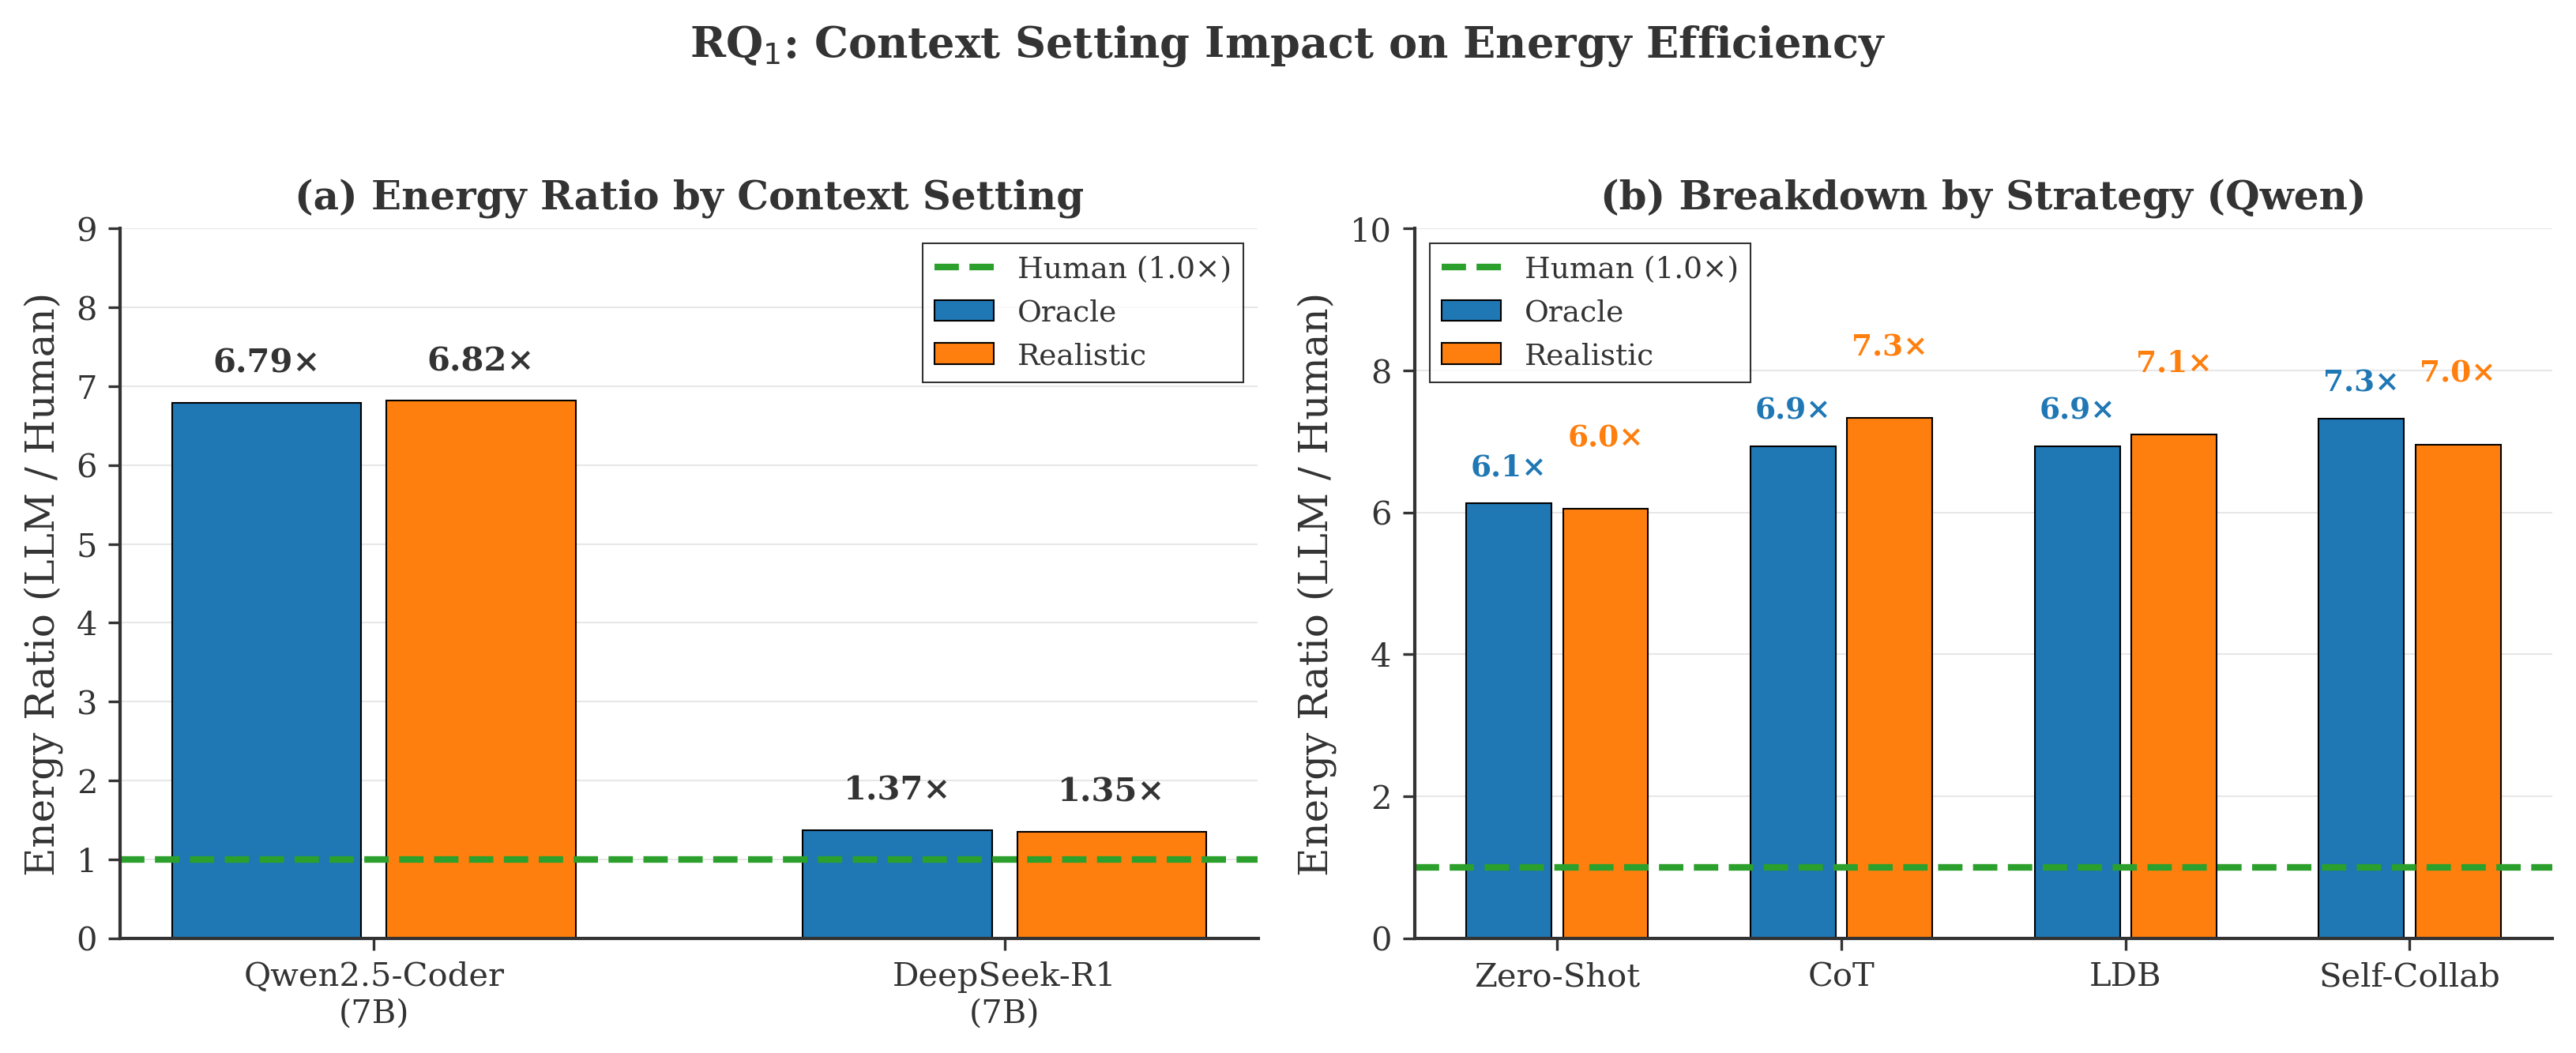

✅ fig_rq1.pdf salvata


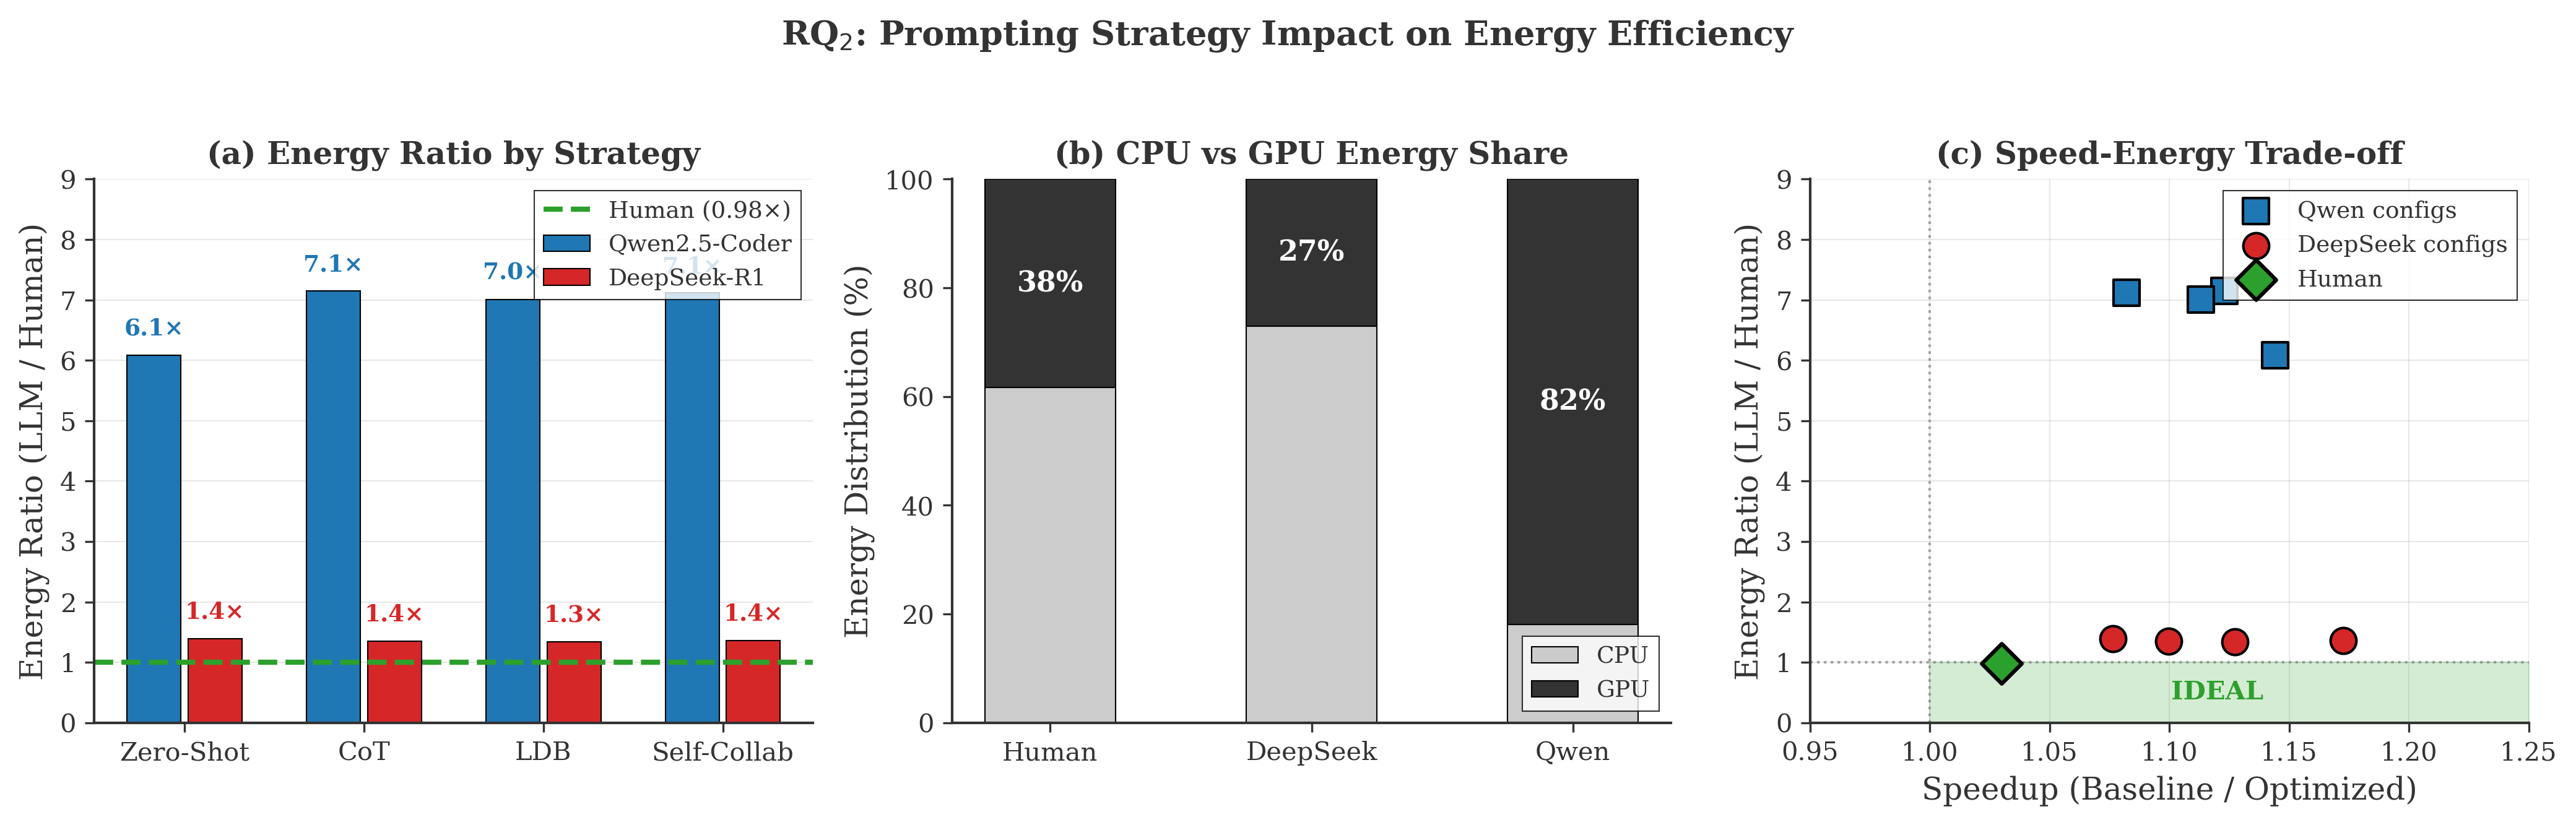

✅ fig_rq2.pdf salvata

✅ COMPLETATO!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CARICA DATI
# ============================================

# ============================================
# STILE IEEE PULITO
# ============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.0,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colori
C_ORACLE = '#1f77b4'    # Blu
C_REALISTIC = '#ff7f0e' # Arancione  
C_HUMAN = '#2ca02c'     # Verde
C_QWEN = '#1f77b4'      # Blu
C_DEEPSEEK = '#d62728'  # Rosso
C_CPU = '#cccccc'       # Grigio chiaro
C_GPU = '#333333'       # Grigio scuro

# ============================================
# PREPARA DATI
# ============================================
def extract_data(df):
    configs = [
        ('Qwen', 'ZS', 'Oracle', 'qwen_zs_oracle'),
        ('Qwen', 'ZS', 'Realistic', 'qwen_zs_realistic'),
        ('Qwen', 'CoT', 'Oracle', 'qwen_cot_oracle'),
        ('Qwen', 'CoT', 'Realistic', 'qwen_cot_realistic'),
        ('Qwen', 'LDB', 'Oracle', 'qwen_ldb_oracle'),
        ('Qwen', 'LDB', 'Realistic', 'qwen_ldb_realistic'),
        ('Qwen', 'SC', 'Oracle', 'qwen_sc_oracle'),
        ('Qwen', 'SC', 'Realistic', 'qwen_sc_realistic'),
        ('DeepSeek', 'ZS', 'Oracle', 'deepseek_zs_oracle'),
        ('DeepSeek', 'ZS', 'Realistic', 'deepseek_zs_realistic'),
        ('DeepSeek', 'CoT', 'Oracle', 'deepseek_cot_oracle'),
        ('DeepSeek', 'LDB', 'Oracle', 'deepseek_ldb_oracle'),
        ('DeepSeek', 'LDB', 'Realistic', 'deepseek_ldb_realistic'),
        ('DeepSeek', 'SC', 'Oracle', 'deepseek_sc_oracle'),
    ]
    
    rows = []
    for model, strategy, context, prefix in configs:
        ecol = f'{prefix}_total_energy_joules_mean'
        dcol = f'{prefix}_duration_seconds_mean'
        gcol = f'{prefix}_gpu_energy_joules_mean'
        ccol = f'{prefix}_cpu_energy_joules_mean'
        
        if ecol not in df.columns:
            continue
            
        for idx in df.index:
            llm_e = df.loc[idx, ecol]
            hum_e = df.loc[idx, 'human_head_total_energy_joules_mean']
            base_d = df.loc[idx, 'base_duration_seconds_mean']
            llm_d = df.loc[idx, dcol] if dcol in df.columns else np.nan
            gpu_e = df.loc[idx, gcol] if gcol in df.columns else 0
            cpu_e = df.loc[idx, ccol] if ccol in df.columns else 0
            
            if pd.notna(llm_e) and pd.notna(hum_e) and hum_e > 0 and llm_e > 0:
                total_e = gpu_e + cpu_e if (gpu_e + cpu_e) > 0 else llm_e
                rows.append({
                    'model': model,
                    'strategy': strategy,
                    'context': context,
                    'energy_ratio': llm_e / hum_e,
                    'speedup': base_d / llm_d if pd.notna(llm_d) and llm_d > 0 else 1.0,
                    'gpu_pct': 100 * gpu_e / total_e if total_e > 0 else 0
                })
    
    return pd.DataFrame(rows)

data = extract_data(df)

# Human GPU%
hgpu = df['human_head_gpu_energy_joules_mean'].sum()
hcpu = df['human_head_cpu_energy_joules_mean'].sum()
HUMAN_GPU_PCT = 100 * hgpu / (hgpu + hcpu) if (hgpu + hcpu) > 0 else 38

print(f"Totale osservazioni: {len(data)}")


# ============================================
# FIGURA RQ1 - PULITA
# ============================================
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# --- (a) Energy Ratio by Context ---
models = ['Qwen', 'DeepSeek']
x = np.arange(len(models))
w = 0.30  # Barre più strette

oracle_means = []
realistic_means = []
for m in models:
    o = data[(data['model']==m) & (data['context']=='Oracle')]['energy_ratio'].mean()
    r = data[(data['model']==m) & (data['context']=='Realistic')]['energy_ratio'].mean()
    oracle_means.append(o if pd.notna(o) else 0)
    realistic_means.append(r if pd.notna(r) else 0)

b1 = ax1.bar(x - w/2 - 0.02, oracle_means, w, label='Oracle', color=C_ORACLE, edgecolor='black', linewidth=0.5)
b2 = ax1.bar(x + w/2 + 0.02, realistic_means, w, label='Realistic', color=C_REALISTIC, edgecolor='black', linewidth=0.5)

ax1.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2, label='Human (1.0×)')

# Valori SOLO sopra, centrati, con offset verticale fisso
for i, (o_val, r_val) in enumerate(zip(oracle_means, realistic_means)):
    ax1.text(x[i] - w/2 - 0.02, o_val + 0.3, f'{o_val:.2f}×', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.text(x[i] + w/2 + 0.02, r_val + 0.3, f'{r_val:.2f}×', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(['Qwen2.5-Coder\n(7B)', 'DeepSeek-R1\n(7B)'], fontsize=10)
ax1.set_ylabel('Energy Ratio (LLM / Human)')
ax1.set_ylim(0, 9)
ax1.set_title('(a) Energy Ratio by Context Setting')
ax1.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')
ax1.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

# --- (b) Breakdown by Strategy (Qwen) ---
qwen = data[data['model']=='Qwen']
strategies = ['ZS', 'CoT', 'LDB', 'SC']
strategy_labels = ['Zero-Shot', 'CoT', 'LDB', 'Self-Collab']
x2 = np.arange(len(strategies))

o_vals = []
r_vals = []
for s in strategies:
    o = qwen[(qwen['strategy']==s) & (qwen['context']=='Oracle')]['energy_ratio'].mean()
    r = qwen[(qwen['strategy']==s) & (qwen['context']=='Realistic')]['energy_ratio'].mean()
    o_vals.append(o if pd.notna(o) else 0)
    r_vals.append(r if pd.notna(r) else 0)

b3 = ax2.bar(x2 - w/2 - 0.02, o_vals, w, label='Oracle', color=C_ORACLE, edgecolor='black', linewidth=0.5)
b4 = ax2.bar(x2 + w/2 + 0.02, r_vals, w, label='Realistic', color=C_REALISTIC, edgecolor='black', linewidth=0.5)

ax2.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2, label='Human (1.0×)')

# Valori sopra - alternati per evitare sovrapposizione
for i, (o_val, r_val) in enumerate(zip(o_vals, r_vals)):
    # Oracle: valore sopra
    ax2.text(x2[i] - w/2 - 0.02, o_val + 0.3, f'{o_val:.1f}×', ha='center', va='bottom', fontsize=9, fontweight='bold', color=C_ORACLE)
    # Realistic: valore sopra ma leggermente più alto se simile
    offset = 0.3 if abs(o_val - r_val) > 0.5 else 0.8
    ax2.text(x2[i] + w/2 + 0.02, r_val + offset, f'{r_val:.1f}×', ha='center', va='bottom', fontsize=9, fontweight='bold', color=C_REALISTIC)

ax2.set_xticks(x2)
ax2.set_xticklabels(strategy_labels, fontsize=10)
ax2.set_ylabel('Energy Ratio (LLM / Human)')
ax2.set_ylim(0, 10)  # Un po' più alto per i valori
ax2.set_title('(b) Breakdown by Strategy (Qwen)')
ax2.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')
ax2.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

fig1.suptitle('RQ$_1$: Context Setting Impact on Energy Efficiency', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig_rq1.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_rq1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ fig_rq1.pdf salvata")


# ============================================
# FIGURA RQ2 - PULITA
# ============================================
fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.5))

# --- (a) Energy Ratio by Strategy ---
strategies = ['ZS', 'CoT', 'LDB', 'SC']
strategy_labels = ['Zero-Shot', 'CoT', 'LDB', 'Self-Collab']
x = np.arange(len(strategies))
w = 0.30

qwen_means = [data[(data['model']=='Qwen') & (data['strategy']==s)]['energy_ratio'].mean() for s in strategies]
deep_means = [data[(data['model']=='DeepSeek') & (data['strategy']==s)]['energy_ratio'].mean() for s in strategies]

qwen_means = [v if pd.notna(v) else 0 for v in qwen_means]
deep_means = [v if pd.notna(v) else 0 for v in deep_means]

b1 = ax1.bar(x - w/2 - 0.02, qwen_means, w, label='Qwen2.5-Coder', color=C_QWEN, edgecolor='black', linewidth=0.5)
b2 = ax1.bar(x + w/2 + 0.02, deep_means, w, label='DeepSeek-R1', color=C_DEEPSEEK, edgecolor='black', linewidth=0.5)

ax1.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2, label='Human (0.98×)')

# Valori sopra
for i, (q_val, d_val) in enumerate(zip(qwen_means, deep_means)):
    if q_val > 0:
        ax1.text(x[i] - w/2 - 0.02, q_val + 0.25, f'{q_val:.1f}×', ha='center', va='bottom', fontsize=9, fontweight='bold', color=C_QWEN)
    if d_val > 0:
        ax1.text(x[i] + w/2 + 0.02, d_val + 0.25, f'{d_val:.1f}×', ha='center', va='bottom', fontsize=9, fontweight='bold', color=C_DEEPSEEK)

ax1.set_xticks(x)
ax1.set_xticklabels(strategy_labels, fontsize=10)
ax1.set_ylabel('Energy Ratio (LLM / Human)')
ax1.set_ylim(0, 9)
ax1.set_title('(a) Energy Ratio by Strategy')
ax1.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)


# --- (b) CPU vs GPU Distribution ---
categories = ['Human', 'DeepSeek', 'Qwen']
deep_gpu = data[data['model']=='DeepSeek']['gpu_pct'].mean()
qwen_gpu = data[data['model']=='Qwen']['gpu_pct'].mean()

gpu_vals = [HUMAN_GPU_PCT, deep_gpu if pd.notna(deep_gpu) else 27, qwen_gpu if pd.notna(qwen_gpu) else 82]
cpu_vals = [100 - g for g in gpu_vals]

x2 = np.arange(len(categories))

ax2.bar(x2, cpu_vals, 0.5, label='CPU', color=C_CPU, edgecolor='black', linewidth=0.5)
ax2.bar(x2, gpu_vals, 0.5, bottom=cpu_vals, label='GPU', color=C_GPU, edgecolor='black', linewidth=0.5)

# Percentuali GPU dentro le barre (in bianco)
for i, g in enumerate(gpu_vals):
    ax2.text(x2[i], cpu_vals[i] + g/2, f'{g:.0f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax2.set_xticks(x2)
ax2.set_xticklabels(categories, fontsize=10)
ax2.set_ylabel('Energy Distribution (%)')
ax2.set_ylim(0, 100)
ax2.set_title('(b) CPU vs GPU Energy Share')
ax2.legend(loc='lower right', frameon=True, fancybox=False, edgecolor='black')


# --- (c) Speed vs Energy Trade-off ---
qwen_agg = data[data['model']=='Qwen'].groupby('strategy').agg({'speedup':'mean', 'energy_ratio':'mean'}).reset_index()
deep_agg = data[data['model']=='DeepSeek'].groupby('strategy').agg({'speedup':'mean', 'energy_ratio':'mean'}).reset_index()

# Scatter Qwen
ax3.scatter(qwen_agg['speedup'], qwen_agg['energy_ratio'], 
           s=100, c=C_QWEN, marker='s', edgecolors='black', linewidths=1, label='Qwen configs', zorder=3)

# Scatter DeepSeek
ax3.scatter(deep_agg['speedup'], deep_agg['energy_ratio'],
           s=100, c=C_DEEPSEEK, marker='o', edgecolors='black', linewidths=1, label='DeepSeek configs', zorder=3)

# Human
ax3.scatter([1.03], [0.98], s=120, c=C_HUMAN, marker='D', edgecolors='black', linewidths=1.5, label='Human', zorder=4)

# Reference lines
ax3.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax3.axvline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.7)

# Ideal region
ax3.fill_between([1.0, 1.25], 0, 1.0, alpha=0.2, color=C_HUMAN, zorder=1)
ax3.text(1.12, 0.5, 'IDEAL', ha='center', va='center', fontsize=10, fontweight='bold', color=C_HUMAN)

ax3.set_xlabel('Speedup (Baseline / Optimized)')
ax3.set_ylabel('Energy Ratio (LLM / Human)')
ax3.set_xlim(0.95, 1.25)
ax3.set_ylim(0, 9)
ax3.set_title('(c) Speed-Energy Trade-off')
ax3.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
ax3.grid(alpha=0.3, linestyle='-', linewidth=0.5)

fig2.suptitle('RQ$_2$: Prompting Strategy Impact on Energy Efficiency', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig_rq2.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_rq2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ fig_rq2.pdf salvata")

print("\n✅ COMPLETATO!")

Totale osservazioni: 618


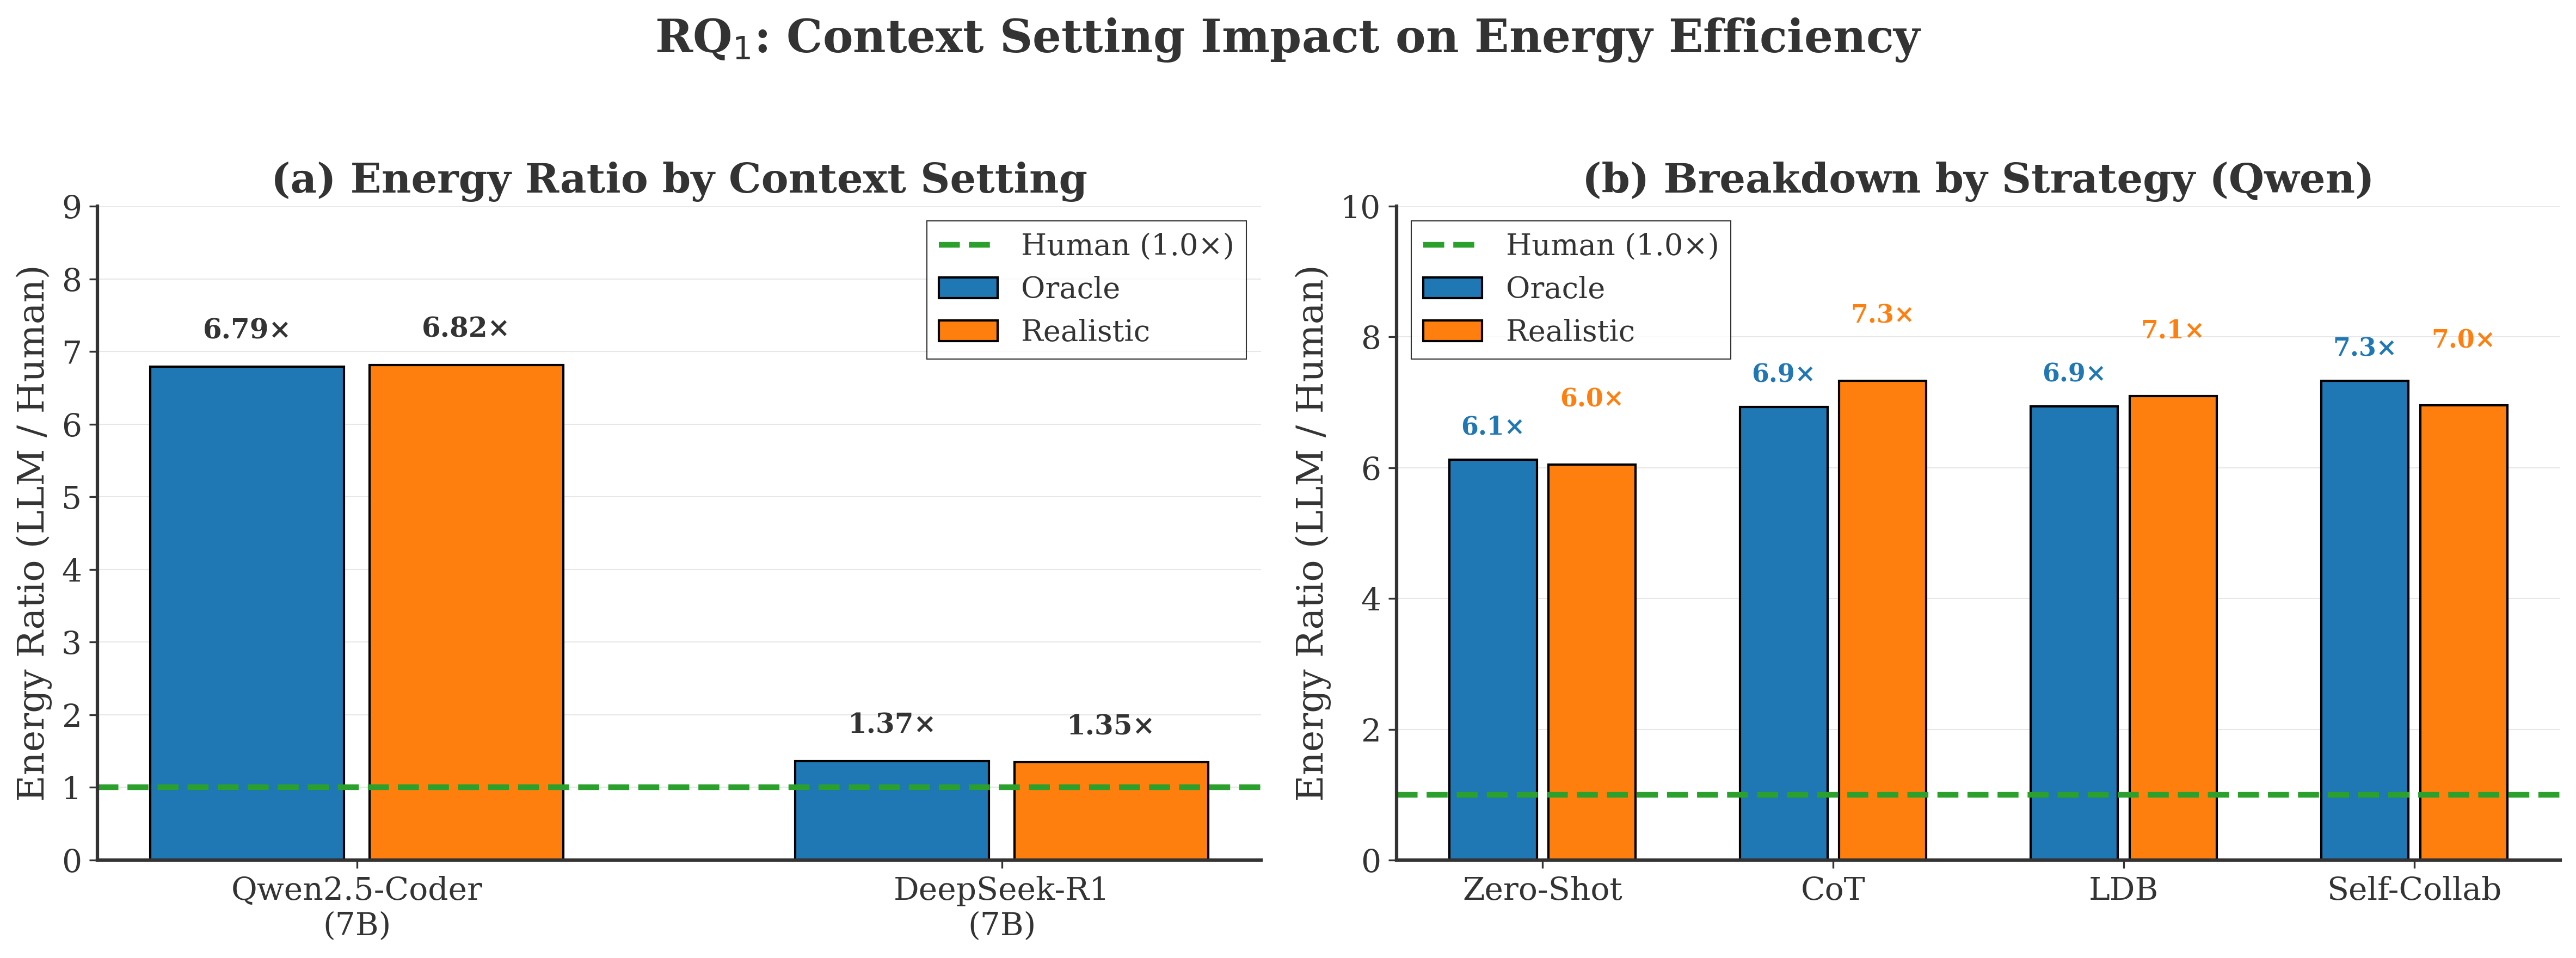

✅ fig_rq1_large.pdf salvata


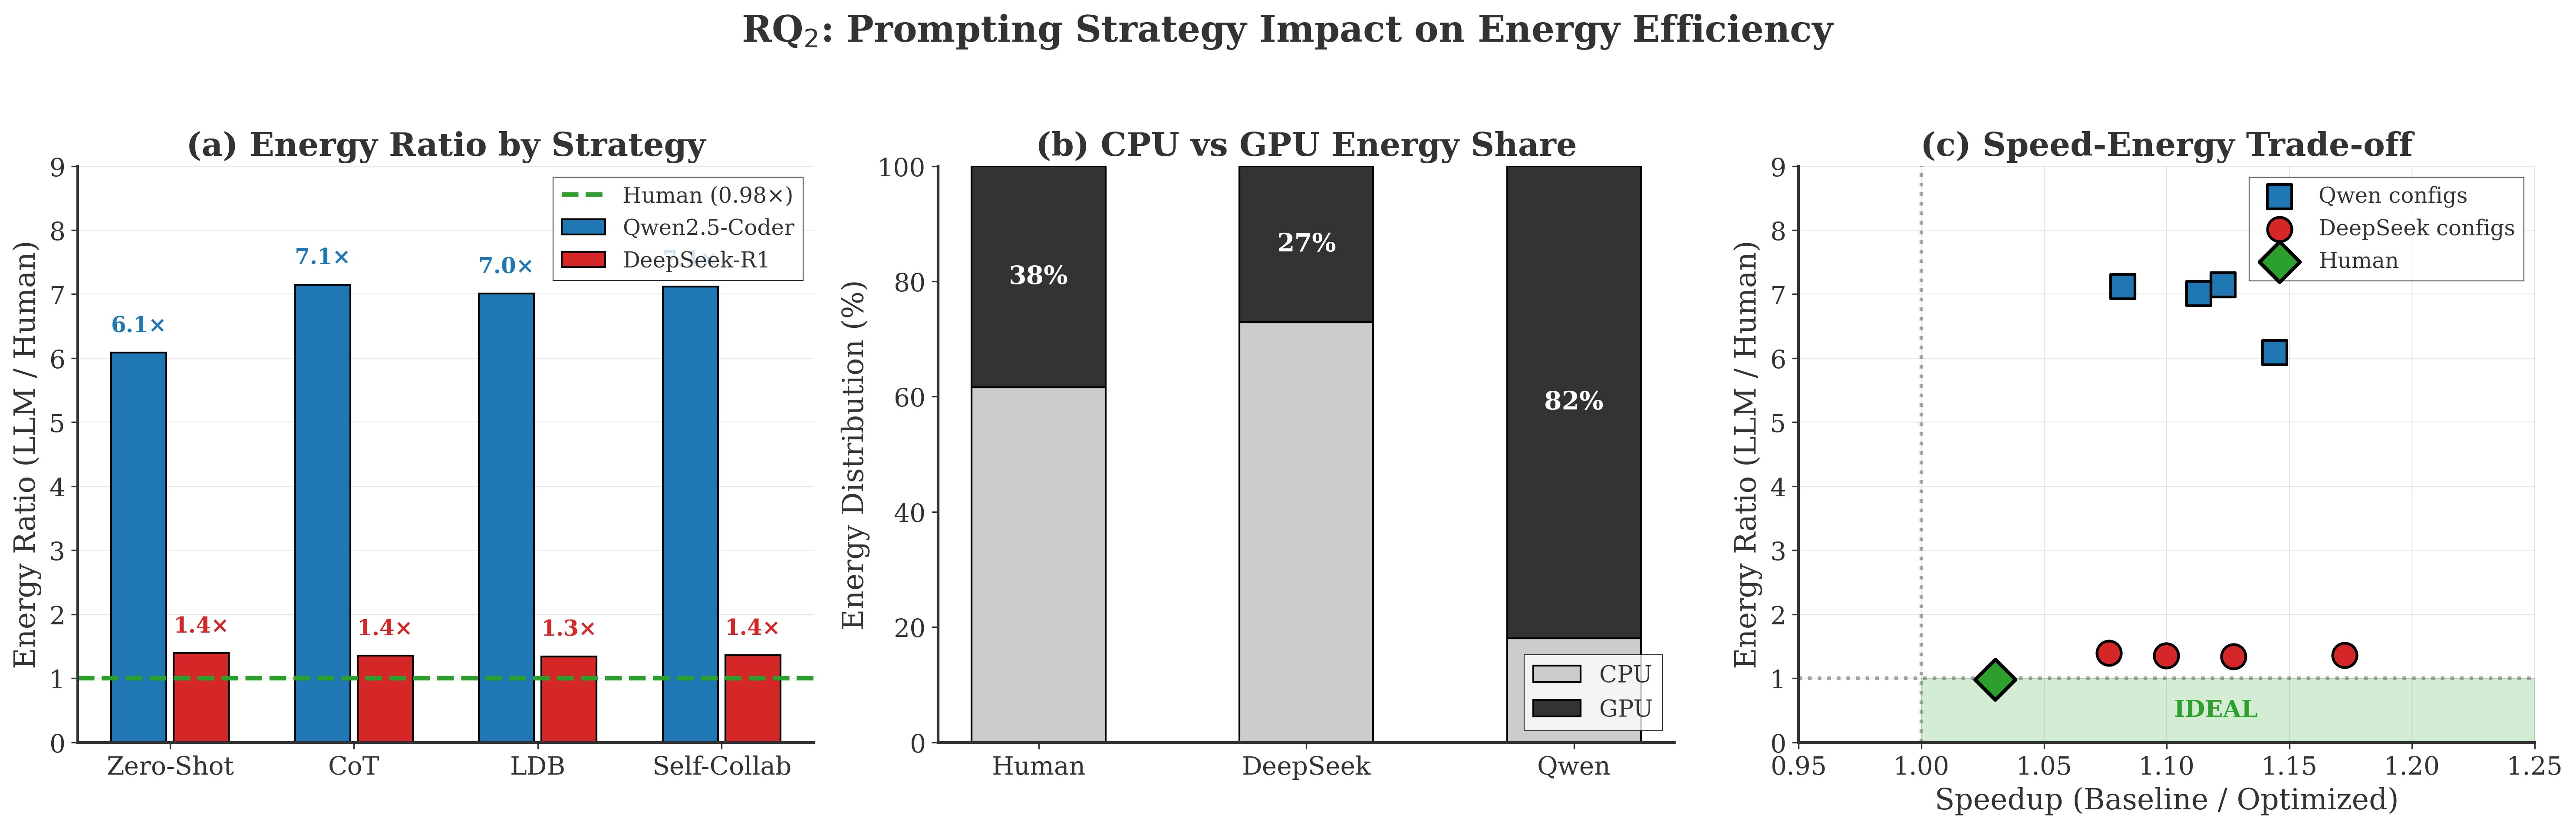

✅ fig_rq2_large.pdf salvata

✅ COMPLETATO CON SUCCESSO!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================
# CARICA DATI
# ============================================
# (Assumo che 'df' sia già caricato nel tuo ambiente come prima)

# ============================================
# STILE IEEE "BIG & BOLD" (MODIFICATO)
# ============================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 14,              # AUMENTATO da 11
    'axes.labelsize': 16,         # AUMENTATO da 12
    'axes.titlesize': 18,         # AUMENTATO da 12
    'axes.titleweight': 'bold',
    'xtick.labelsize': 14,        # AUMENTATO da 10
    'ytick.labelsize': 14,        # AUMENTATO da 10
    'legend.fontsize': 13,        # AUMENTATO da 9
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.5,        # Bordi più spessi
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colori (Invariati)
C_ORACLE = '#1f77b4'    
C_REALISTIC = '#ff7f0e'   
C_HUMAN = '#2ca02c'     
C_QWEN = '#1f77b4'      
C_DEEPSEEK = '#d62728'  
C_CPU = '#cccccc'       
C_GPU = '#333333'       

# ============================================
# PREPARA DATI (LOGICA INVARIATA)
# ============================================
def extract_data(df):
    configs = [
        ('Qwen', 'ZS', 'Oracle', 'qwen_zs_oracle'),
        ('Qwen', 'ZS', 'Realistic', 'qwen_zs_realistic'),
        ('Qwen', 'CoT', 'Oracle', 'qwen_cot_oracle'),
        ('Qwen', 'CoT', 'Realistic', 'qwen_cot_realistic'),
        ('Qwen', 'LDB', 'Oracle', 'qwen_ldb_oracle'),
        ('Qwen', 'LDB', 'Realistic', 'qwen_ldb_realistic'),
        ('Qwen', 'SC', 'Oracle', 'qwen_sc_oracle'),
        ('Qwen', 'SC', 'Realistic', 'qwen_sc_realistic'),
        ('DeepSeek', 'ZS', 'Oracle', 'deepseek_zs_oracle'),
        ('DeepSeek', 'ZS', 'Realistic', 'deepseek_zs_realistic'),
        ('DeepSeek', 'CoT', 'Oracle', 'deepseek_cot_oracle'),
        ('DeepSeek', 'LDB', 'Oracle', 'deepseek_ldb_oracle'),
        ('DeepSeek', 'LDB', 'Realistic', 'deepseek_ldb_realistic'),
        ('DeepSeek', 'SC', 'Oracle', 'deepseek_sc_oracle'),
    ]
    
    rows = []
    for model, strategy, context, prefix in configs:
        ecol = f'{prefix}_total_energy_joules_mean'
        dcol = f'{prefix}_duration_seconds_mean'
        gcol = f'{prefix}_gpu_energy_joules_mean'
        ccol = f'{prefix}_cpu_energy_joules_mean'
        
        if ecol not in df.columns:
            continue
            
        for idx in df.index:
            llm_e = df.loc[idx, ecol]
            hum_e = df.loc[idx, 'human_head_total_energy_joules_mean']
            base_d = df.loc[idx, 'base_duration_seconds_mean']
            llm_d = df.loc[idx, dcol] if dcol in df.columns else np.nan
            gpu_e = df.loc[idx, gcol] if gcol in df.columns else 0
            cpu_e = df.loc[idx, ccol] if ccol in df.columns else 0
            
            if pd.notna(llm_e) and pd.notna(hum_e) and hum_e > 0 and llm_e > 0:
                total_e = gpu_e + cpu_e if (gpu_e + cpu_e) > 0 else llm_e
                rows.append({
                    'model': model,
                    'strategy': strategy,
                    'context': context,
                    'energy_ratio': llm_e / hum_e,
                    'speedup': base_d / llm_d if pd.notna(llm_d) and llm_d > 0 else 1.0,
                    'gpu_pct': 100 * gpu_e / total_e if total_e > 0 else 0
                })
    
    return pd.DataFrame(rows)

data = extract_data(df)

# Human GPU%
hgpu = df['human_head_gpu_energy_joules_mean'].sum()
hcpu = df['human_head_cpu_energy_joules_mean'].sum()
HUMAN_GPU_PCT = 100 * hgpu / (hgpu + hcpu) if (hgpu + hcpu) > 0 else 38

print(f"Totale osservazioni: {len(data)}")


# ============================================
# FIGURA RQ1 - SUPER LEGGIBILE
# ============================================
# Aumentato figsize da (11, 4.5) a (16, 6)
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- (a) Energy Ratio by Context ---
models = ['Qwen', 'DeepSeek']
x = np.arange(len(models))
w = 0.30

oracle_means = []
realistic_means = []
for m in models:
    o = data[(data['model']==m) & (data['context']=='Oracle')]['energy_ratio'].mean()
    r = data[(data['model']==m) & (data['context']=='Realistic')]['energy_ratio'].mean()
    oracle_means.append(o if pd.notna(o) else 0)
    realistic_means.append(r if pd.notna(r) else 0)

b1 = ax1.bar(x - w/2 - 0.02, oracle_means, w, label='Oracle', color=C_ORACLE, edgecolor='black', linewidth=1)
b2 = ax1.bar(x + w/2 + 0.02, realistic_means, w, label='Realistic', color=C_REALISTIC, edgecolor='black', linewidth=1)

ax1.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2.5, label='Human (1.0×)')

# Valori SOLO sopra (Font size aumentato a 12 Bold)
for i, (o_val, r_val) in enumerate(zip(oracle_means, realistic_means)):
    ax1.text(x[i] - w/2 - 0.02, o_val + 0.3, f'{o_val:.2f}×', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax1.text(x[i] + w/2 + 0.02, r_val + 0.3, f'{r_val:.2f}×', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(['Qwen2.5-Coder\n(7B)', 'DeepSeek-R1\n(7B)']) # Size ereditato (14)
ax1.set_ylabel('Energy Ratio (LLM / Human)')
ax1.set_ylim(0, 9)
ax1.set_title('(a) Energy Ratio by Context Setting')
ax1.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')
ax1.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

# --- (b) Breakdown by Strategy (Qwen) ---
qwen = data[data['model']=='Qwen']
strategies = ['ZS', 'CoT', 'LDB', 'SC']
strategy_labels = ['Zero-Shot', 'CoT', 'LDB', 'Self-Collab']
x2 = np.arange(len(strategies))

o_vals = []
r_vals = []
for s in strategies:
    o = qwen[(qwen['strategy']==s) & (qwen['context']=='Oracle')]['energy_ratio'].mean()
    r = qwen[(qwen['strategy']==s) & (qwen['context']=='Realistic')]['energy_ratio'].mean()
    o_vals.append(o if pd.notna(o) else 0)
    r_vals.append(r if pd.notna(r) else 0)

b3 = ax2.bar(x2 - w/2 - 0.02, o_vals, w, label='Oracle', color=C_ORACLE, edgecolor='black', linewidth=1)
b4 = ax2.bar(x2 + w/2 + 0.02, r_vals, w, label='Realistic', color=C_REALISTIC, edgecolor='black', linewidth=1)

ax2.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2.5, label='Human (1.0×)')

# Valori sopra (Font size aumentato a 11 Bold)
for i, (o_val, r_val) in enumerate(zip(o_vals, r_vals)):
    ax2.text(x2[i] - w/2 - 0.02, o_val + 0.3, f'{o_val:.1f}×', ha='center', va='bottom', fontsize=11, fontweight='bold', color=C_ORACLE)
    offset = 0.3 if abs(o_val - r_val) > 0.5 else 0.8
    ax2.text(x2[i] + w/2 + 0.02, r_val + offset, f'{r_val:.1f}×', ha='center', va='bottom', fontsize=11, fontweight='bold', color=C_REALISTIC)

ax2.set_xticks(x2)
ax2.set_xticklabels(strategy_labels) # Size ereditato (14)
ax2.set_ylabel('Energy Ratio (LLM / Human)')
ax2.set_ylim(0, 10)
ax2.set_title('(b) Breakdown by Strategy (Qwen)')
ax2.legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black')
ax2.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)

fig1.suptitle('RQ$_1$: Context Setting Impact on Energy Efficiency', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig_rq1_large.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_rq1_large.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ fig_rq1_large.pdf salvata")


# ============================================
# FIGURA RQ2 - SUPER LEGGIBILE
# ============================================
# Aumentato figsize da (14, 4.5) a (20, 6.5)
fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6.5))

# --- (a) Energy Ratio by Strategy ---
strategies = ['ZS', 'CoT', 'LDB', 'SC']
strategy_labels = ['Zero-Shot', 'CoT', 'LDB', 'Self-Collab']
x = np.arange(len(strategies))
w = 0.30

qwen_means = [data[(data['model']=='Qwen') & (data['strategy']==s)]['energy_ratio'].mean() for s in strategies]
deep_means = [data[(data['model']=='DeepSeek') & (data['strategy']==s)]['energy_ratio'].mean() for s in strategies]

qwen_means = [v if pd.notna(v) else 0 for v in qwen_means]
deep_means = [v if pd.notna(v) else 0 for v in deep_means]

b1 = ax1.bar(x - w/2 - 0.02, qwen_means, w, label='Qwen2.5-Coder', color=C_QWEN, edgecolor='black', linewidth=1)
b2 = ax1.bar(x + w/2 + 0.02, deep_means, w, label='DeepSeek-R1', color=C_DEEPSEEK, edgecolor='black', linewidth=1)

ax1.axhline(1.0, color=C_HUMAN, linestyle='--', linewidth=2.5, label='Human (0.98×)')

# Valori sopra (Font size 12 Bold)
for i, (q_val, d_val) in enumerate(zip(qwen_means, deep_means)):
    if q_val > 0:
        ax1.text(x[i] - w/2 - 0.02, q_val + 0.25, f'{q_val:.1f}×', ha='center', va='bottom', fontsize=12, fontweight='bold', color=C_QWEN)
    if d_val > 0:
        ax1.text(x[i] + w/2 + 0.02, d_val + 0.25, f'{d_val:.1f}×', ha='center', va='bottom', fontsize=12, fontweight='bold', color=C_DEEPSEEK)

ax1.set_xticks(x)
ax1.set_xticklabels(strategy_labels) # Size ereditato (14)
ax1.set_ylabel('Energy Ratio (LLM / Human)')
ax1.set_ylim(0, 9)
ax1.set_title('(a) Energy Ratio by Strategy')
ax1.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=12)
ax1.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)


# --- (b) CPU vs GPU Distribution ---
categories = ['Human', 'DeepSeek', 'Qwen']
deep_gpu = data[data['model']=='DeepSeek']['gpu_pct'].mean()
qwen_gpu = data[data['model']=='Qwen']['gpu_pct'].mean()

gpu_vals = [HUMAN_GPU_PCT, deep_gpu if pd.notna(deep_gpu) else 27, qwen_gpu if pd.notna(qwen_gpu) else 82]
cpu_vals = [100 - g for g in gpu_vals]

x2 = np.arange(len(categories))

ax2.bar(x2, cpu_vals, 0.5, label='CPU', color=C_CPU, edgecolor='black', linewidth=1)
ax2.bar(x2, gpu_vals, 0.5, bottom=cpu_vals, label='GPU', color=C_GPU, edgecolor='black', linewidth=1)

# Percentuali GPU (Font size 14 Bold White)
for i, g in enumerate(gpu_vals):
    ax2.text(x2[i], cpu_vals[i] + g/2, f'{g:.0f}%', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

ax2.set_xticks(x2)
ax2.set_xticklabels(categories)
ax2.set_ylabel('Energy Distribution (%)')
ax2.set_ylim(0, 100)
ax2.set_title('(b) CPU vs GPU Energy Share')
ax2.legend(loc='lower right', frameon=True, fancybox=False, edgecolor='black')


# --- (c) Speed vs Energy Trade-off ---
qwen_agg = data[data['model']=='Qwen'].groupby('strategy').agg({'speedup':'mean', 'energy_ratio':'mean'}).reset_index()
deep_agg = data[data['model']=='DeepSeek'].groupby('strategy').agg({'speedup':'mean', 'energy_ratio':'mean'}).reset_index()

# Scatter Qwen (Marker aumentato a 180)
ax3.scatter(qwen_agg['speedup'], qwen_agg['energy_ratio'], 
           s=180, c=C_QWEN, marker='s', edgecolors='black', linewidths=1.5, label='Qwen configs', zorder=3)

# Scatter DeepSeek (Marker aumentato a 180)
ax3.scatter(deep_agg['speedup'], deep_agg['energy_ratio'],
           s=180, c=C_DEEPSEEK, marker='o', edgecolors='black', linewidths=1.5, label='DeepSeek configs', zorder=3)

# Human (Marker aumentato a 250)
ax3.scatter([1.03], [0.98], s=250, c=C_HUMAN, marker='D', edgecolors='black', linewidths=2, label='Human', zorder=4)

# Reference lines
ax3.axhline(1.0, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax3.axvline(1.0, color='gray', linestyle=':', linewidth=2, alpha=0.7)

# Ideal region
ax3.fill_between([1.0, 1.25], 0, 1.0, alpha=0.2, color=C_HUMAN, zorder=1)
ax3.text(1.12, 0.5, 'IDEAL', ha='center', va='center', fontsize=13, fontweight='bold', color=C_HUMAN)

ax3.set_xlabel('Speedup (Baseline / Optimized)')
ax3.set_ylabel('Energy Ratio (LLM / Human)')
ax3.set_xlim(0.95, 1.25)
ax3.set_ylim(0, 9)
ax3.set_title('(c) Speed-Energy Trade-off')
ax3.legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=12)
ax3.grid(alpha=0.3, linestyle='-', linewidth=0.5)

fig2.suptitle('RQ$_2$: Prompting Strategy Impact on Energy Efficiency', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig_rq2_large.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_rq2_large.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ fig_rq2_large.pdf salvata")

print("\n✅ COMPLETATO CON SUCCESSO!")


In [1]:
import pandas as pd

# Data from the user and syllabus
data = {
    'Category': ['Online Tests (OT)', 'Online Problems (OP)', 'Classroom Problems (CP)', 'Group Problems (GP)', 'Partial Exam (PE)', 'Laboratory (Lab)', 'Final Exam (FE)'],
    'Weight in Category': ['20% of CE', '40% of CE', '30% of CE', '10% of CE', '10% of Final', '10% of Final', '55% of Final'],
    'Your Grade': [9.61, 8.54, 3.17, 4.92, 0.00, 9.02, 0.00] # Final Exam is 0 for now as placeholder
}

df = pd.DataFrame(data)

# Create a writer object
file_name = 'Thermodynamics_Grades_Giacomo.xlsx'
writer = pd.ExcelWriter(file_name, engine='xlsxwriter')
df.to_excel(writer, sheet_name='Grades', index=False)

workbook  = writer.book
worksheet = writer.sheets['Grades']

# Add some formatting
header_format = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1})
num_format = workbook.add_format({'num_format': '0.00'})

# Set columns width
worksheet.set_column('A:A', 25)
worksheet.set_column('B:B', 20)
worksheet.set_column('C:C', 15)

# Add calculations section
worksheet.write('E1', 'Calculations', header_format)
worksheet.write('E2', 'Continuous Evaluation (Mce)')
# Mce Formula: (0.3*CP) + (0.1*GP) + (0.4*OP) + (0.2*OT)
# CP is C4, GP is C5, OP is C3, OT is C2
worksheet.write_formula('F2', '=(0.3*C4)+(0.1*C5)+(0.4*C3)+(0.2*C2)', num_format)

worksheet.write('E4', 'FINAL GRADE (Mfinal)', header_format)
# Formula: 0.55*FE + 0.1*MAX(FE, PE) + 0.1*Lab + 0.25*MAX(FE, Mce)
# FE is C8, PE is C6, Lab is C7, Mce is F2
worksheet.write_formula('F4', '=0.55*C8 + 0.1*MAX(C8, C6) + 0.1*C7 + 0.25*MAX(C8, F2)', num_format)

worksheet.write('E6', 'Required FE for Pass (5.0)')
# This is a bit harder for a static formula without solver, but we can estimate
# Since PE=0 and Mce=6.78, if FE < 6.78: 0.55*FE + 0.1*FE + 0.1*Lab + 0.25*Mce = 5
# 0.65*FE + 0.1*9.02 + 0.25*6.78 = 5
# 0.65*FE + 0.902 + 1.695 = 5 -> 0.65*FE = 2.403 -> FE = 3.69
worksheet.write('F6', 3.70, num_format)

worksheet.write('E8', 'Note:', workbook.add_format({'italic': True}))
worksheet.write('E9', 'The Final Exam (FE) cell is editable.')
worksheet.write('E10', 'Change cell C8 to see your Final Grade.')

writer.close()

print(f"Excel file created: {file_name}")

Excel file created: Thermodynamics_Grades_Giacomo.xlsx
